In [1]:
import pandas as pd
import numpy  as np
import tables as tb
from scipy.integrate import trapz
from scipy.optimize import curve_fit

In [2]:
import matplotlib        as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
%matplotlib notebook
%matplotlib inline
### Useful parameters for plots
mpl.rcParams["figure.figsize"]          = 12,10
mpl.rcParams["font.size"]               = 20
mpl.rcParams["figure.max_open_warning"] = 100
mpl.rcParams["font.size"]               = 20
mpl.rcParams["font.weight"]             ='normal'
mpl.rcParams["axes.labelweight"] = "normal"
mpl.rcParams['axes.facecolor'] = 'w'
mpl.rcParams['figure.facecolor'] = 'w';


[ 0 -1  0 ...  0  0  0]
[ 0 -1  0 ...  0  0  0]
/ (RootGroup) 'Test file'
/RD (Group) ''
/RD/pmtrwf (EArray(1000, 7, 5000)) ''
/Run (Group) ''
/Run/events (Table(1000,)) 'event info table'
/Run/runInfo (Table(1000,)) 'run info table'
len is : 5000


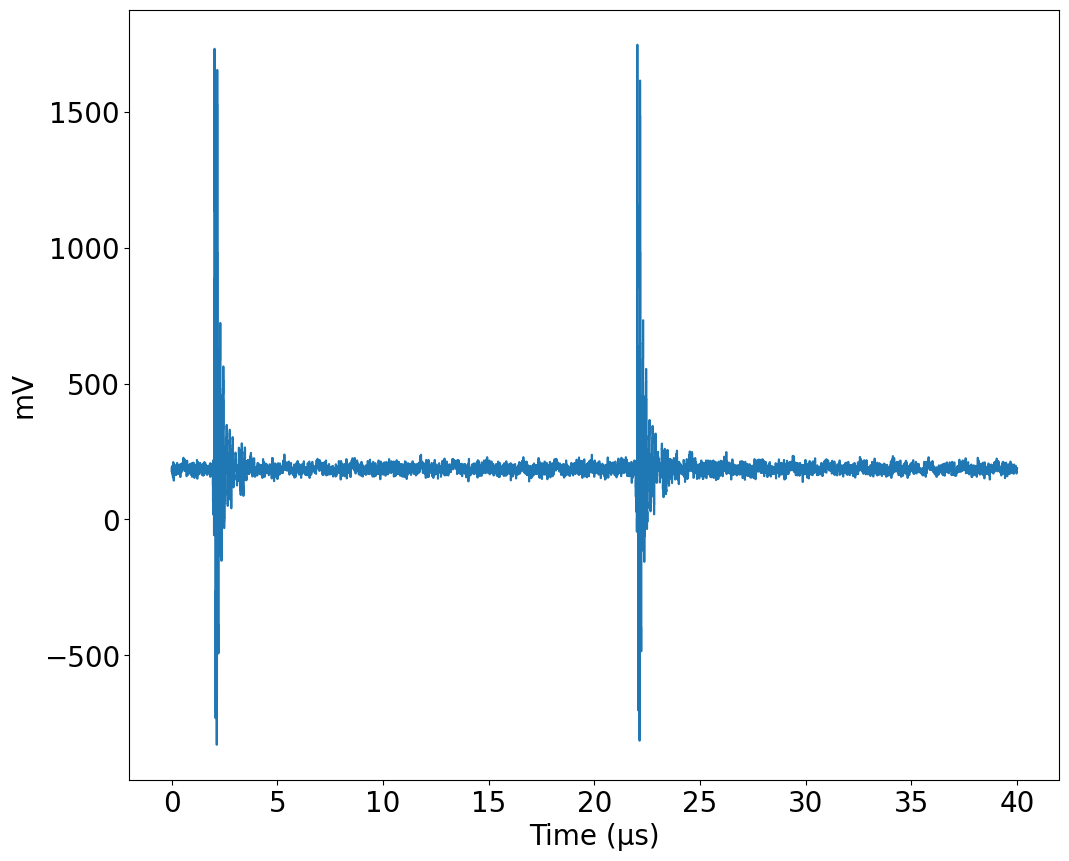

In [3]:
#to read 1 wf
wf_file = '/Users/ldonneger/Desktop/PhD_Thesis2/GapData/R2217/raw/Run_2217_file_0_raw.h5'

with tb.open_file(wf_file, 'r') as h5in:
    wvfs       =  h5in.root.RD.pmtrwf[0, 0] # Gets all pmt waveforms for the second event in the file
    print(-wvfs)
    wvfs       =  h5in.root.RD.pmtrwf[:, 0, :] # Gets all pmt waveforms for 1 PMT
    pmt_rwf    = -wvfs[0]
    print(pmt_rwf)
    
    !ptdump $wf_file
    #!ptdump -vd $wf_file:/RD/pmtrwf
    pmt_rwf    = -wvfs.sum(axis=0)       # Sums and inverts the signal of all PMTs
    print('len is :', len(pmt_rwf))
    t = np.linspace(0, len(pmt_rwf)*8/1000, len(pmt_rwf))
    plt.plot(t, pmt_rwf, drawstyle='steps', lw=1.5, zorder=0)
    plt.xlabel('Time (µs)')
    plt.ylabel('mV')

In [4]:
#create the folder of the date if not created in order to have all the next plots and data saved in an organized way

import os

date_folder = '01-07-2024' #put the date of the calibration in the format dd-mm-yyyy

os.makedirs('/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/'+str(date_folder), exist_ok=True)



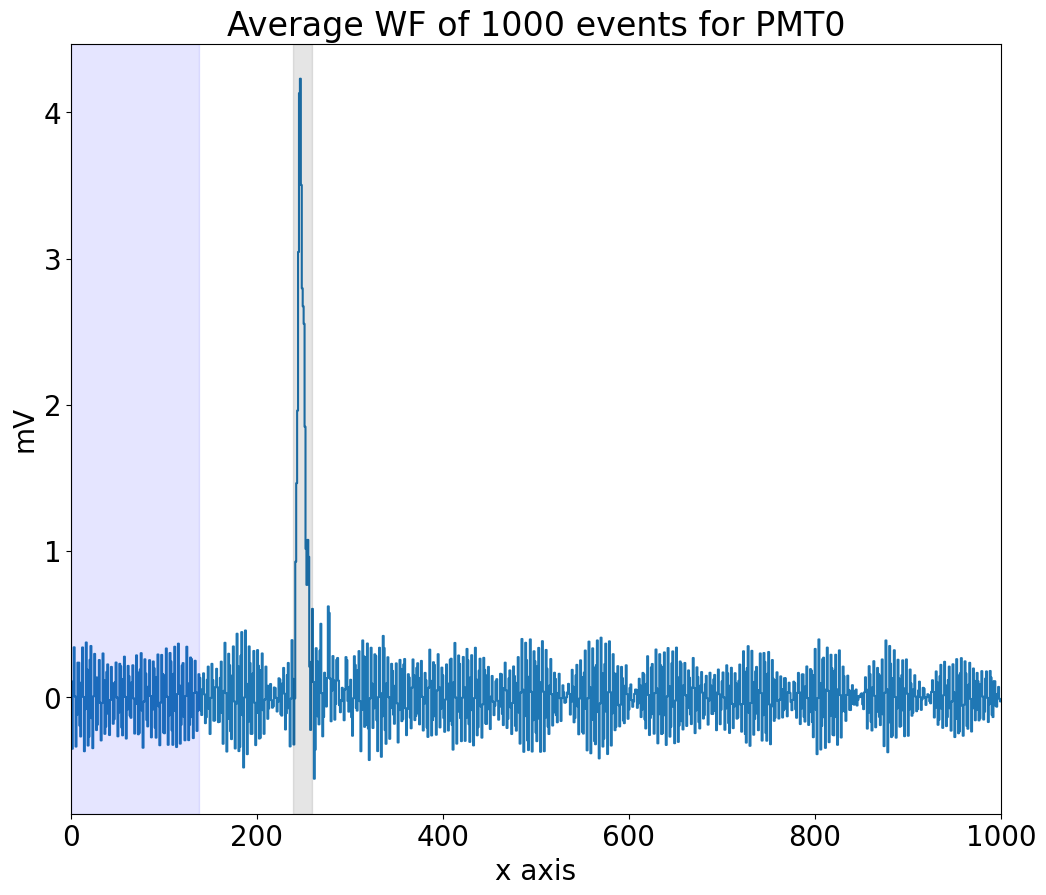

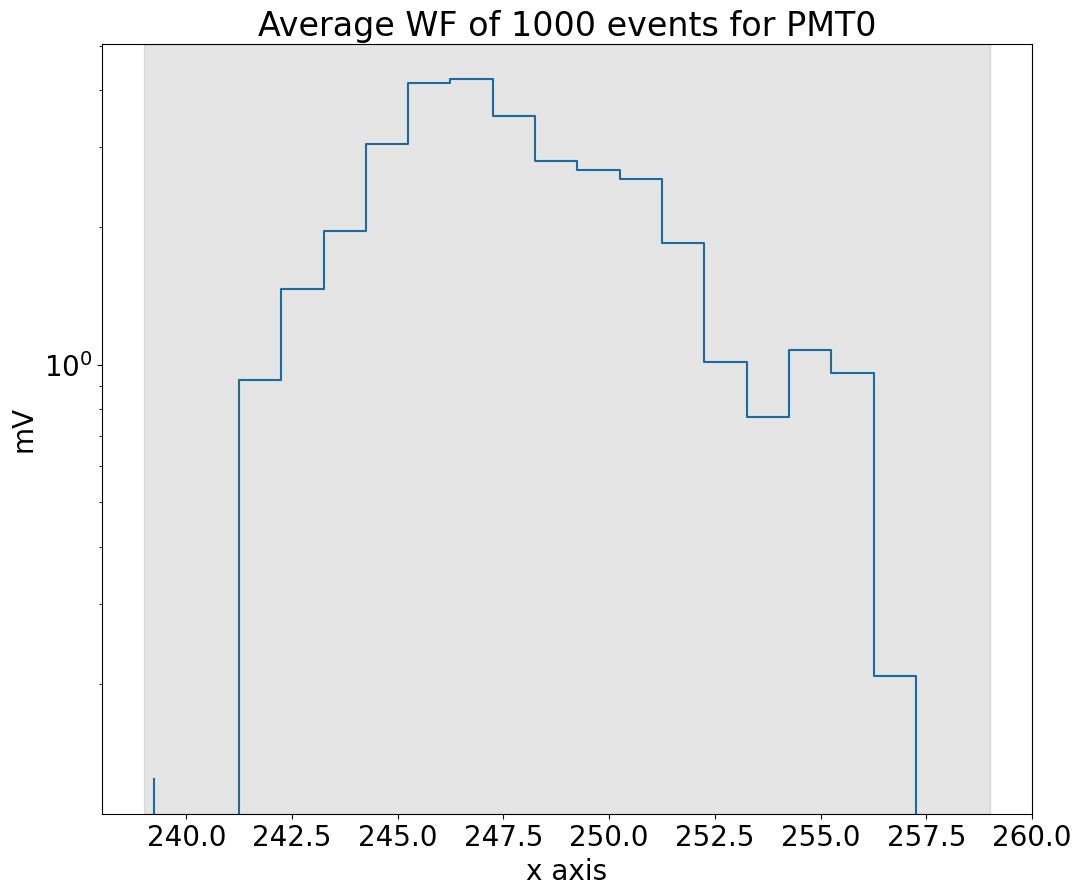

0 0


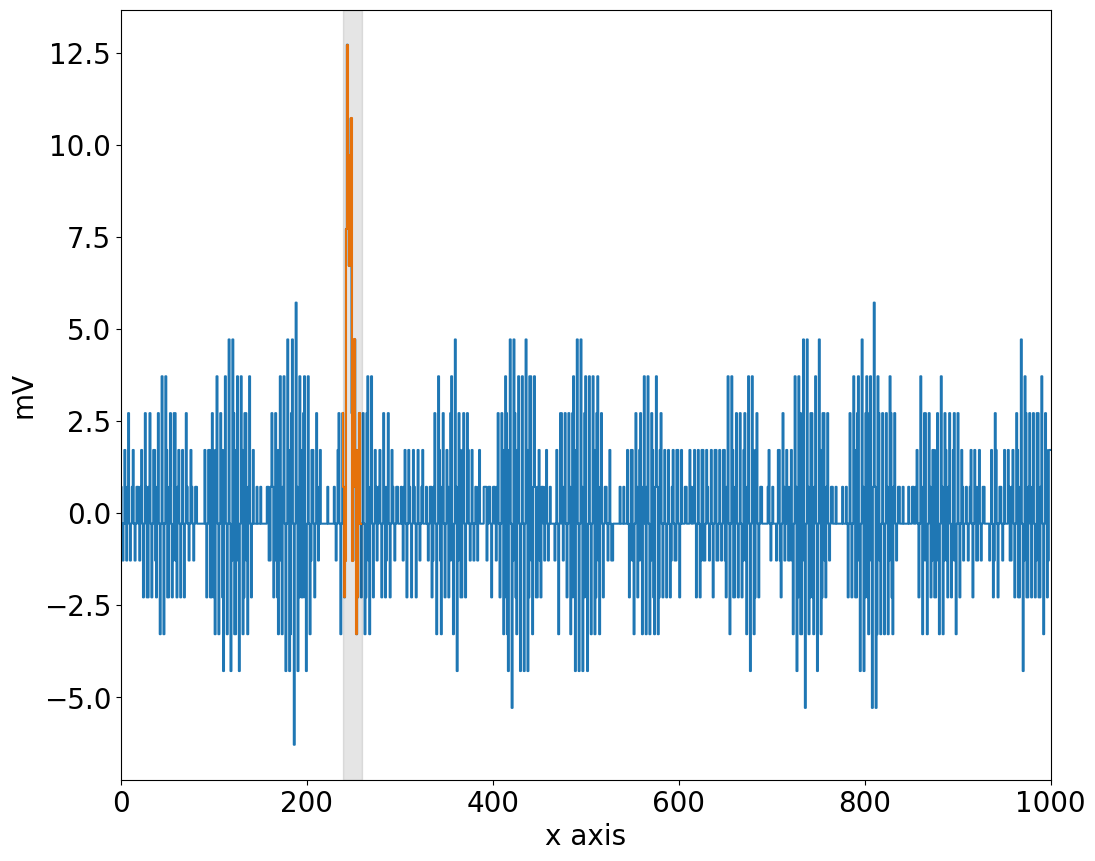

0 1


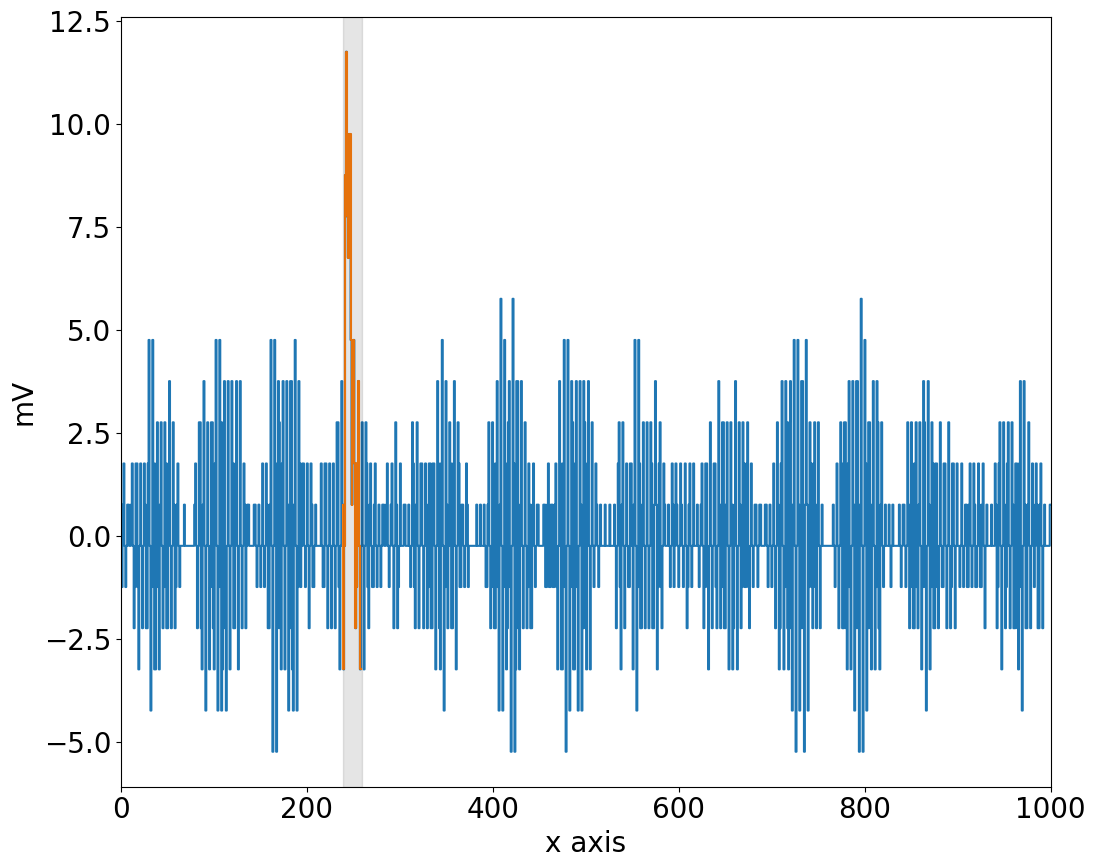

0 2


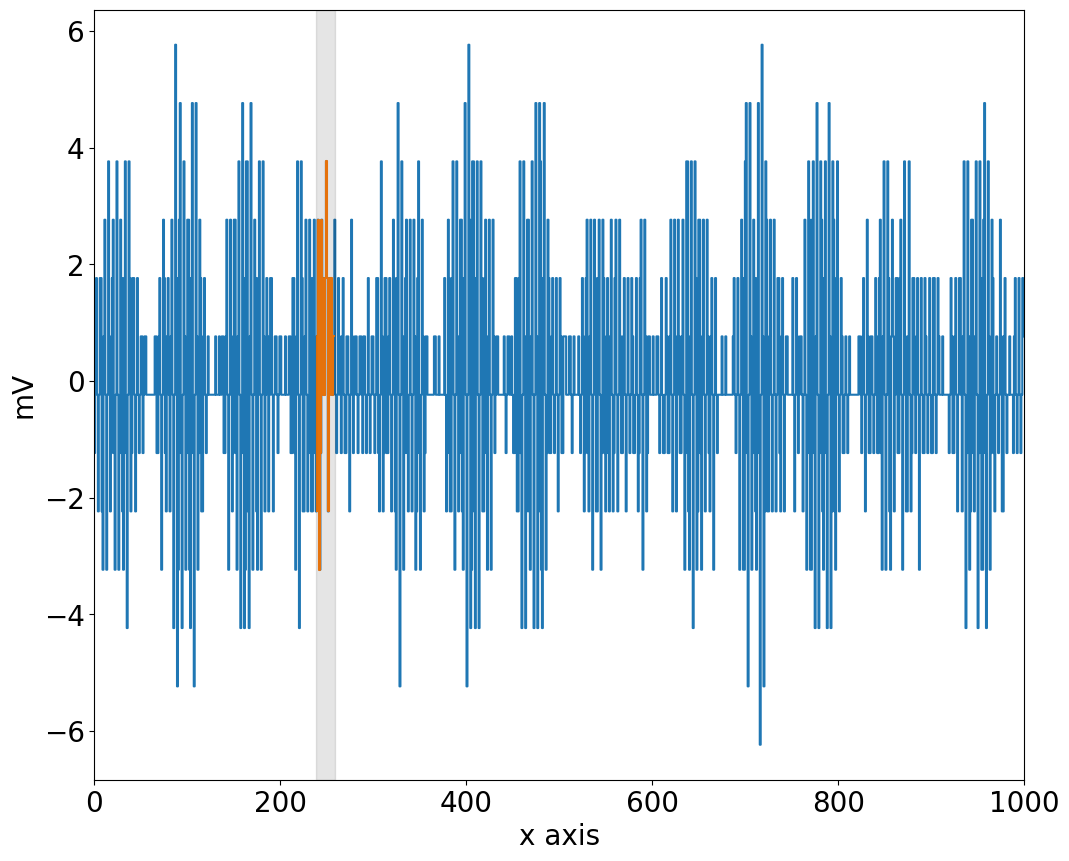

0 3


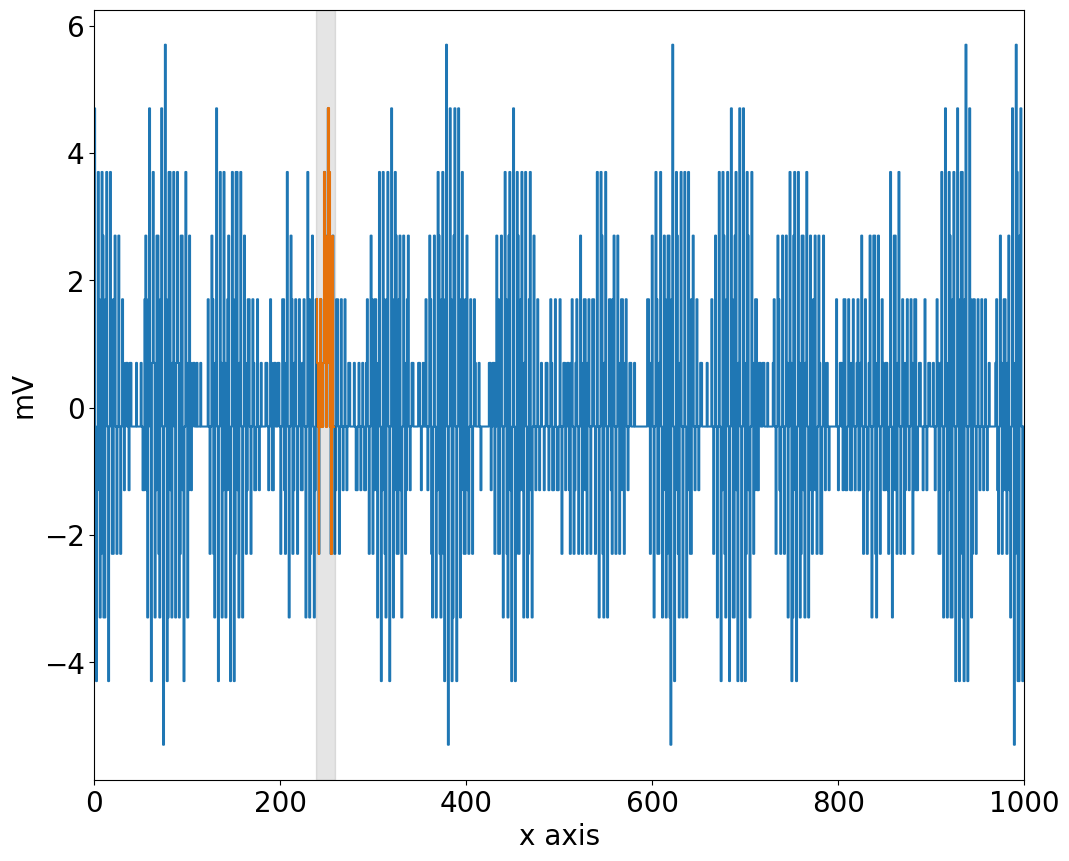

0 4


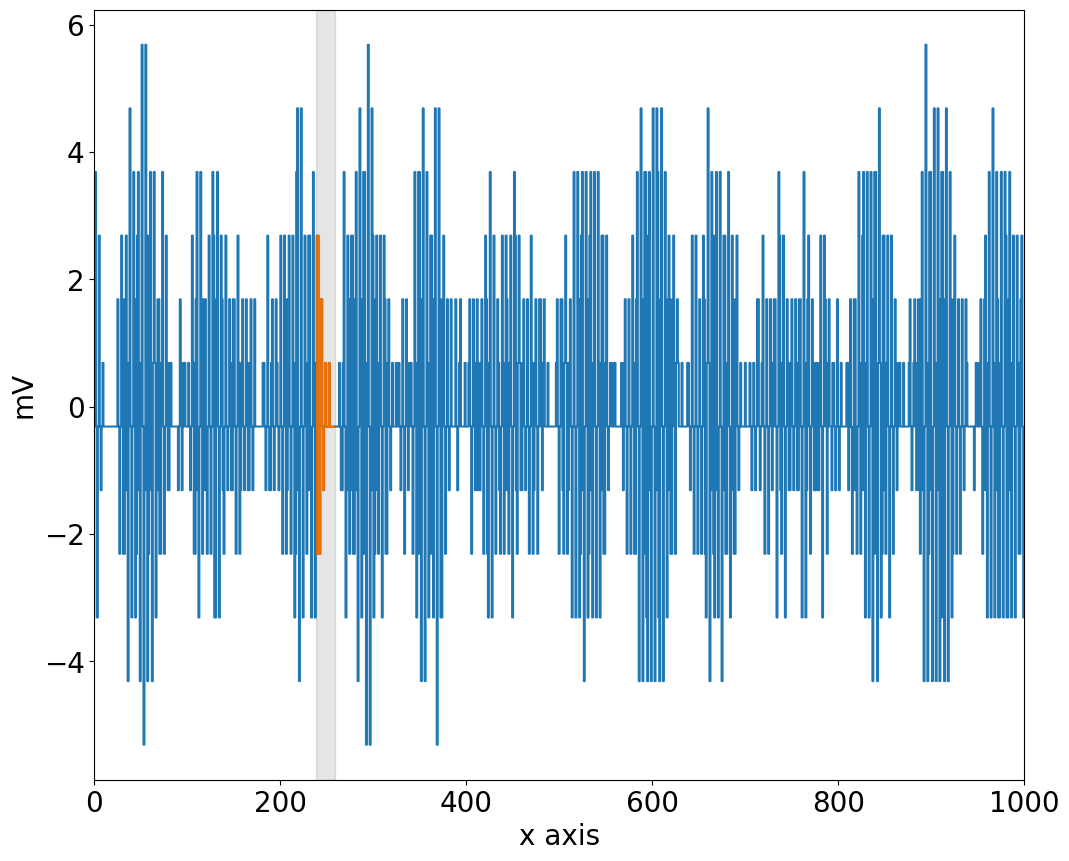

0 5


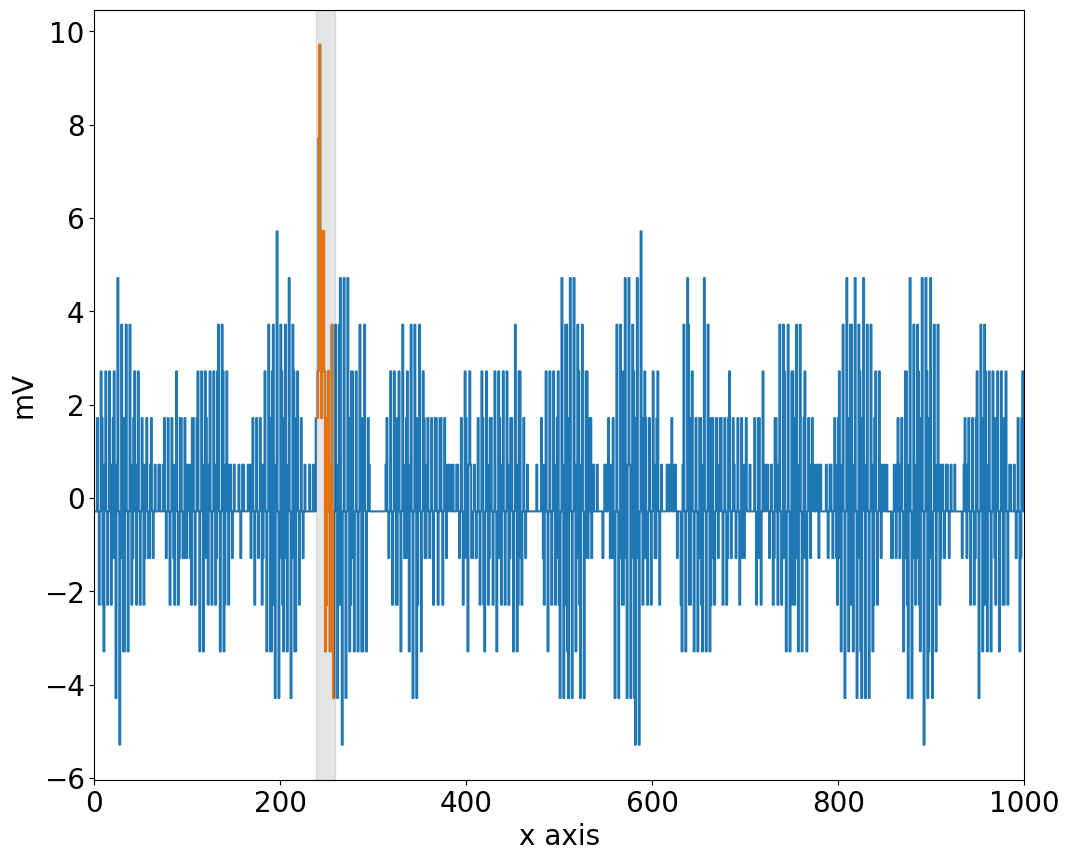

0 6


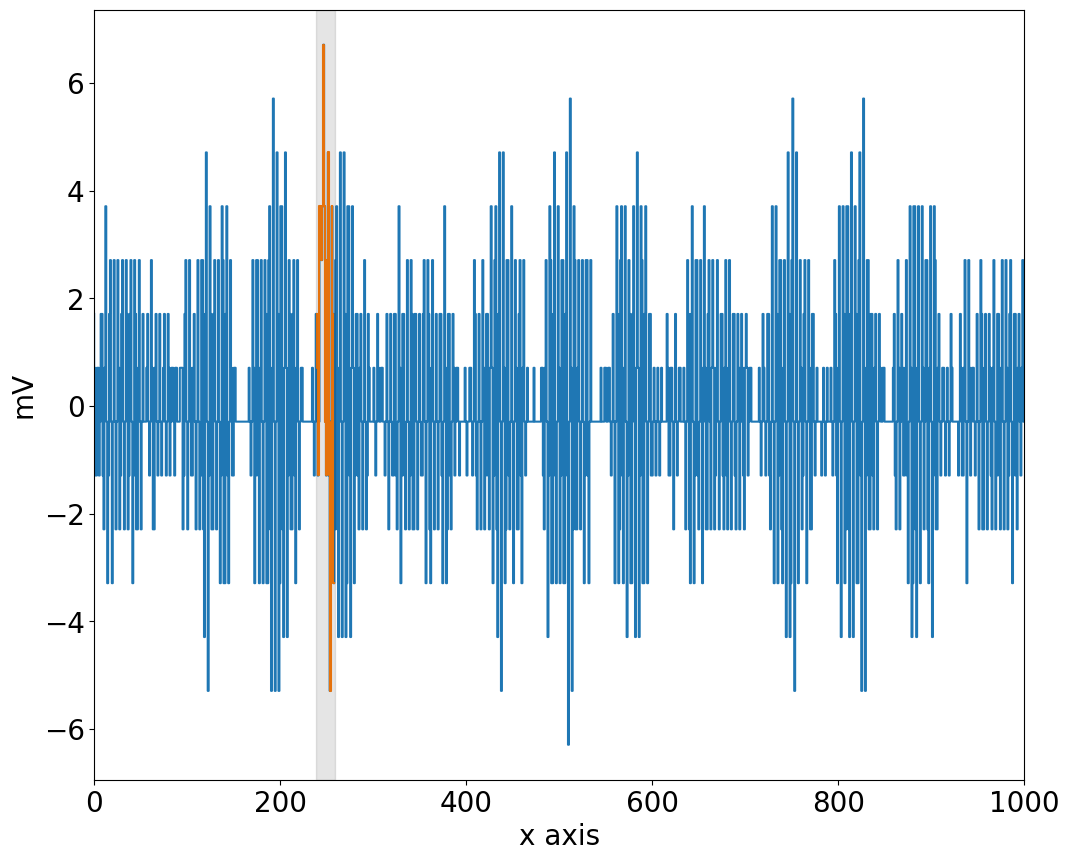

0 7


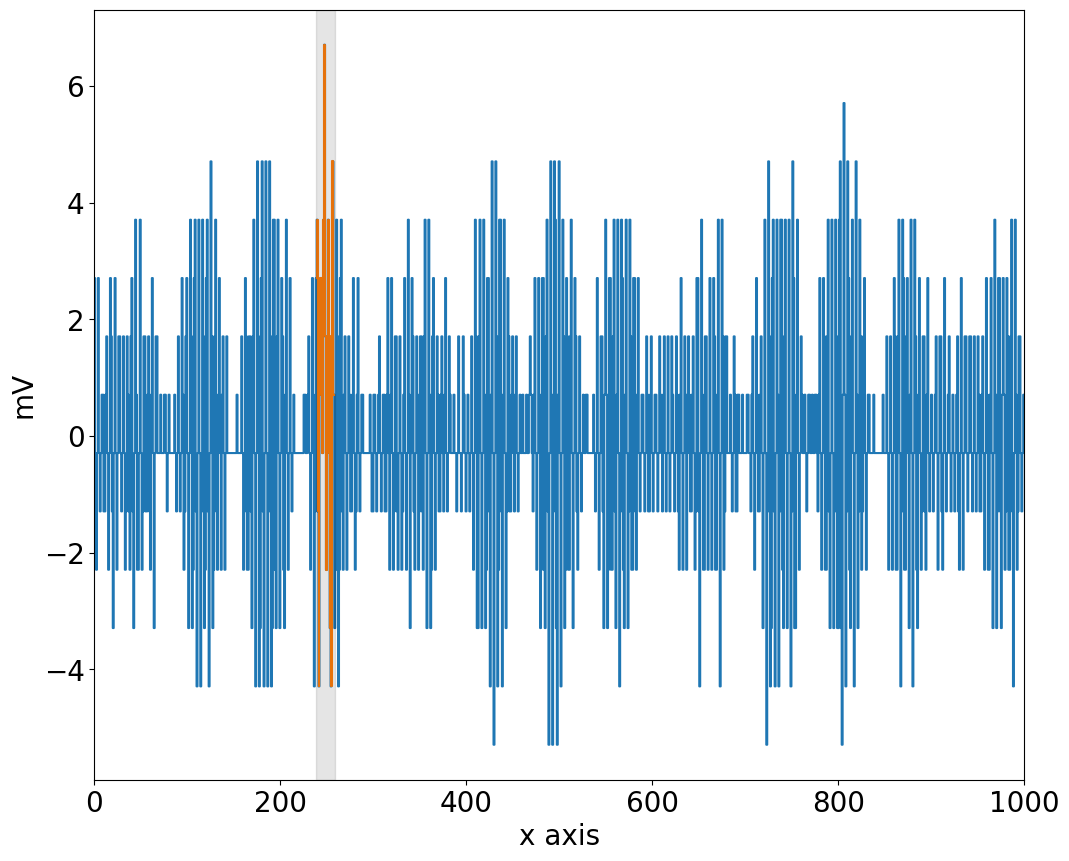

0 8


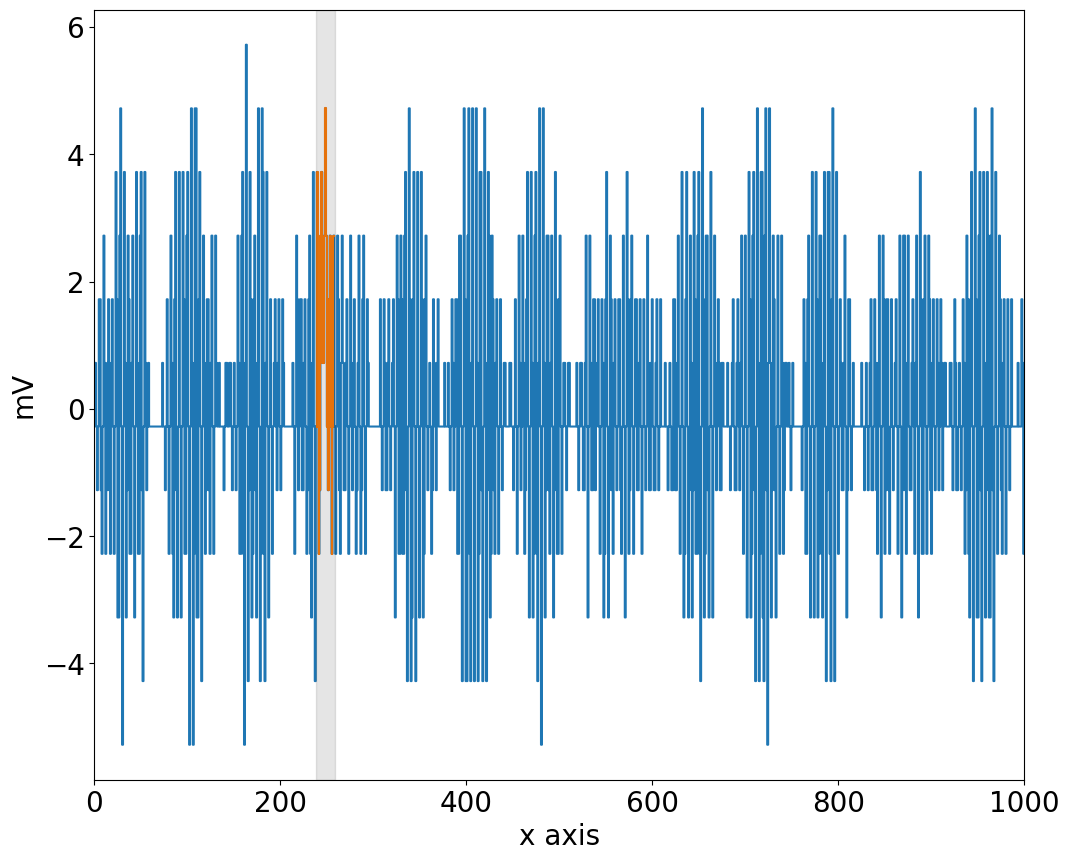

0 9


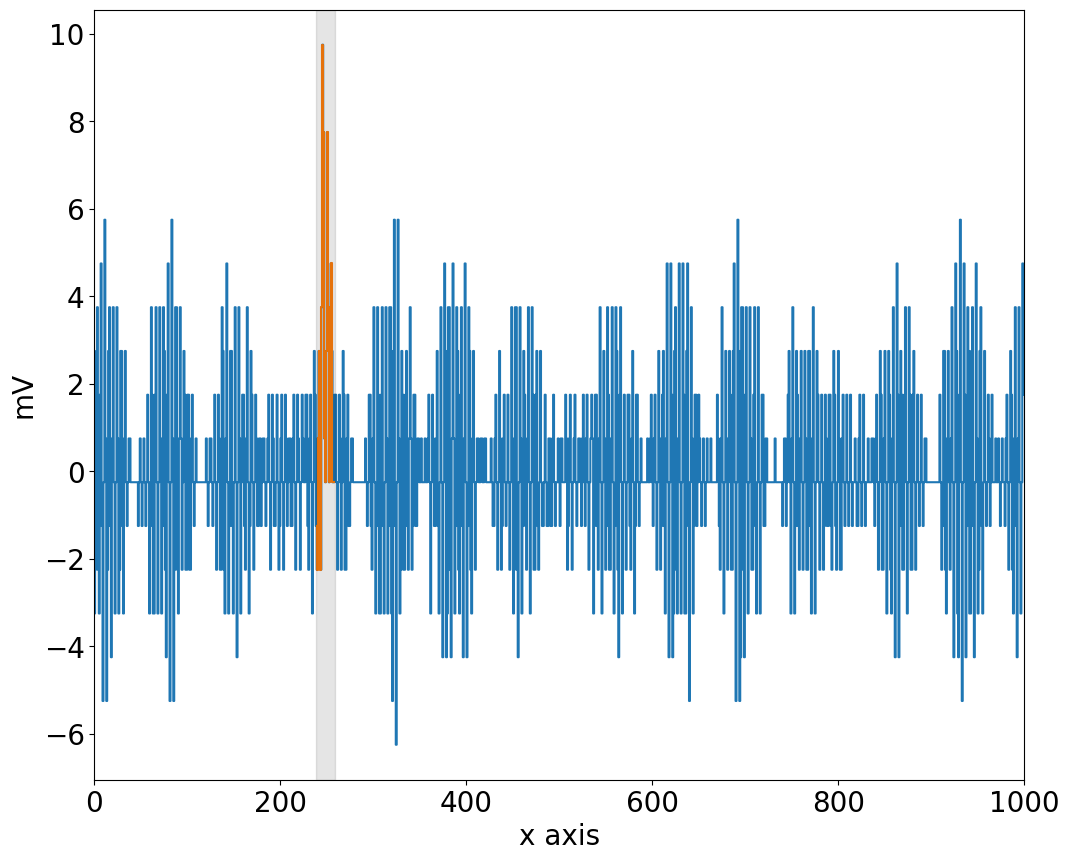

0 10


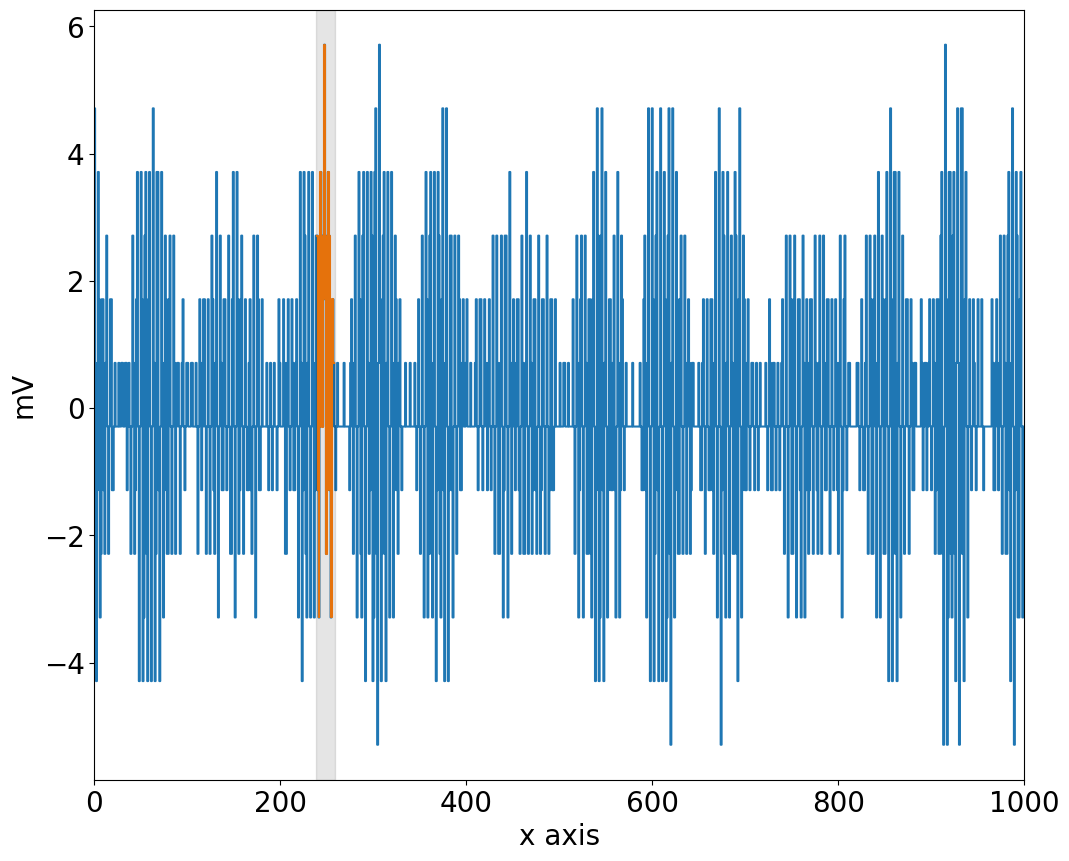

0 11


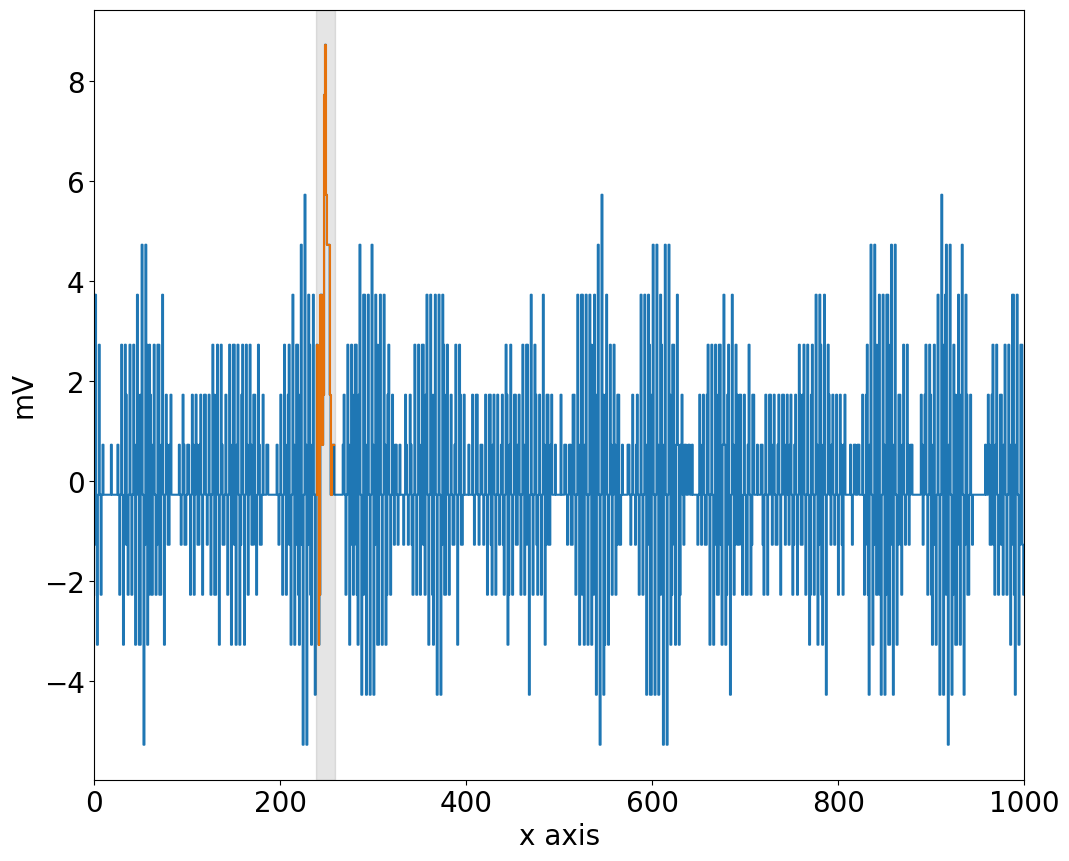

0 12


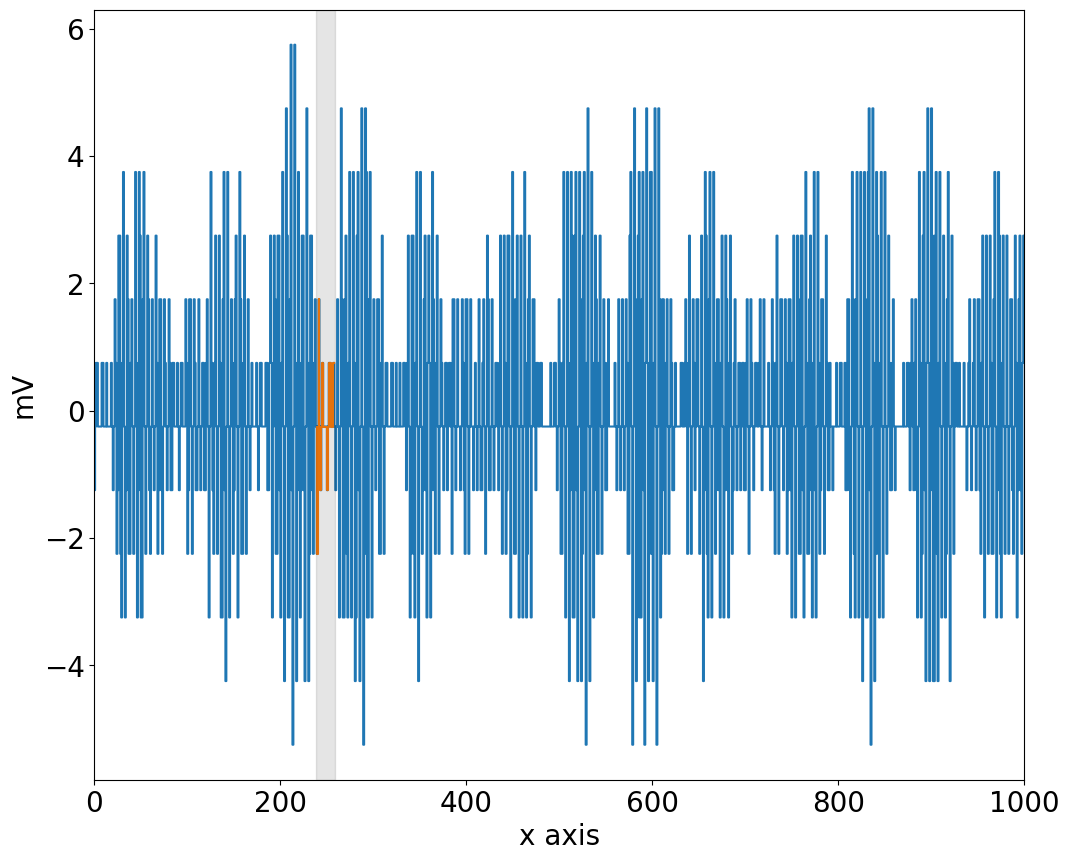

0 13


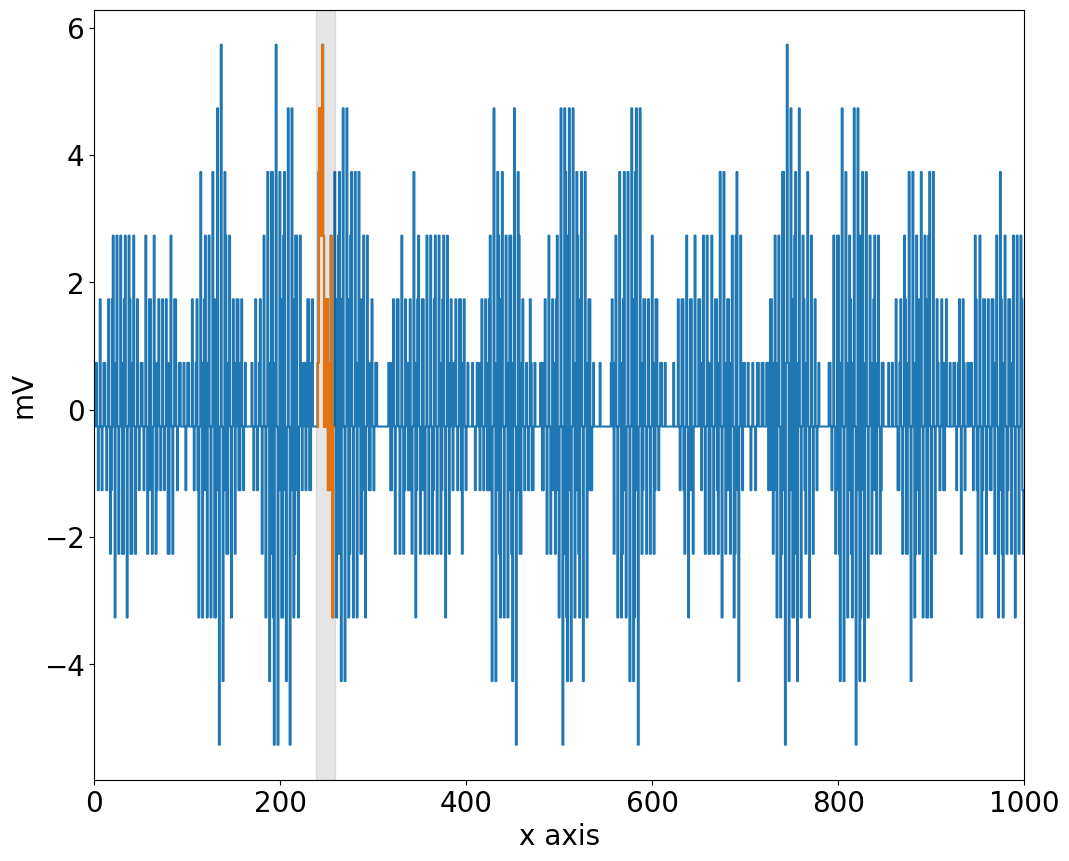

0 14


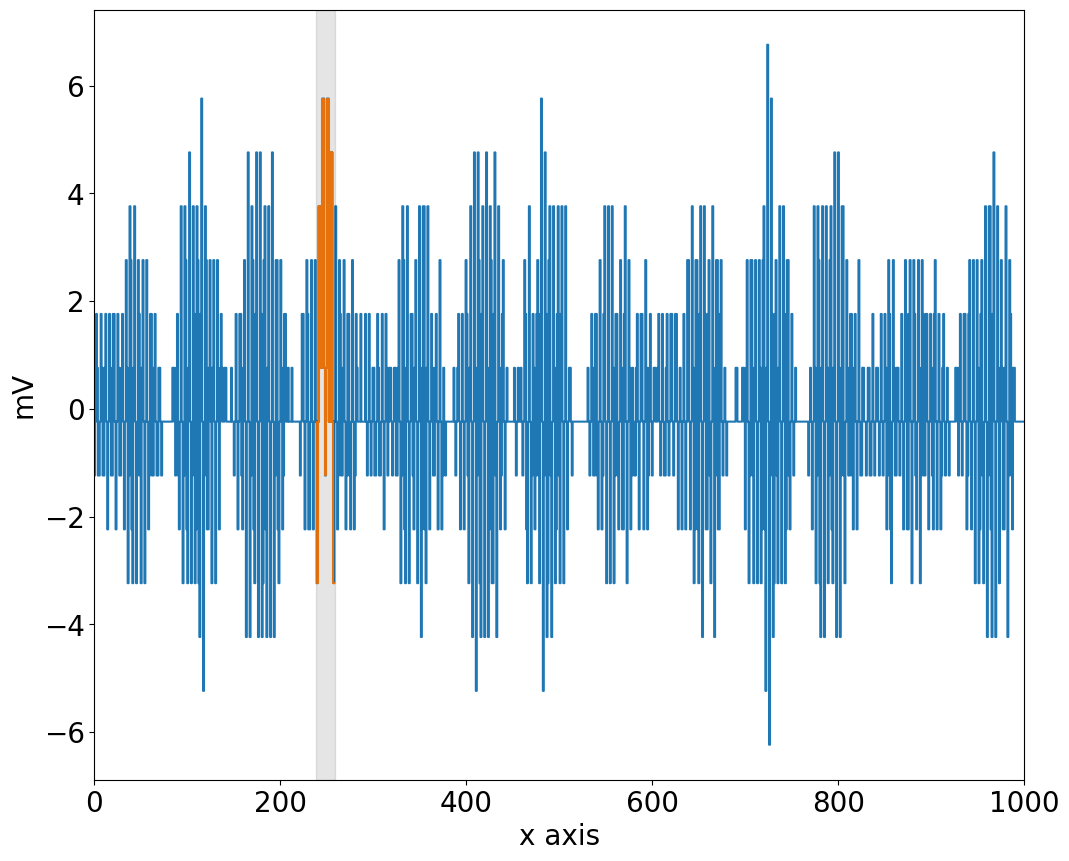

0 15


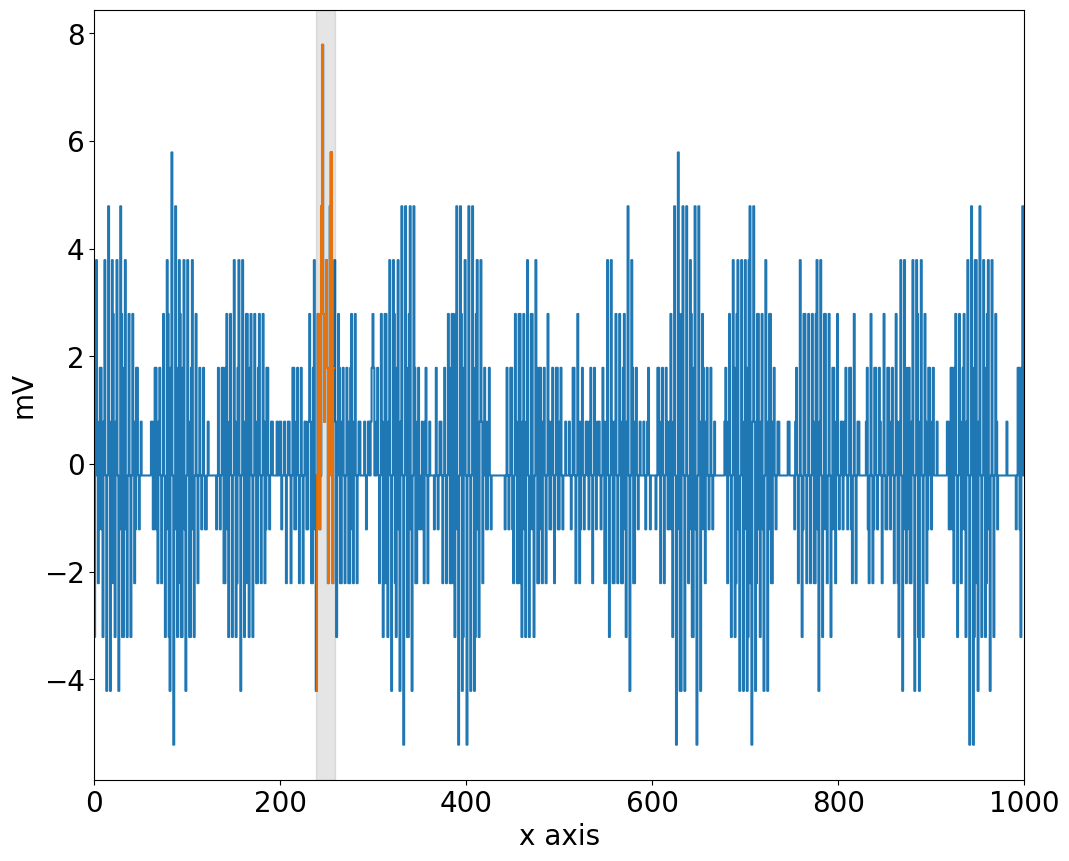

0 16


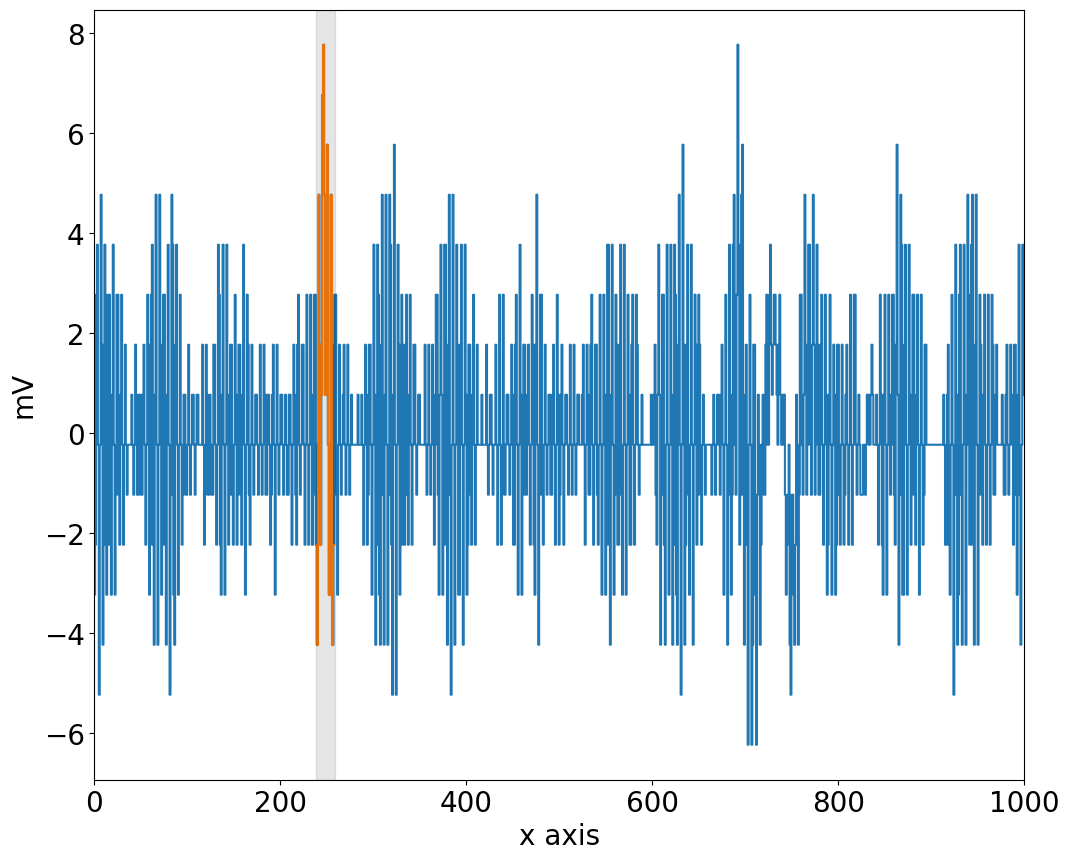

0 17


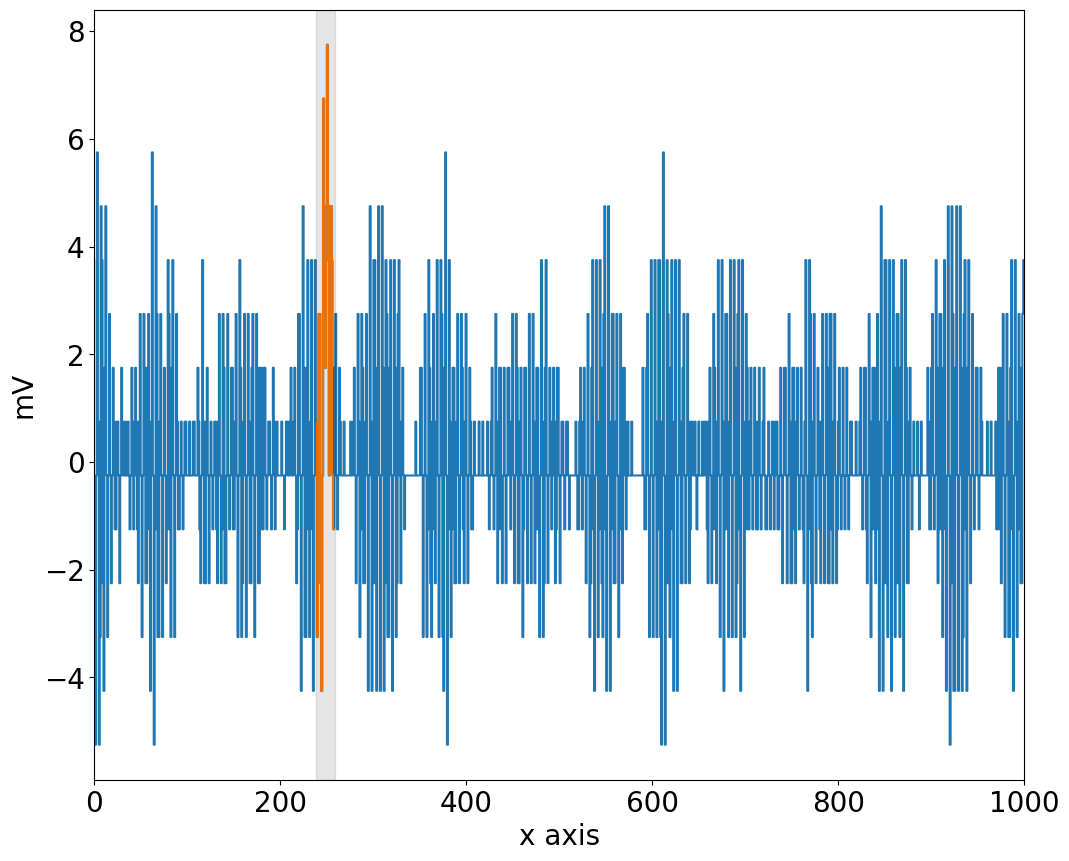

0 18


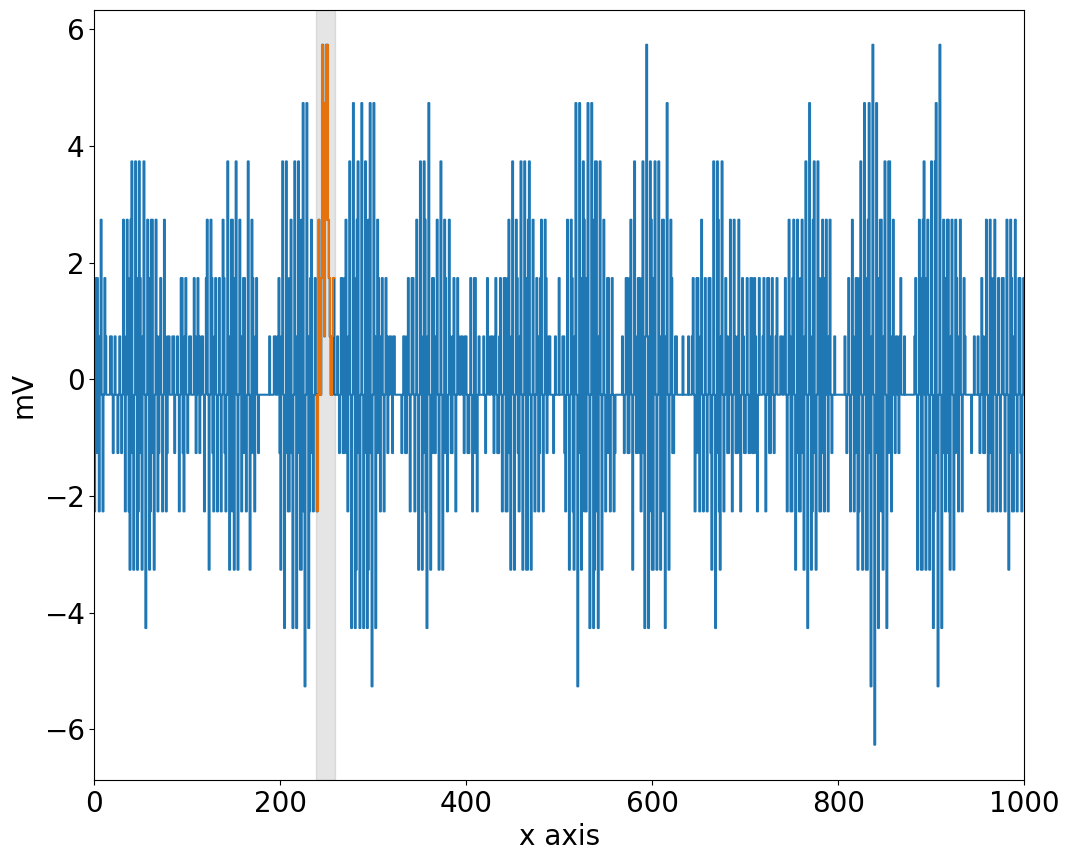

0 19


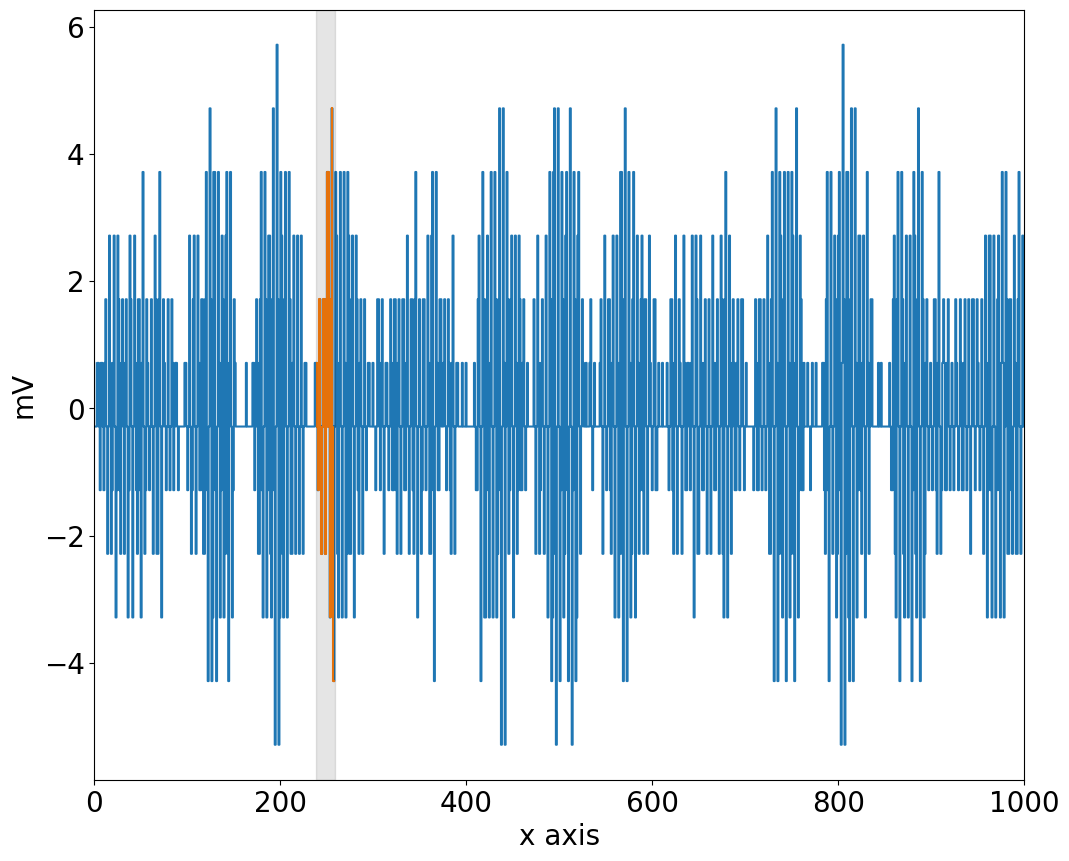

0 20


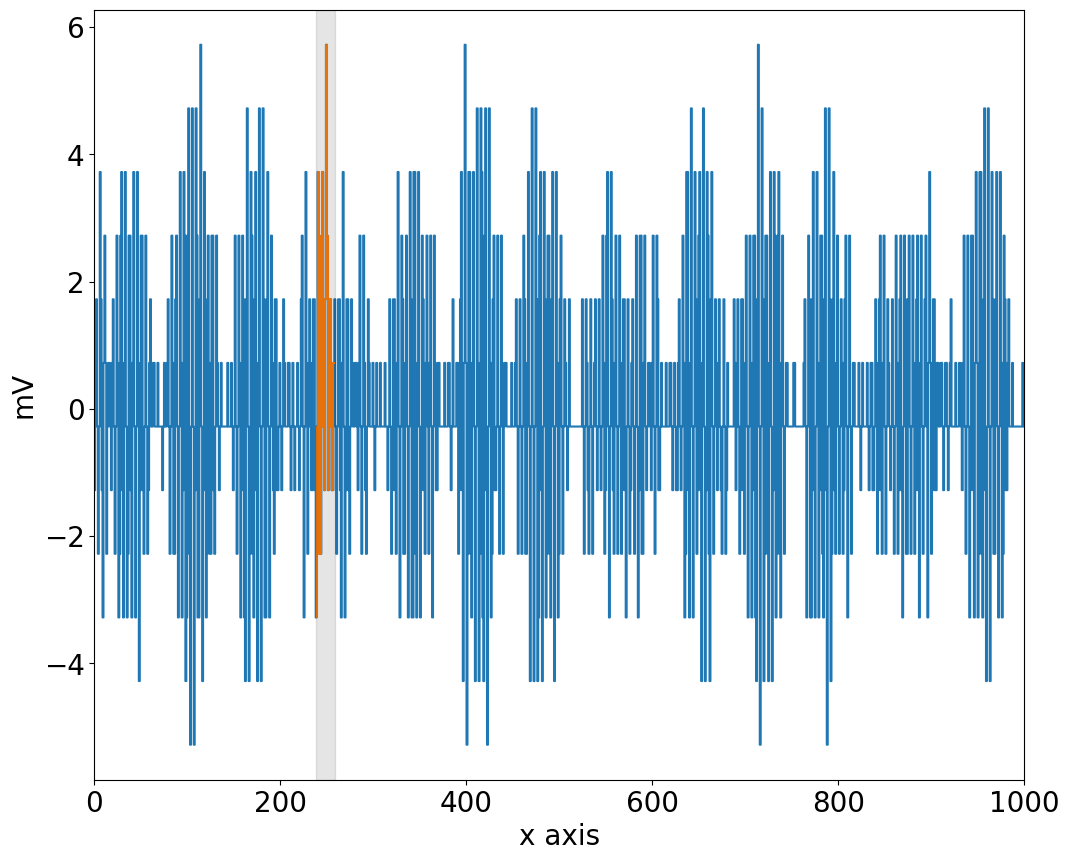

0 21


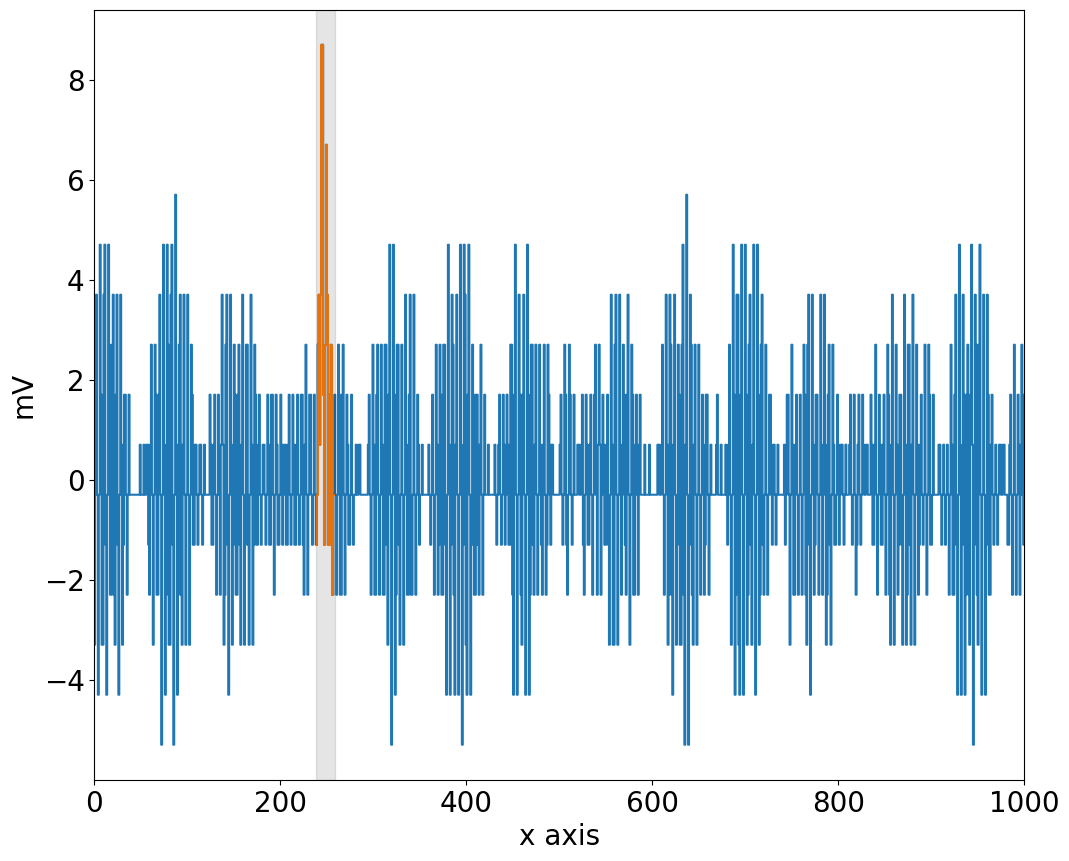

0 22


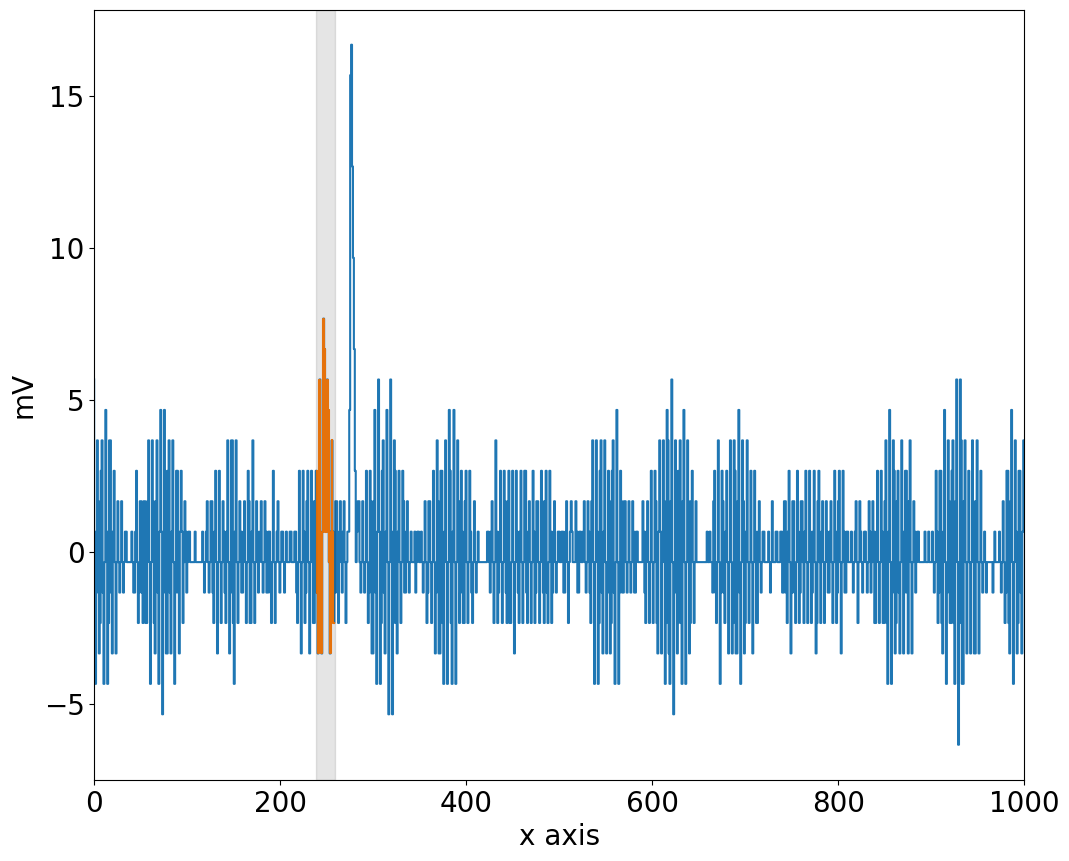

0 23


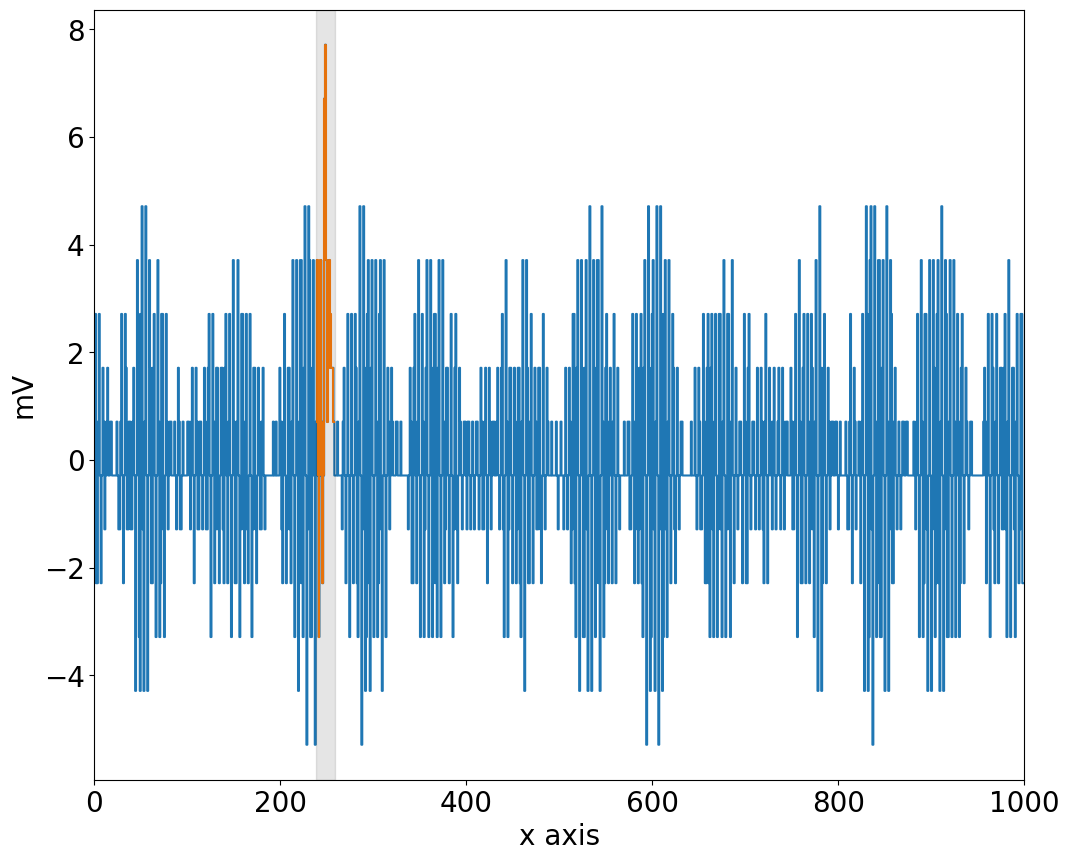

0 24


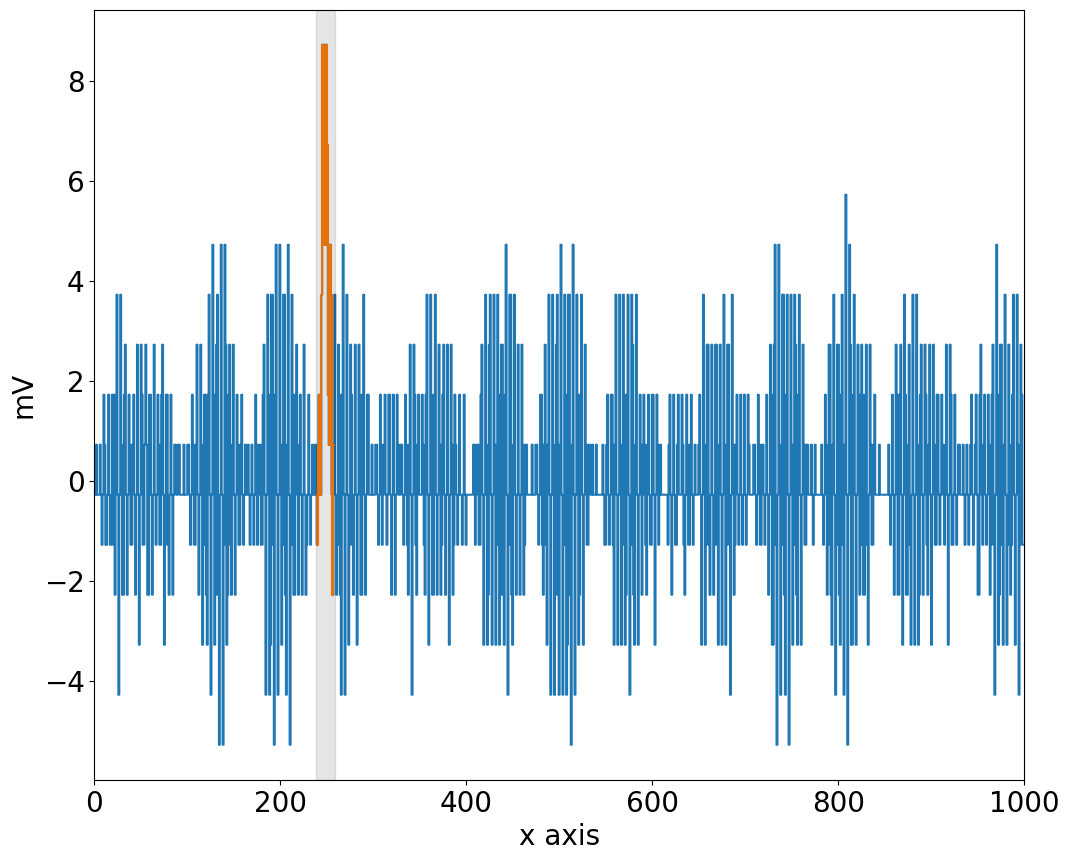

0 25


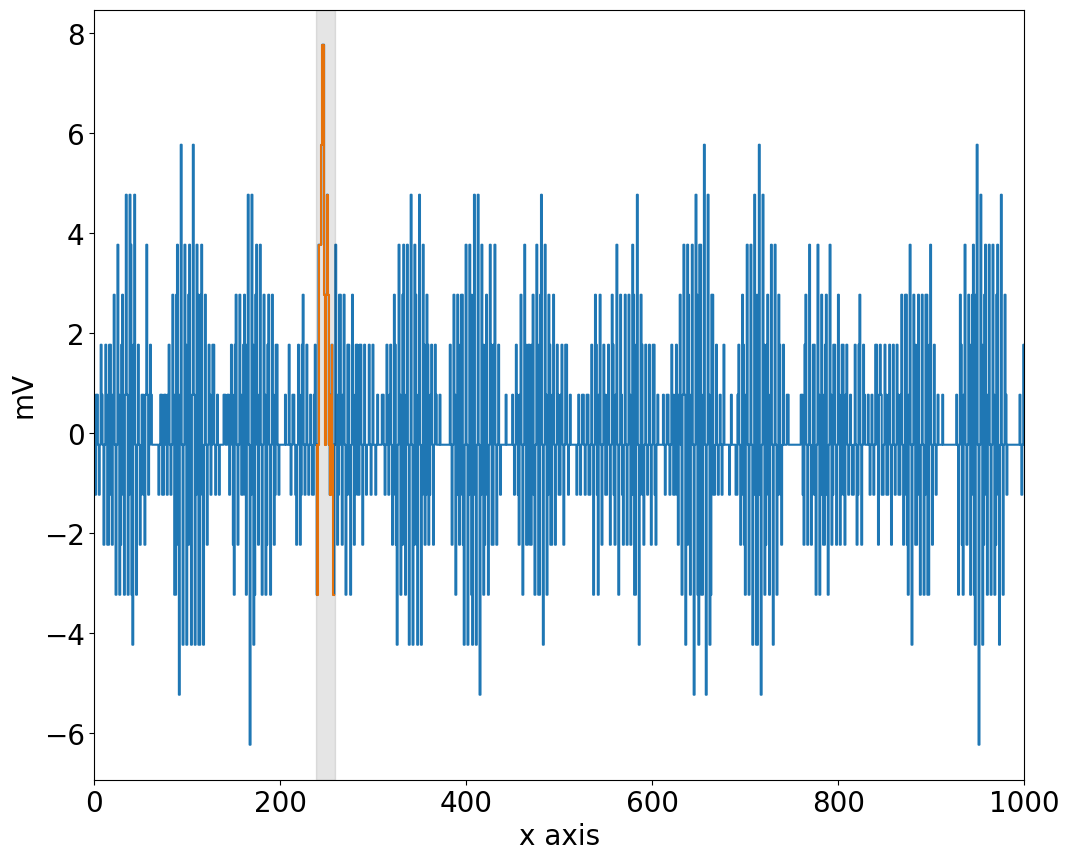

0 26


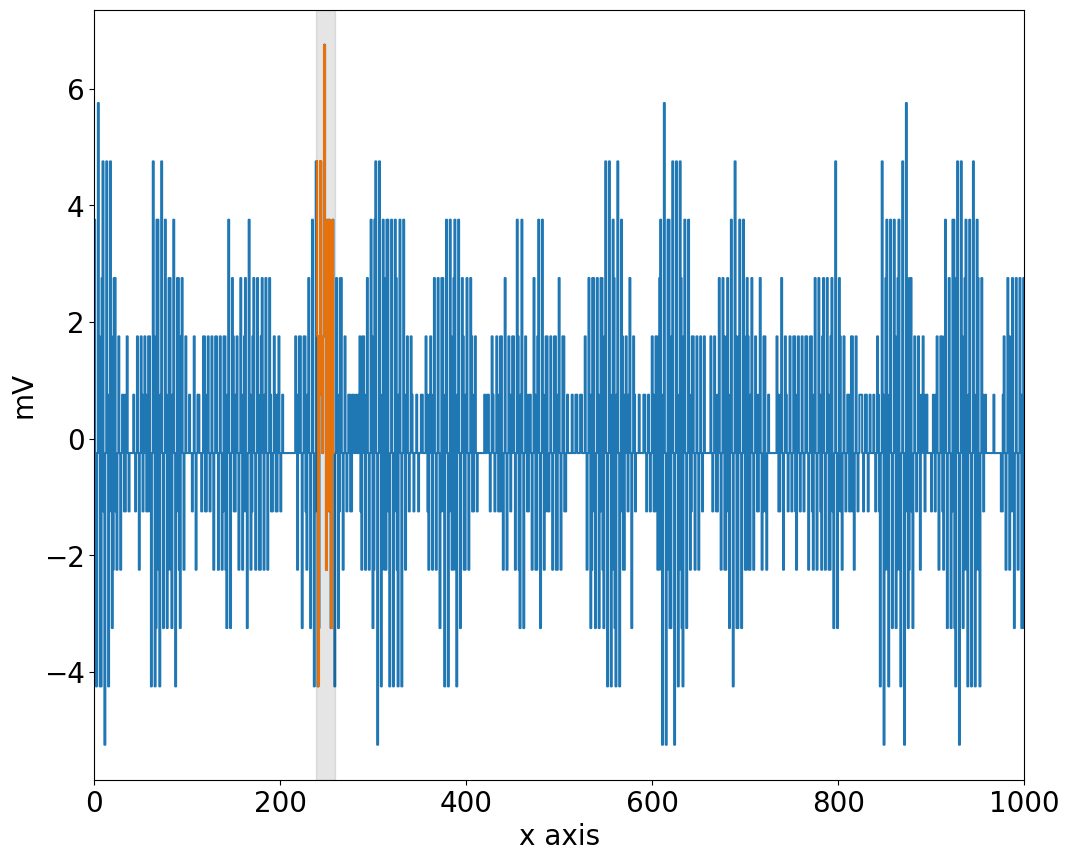

0 27


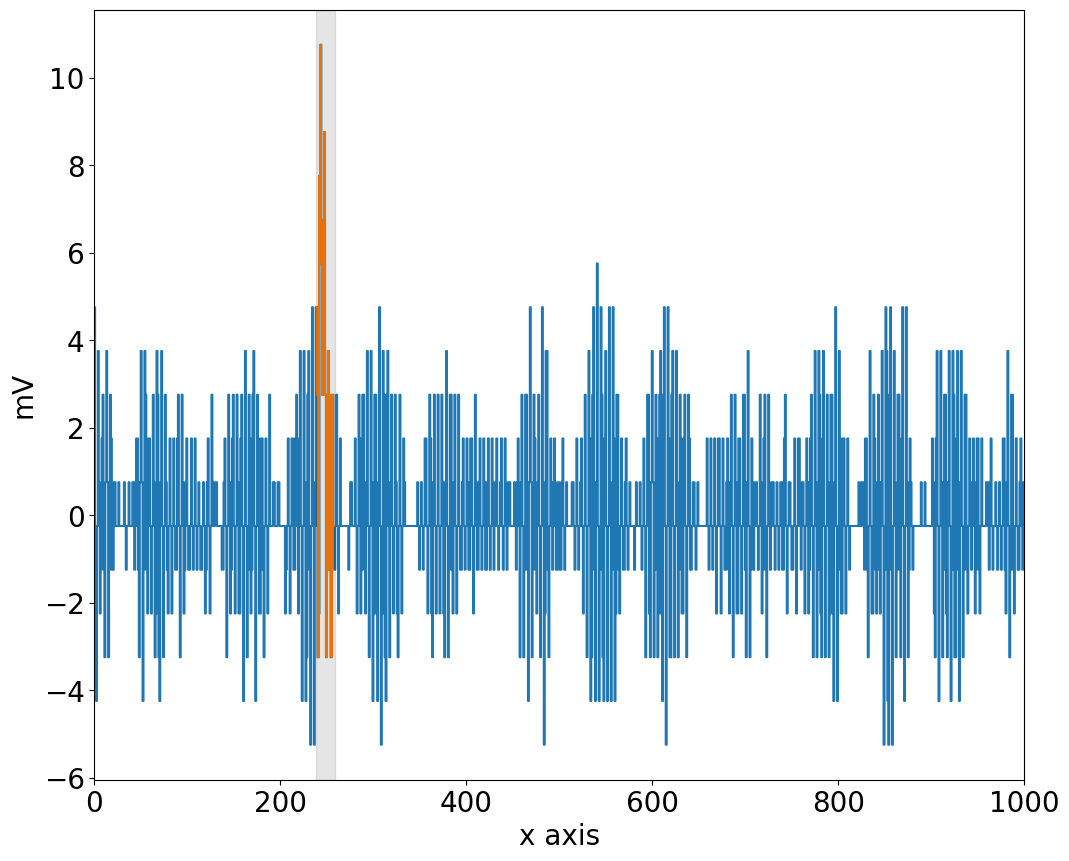

0 28


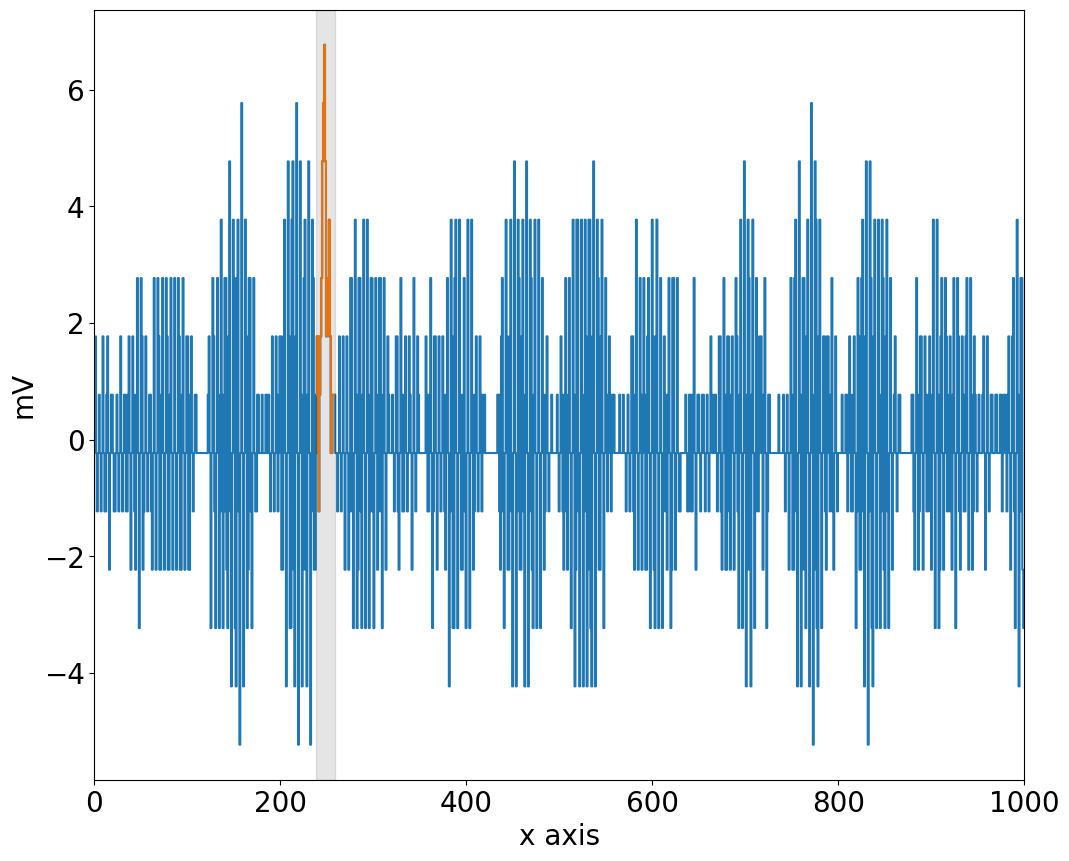

0 29


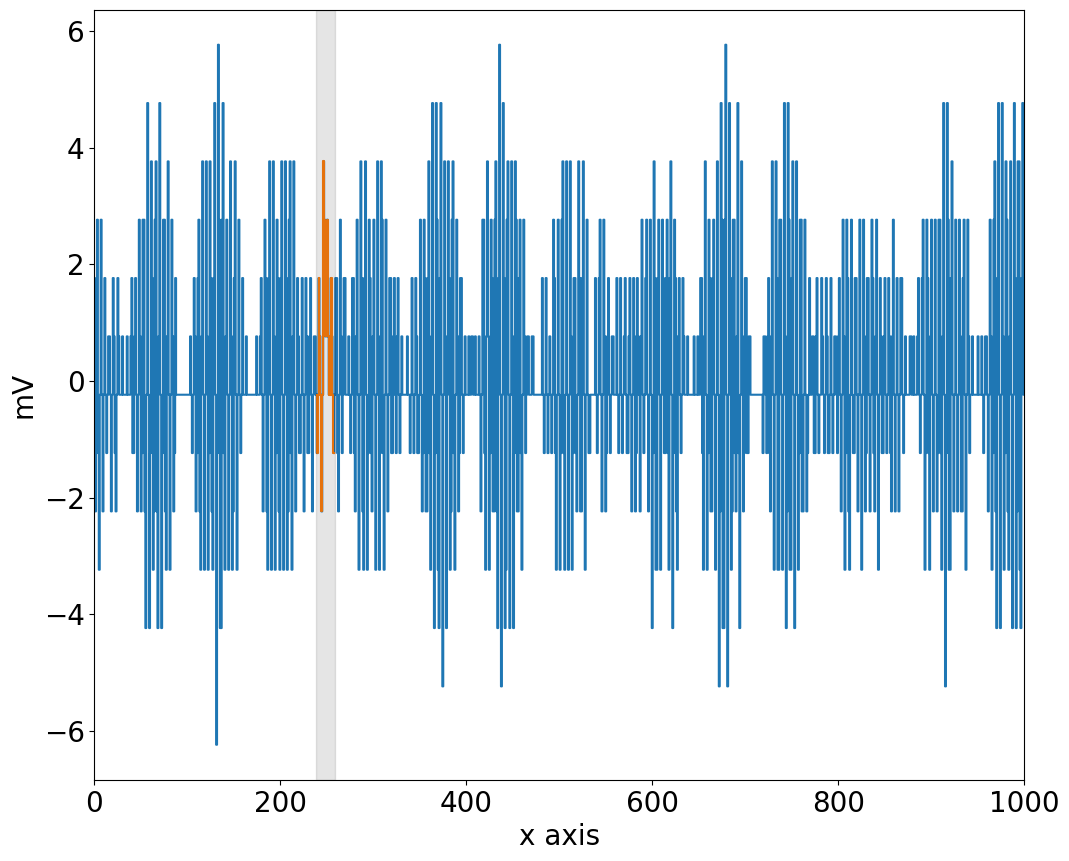

0 30


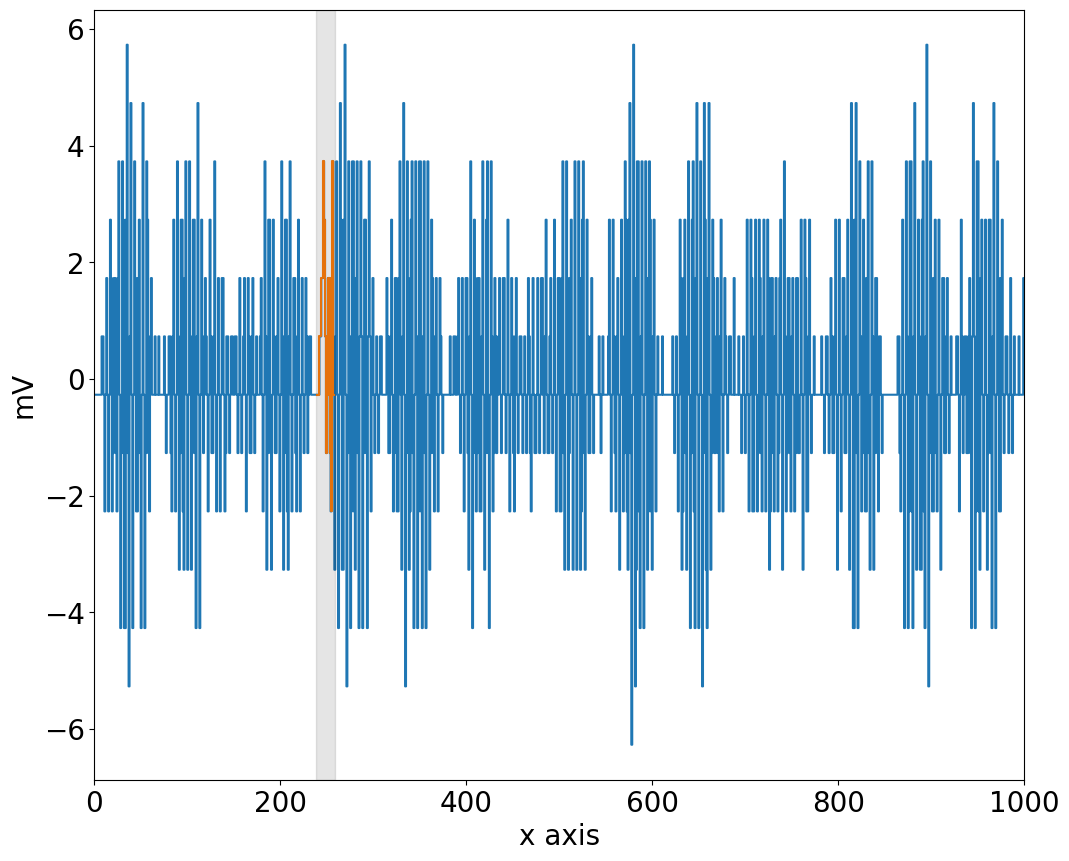

0 31


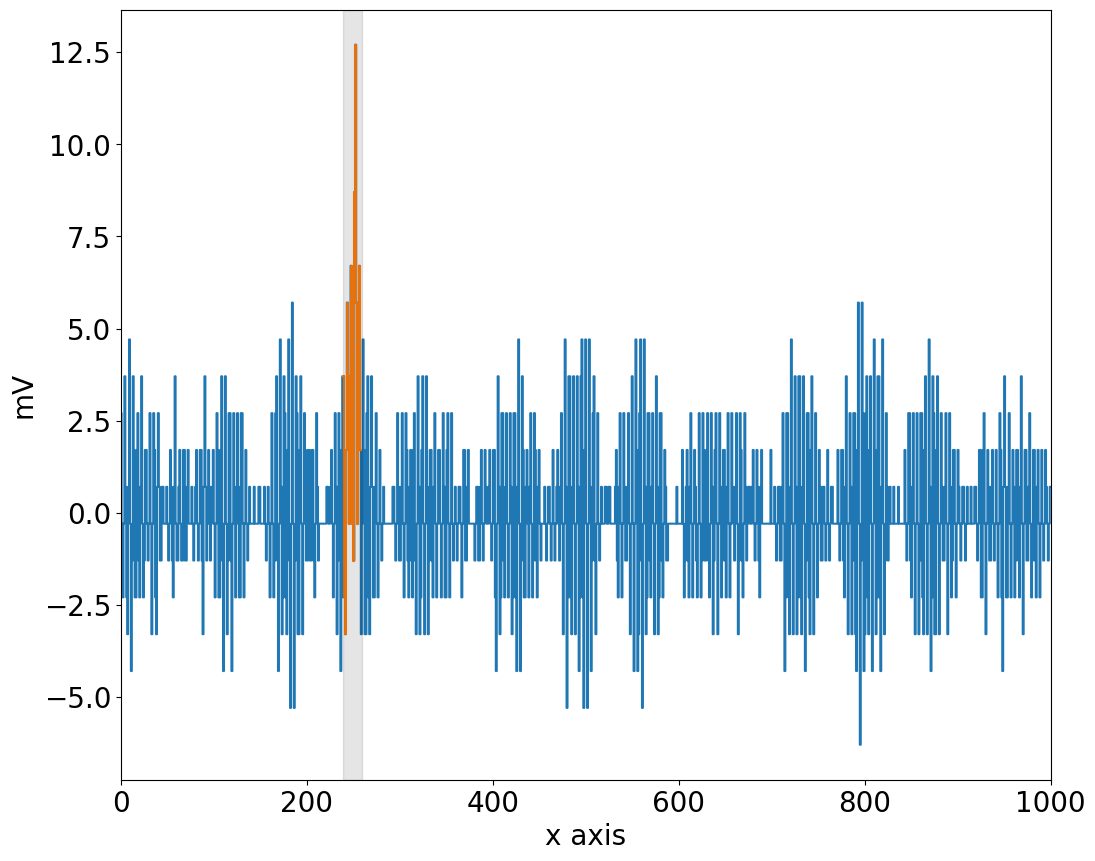

0 32


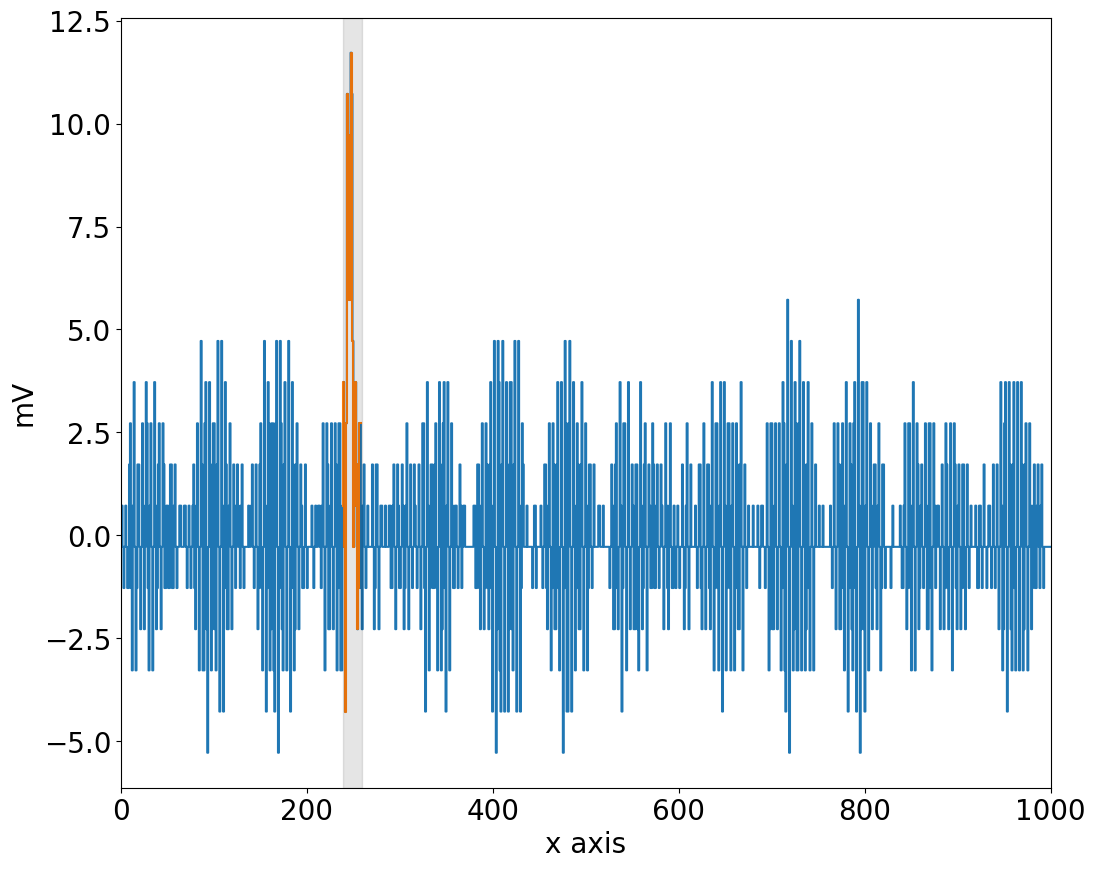

0 33


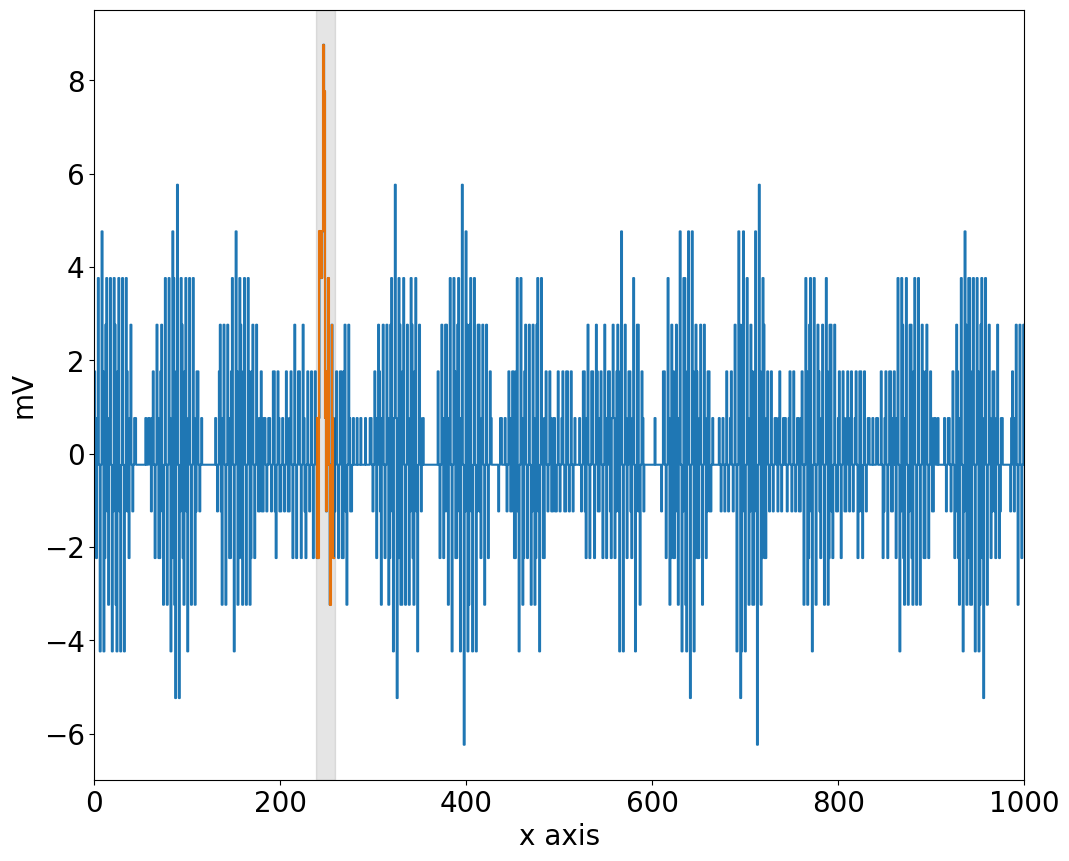

0 34


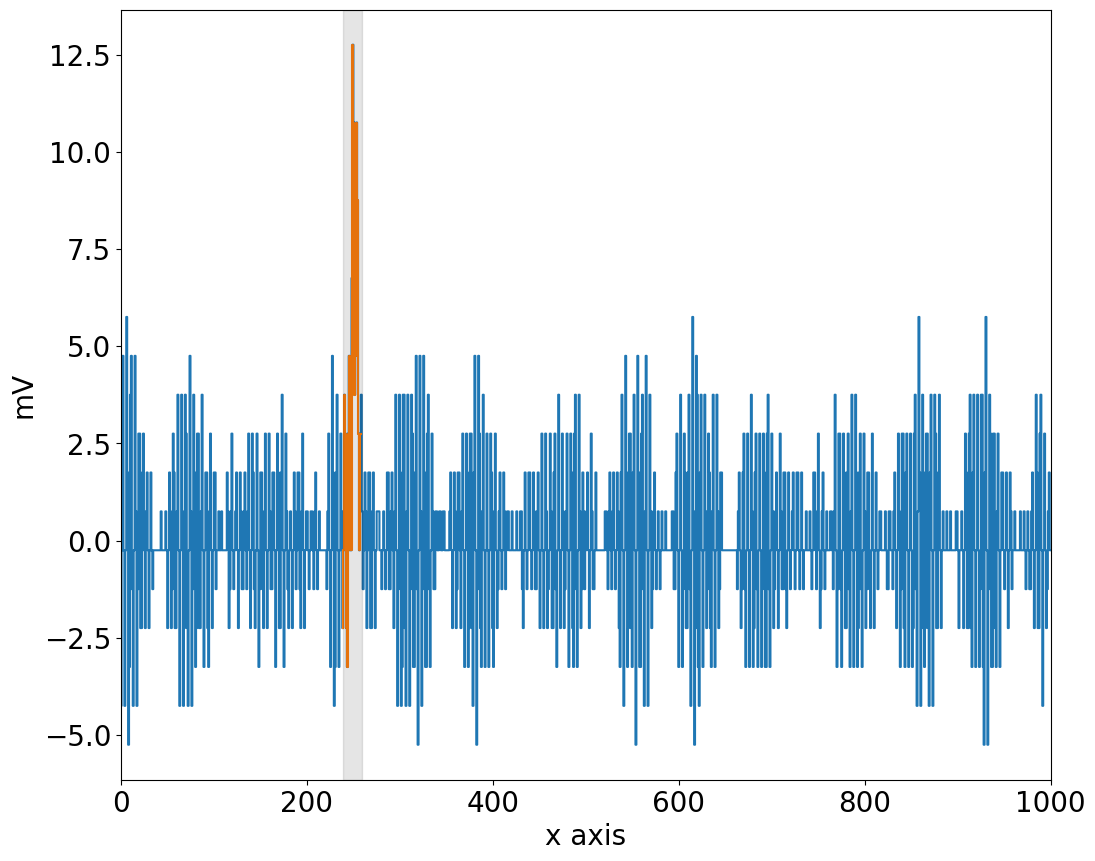

0 35


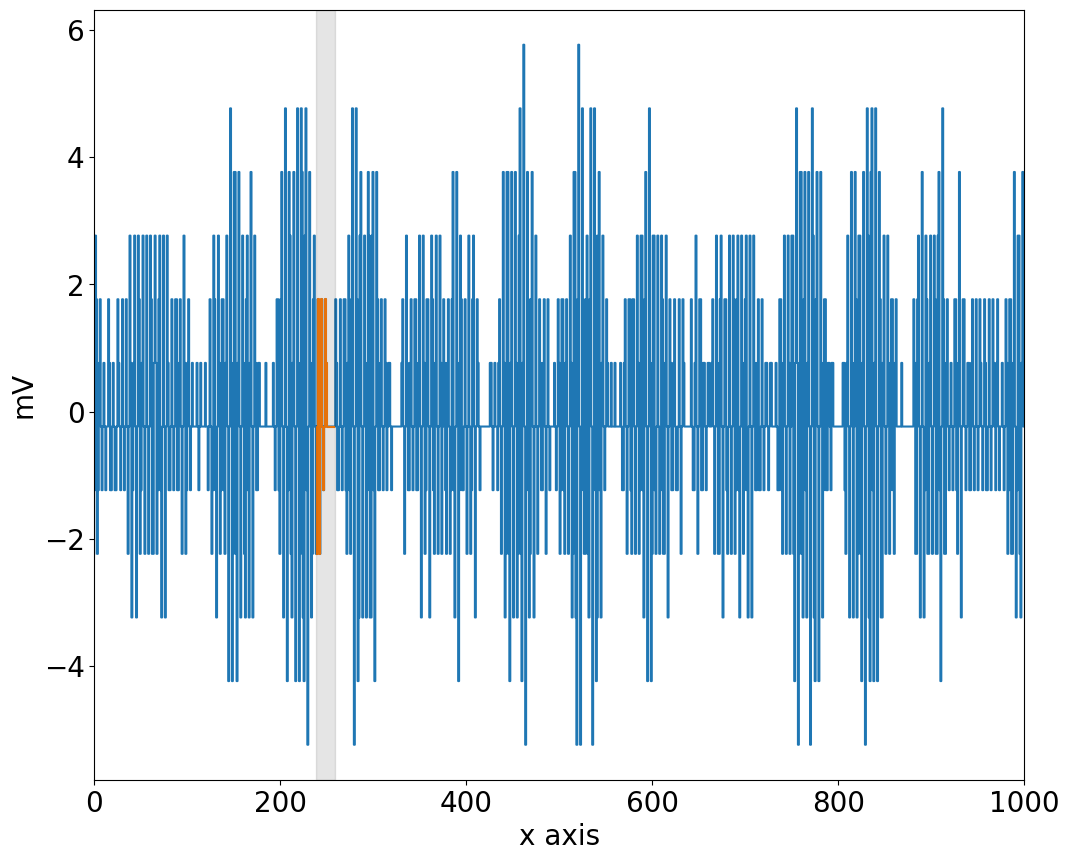

0 36


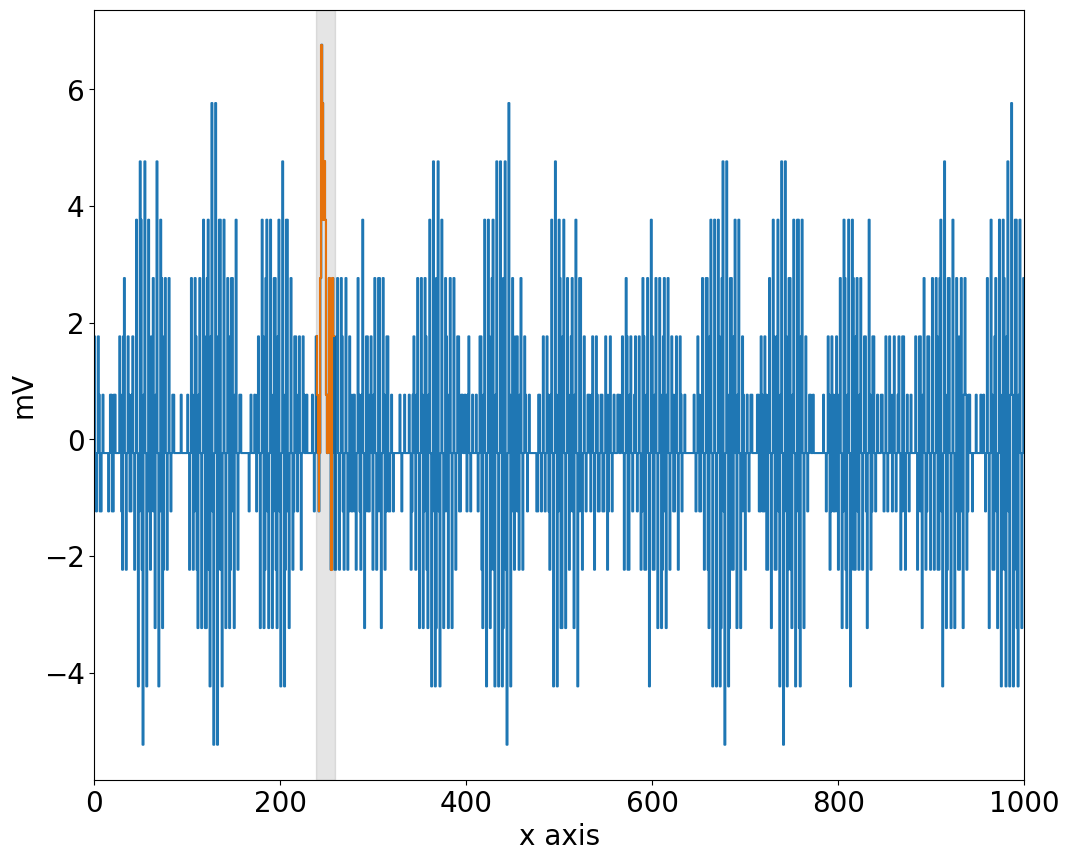

0 37


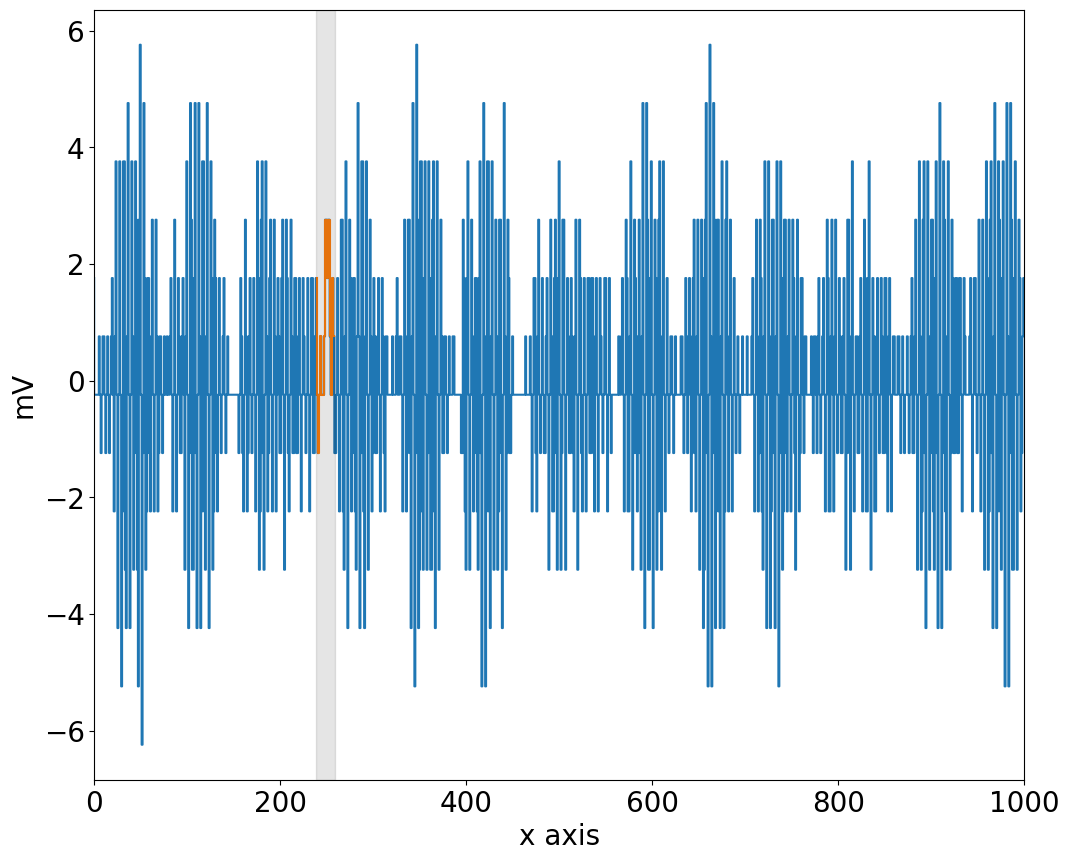

0 38


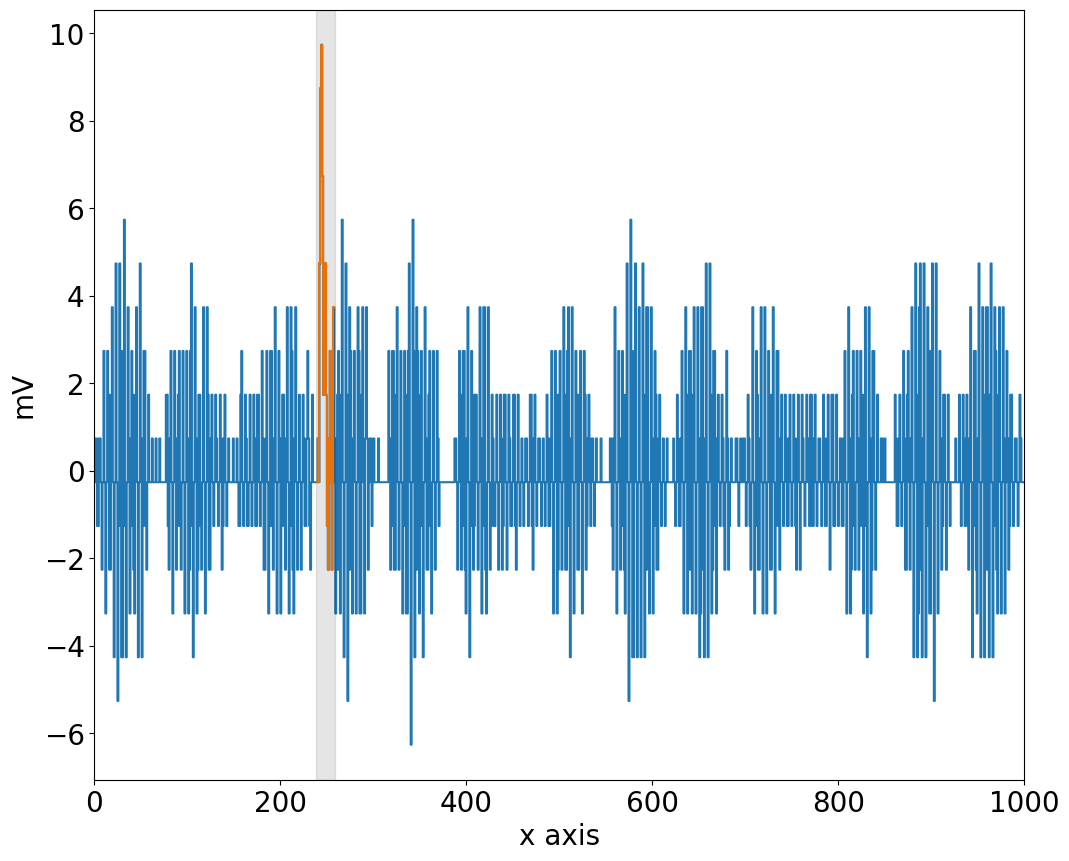

0 39


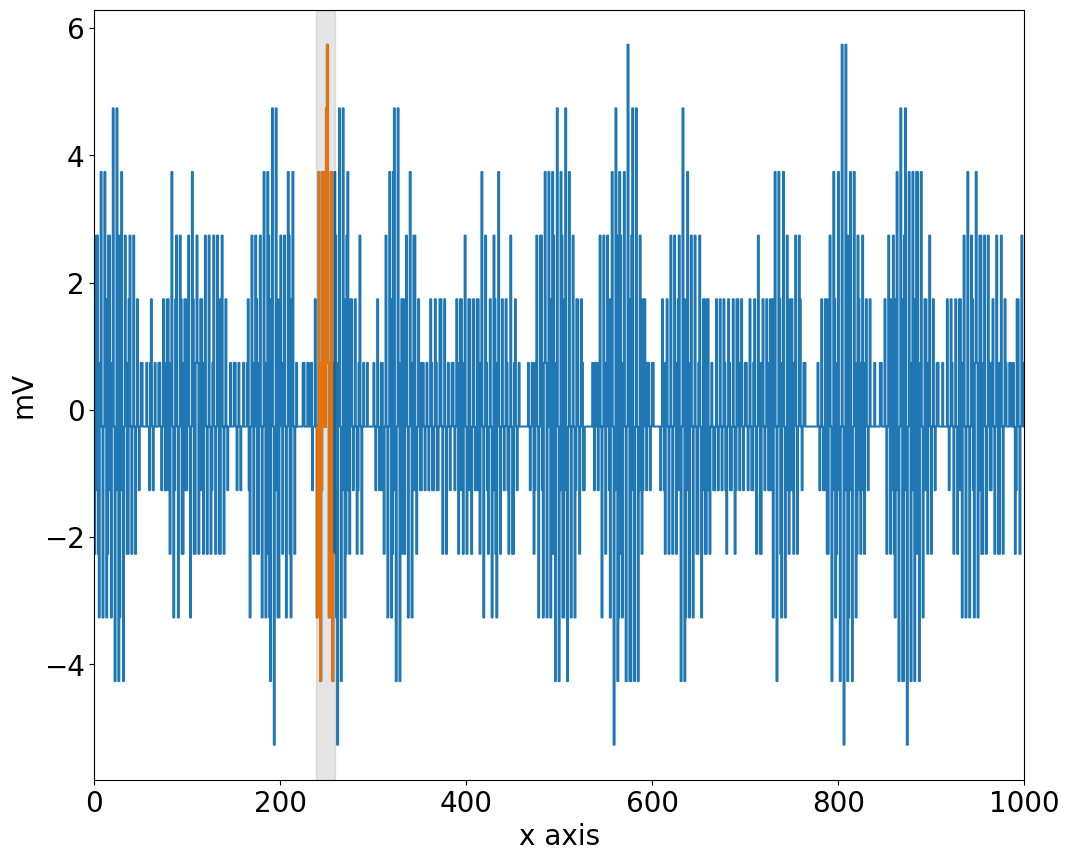

0 40


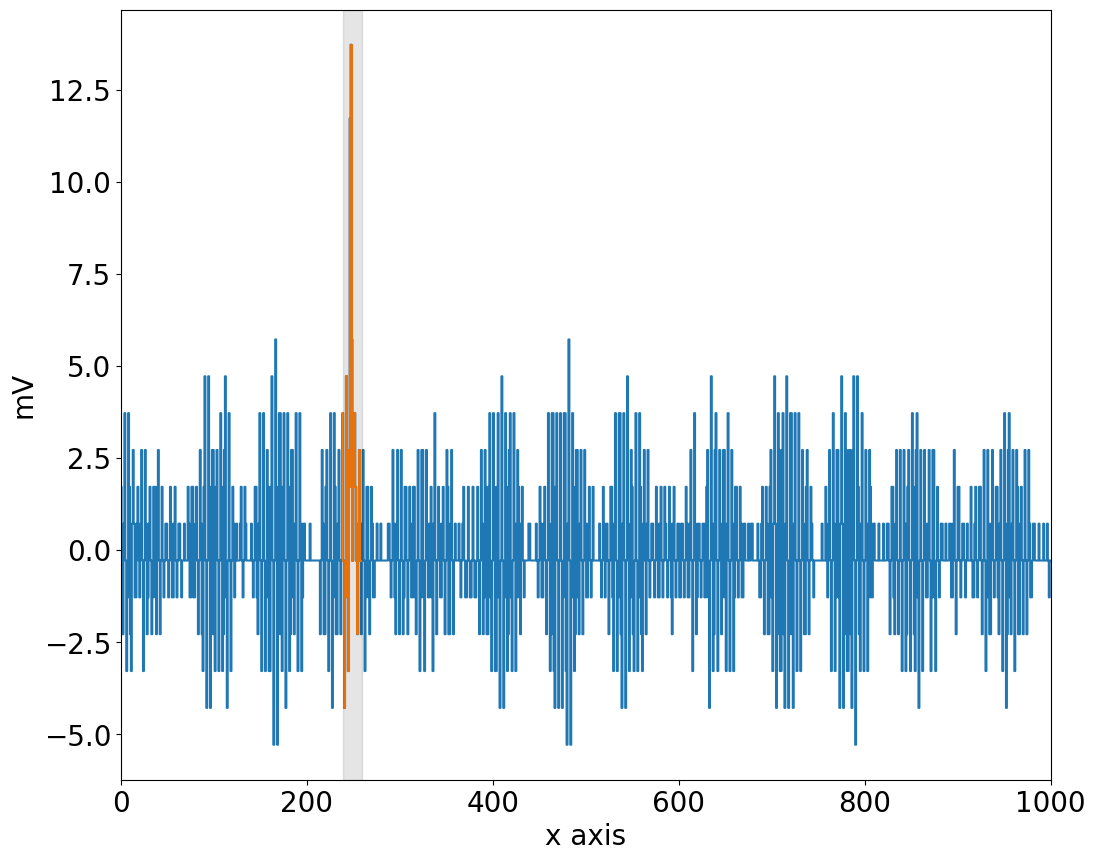

0 41


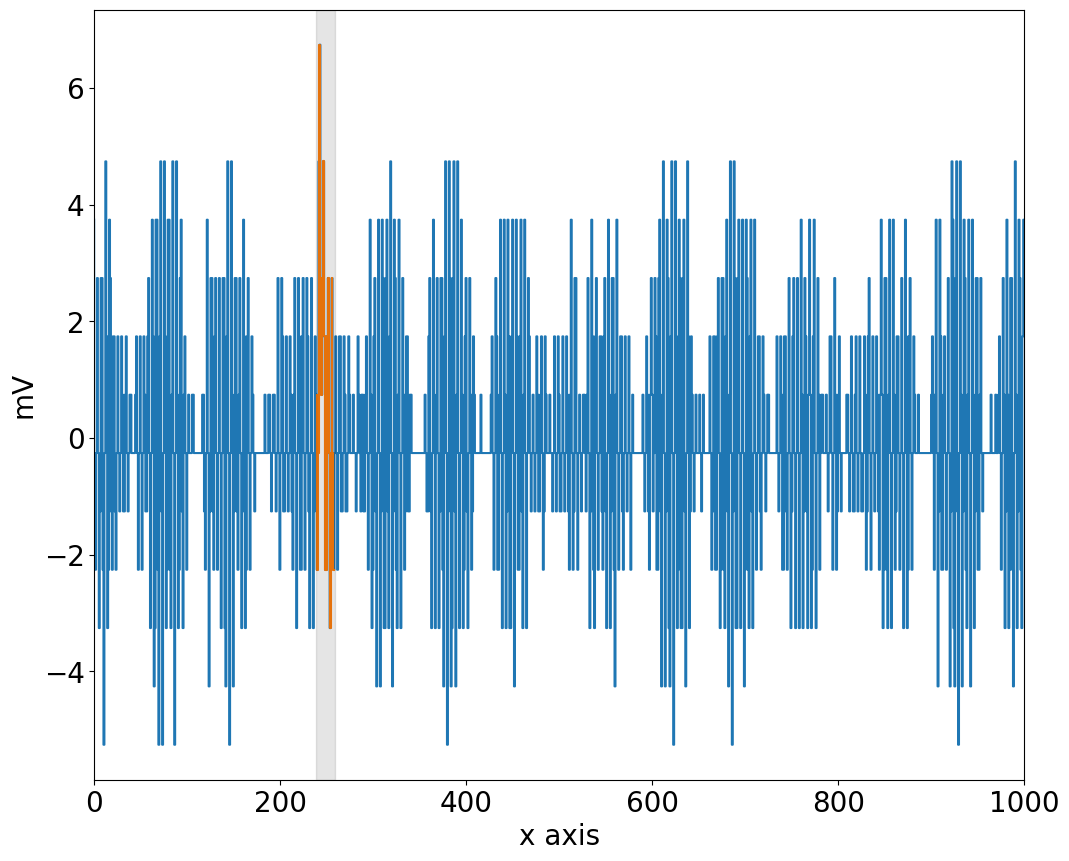

0 42


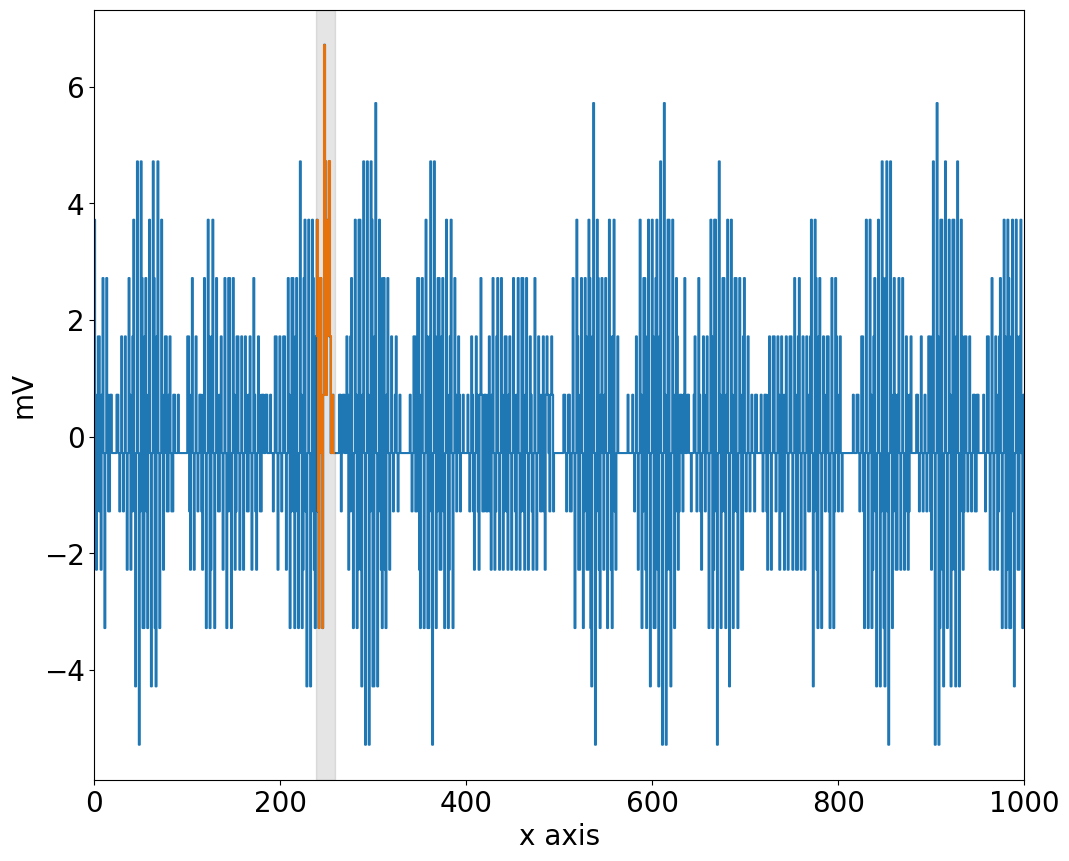

0 43


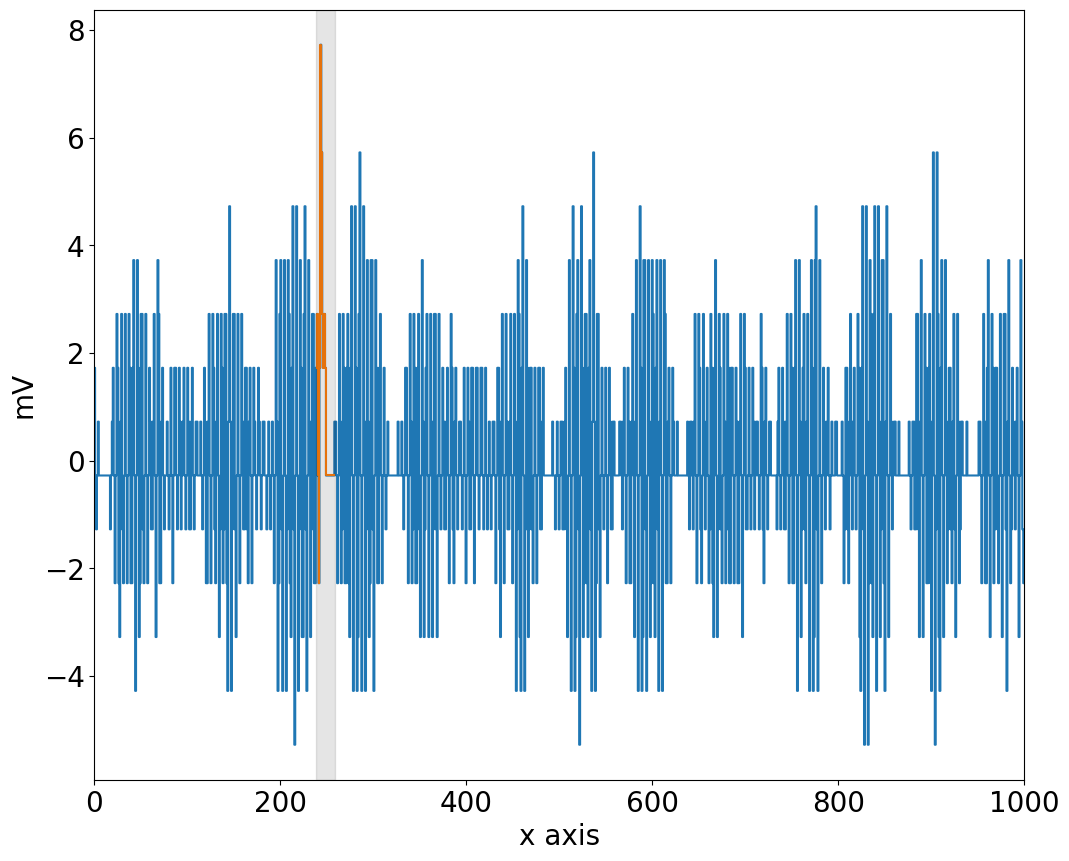

0 44


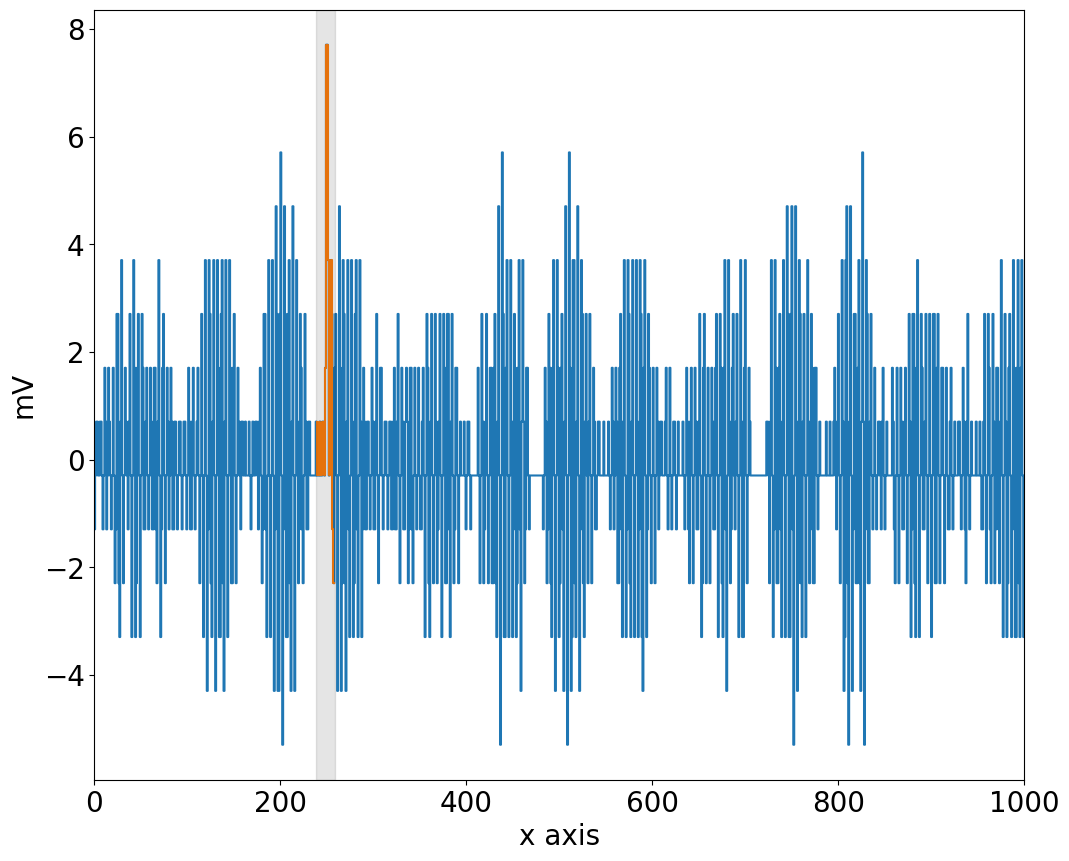

0 45


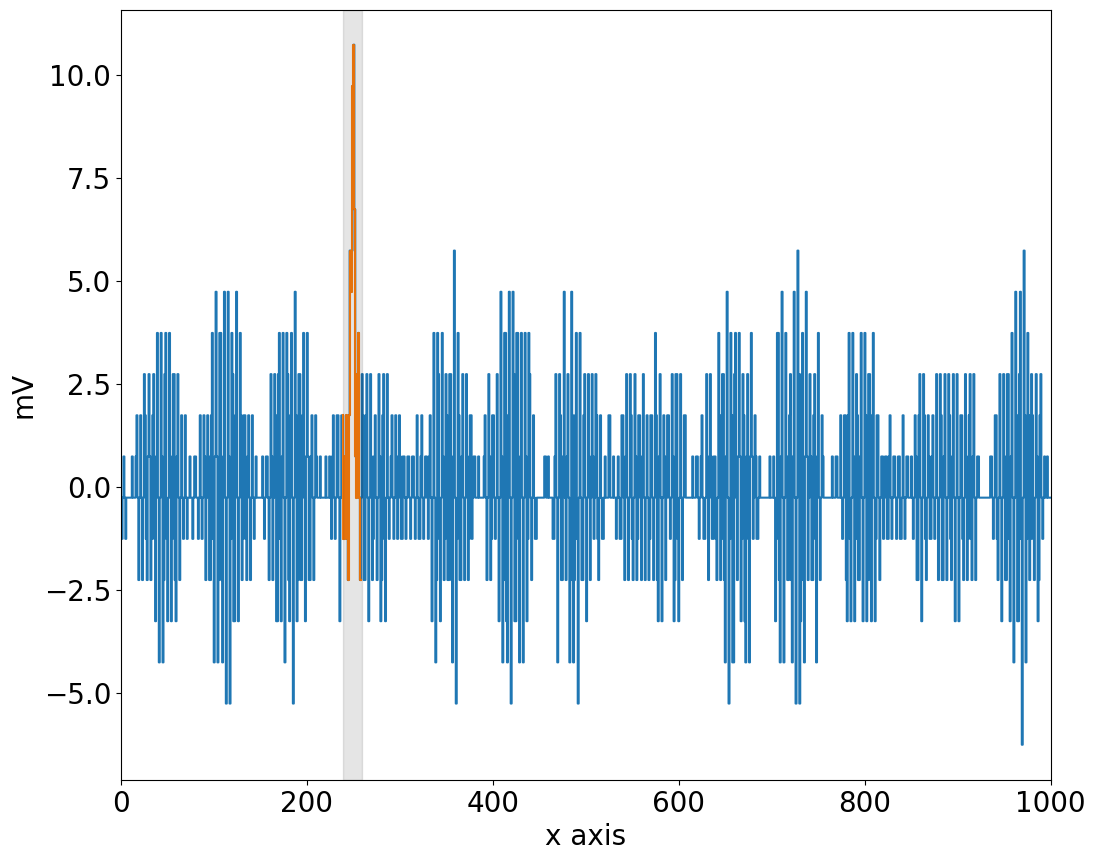

0 46


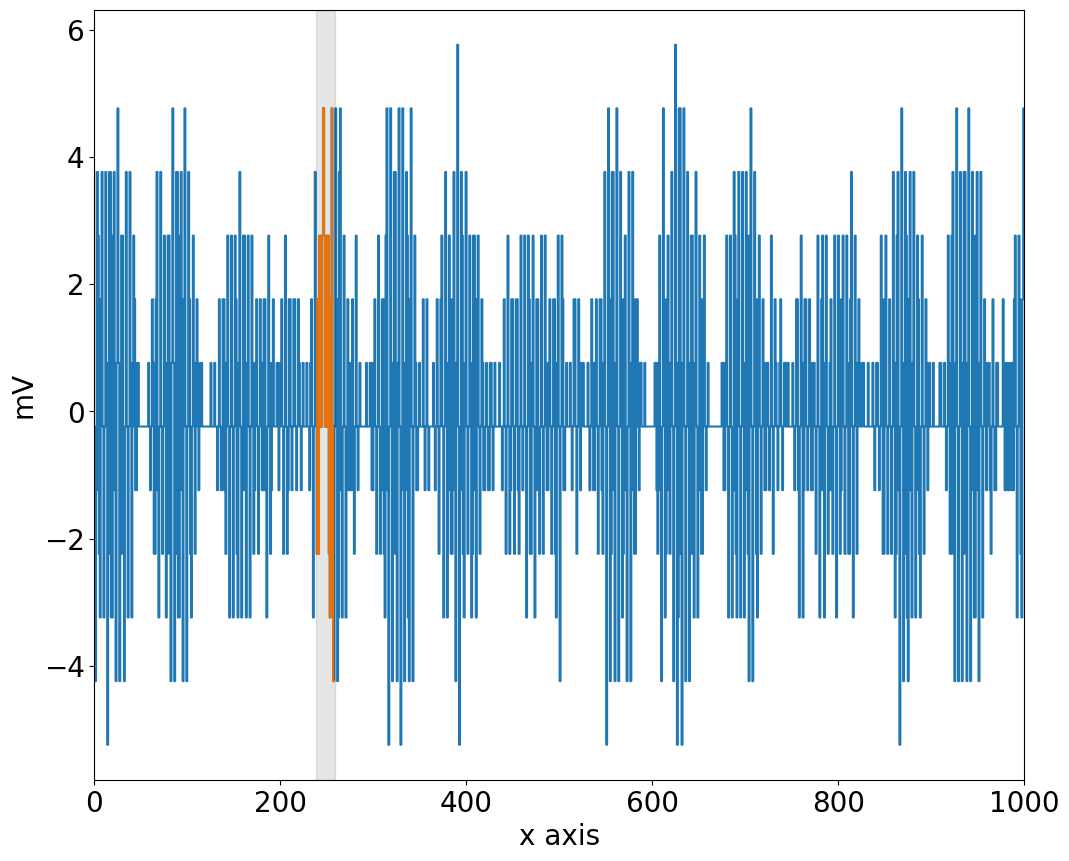

0 47


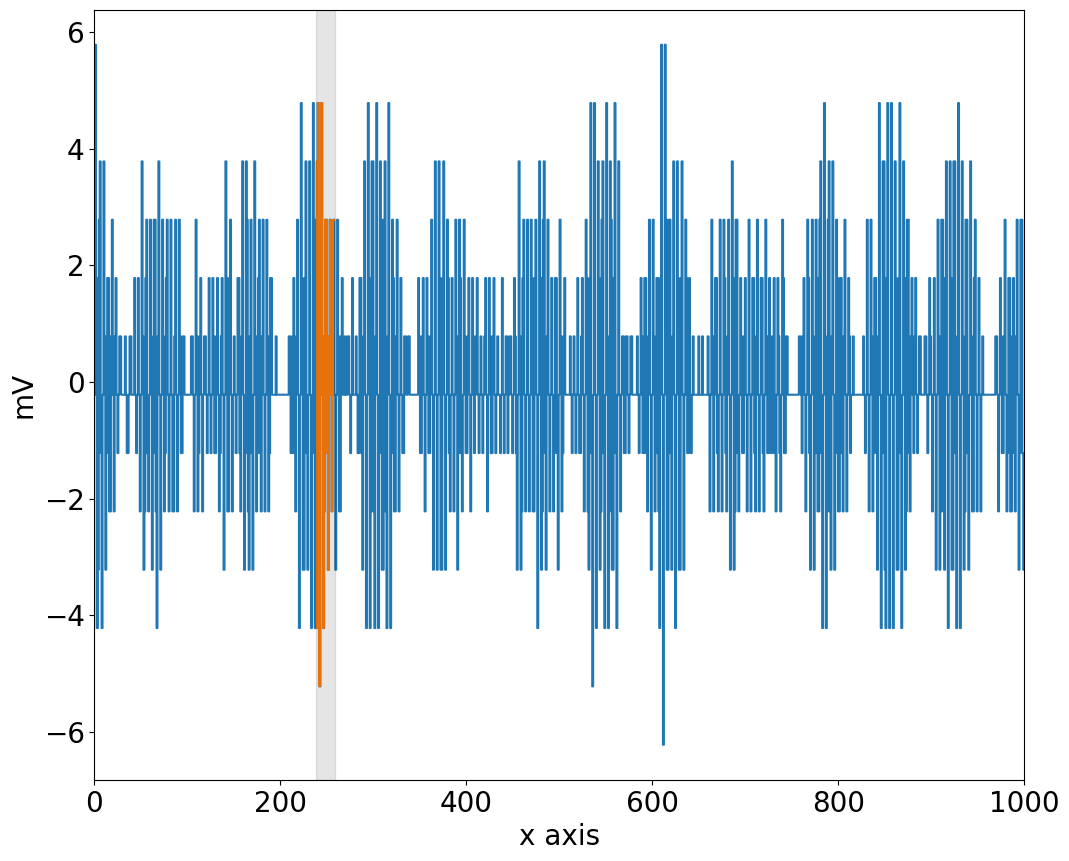

0 48


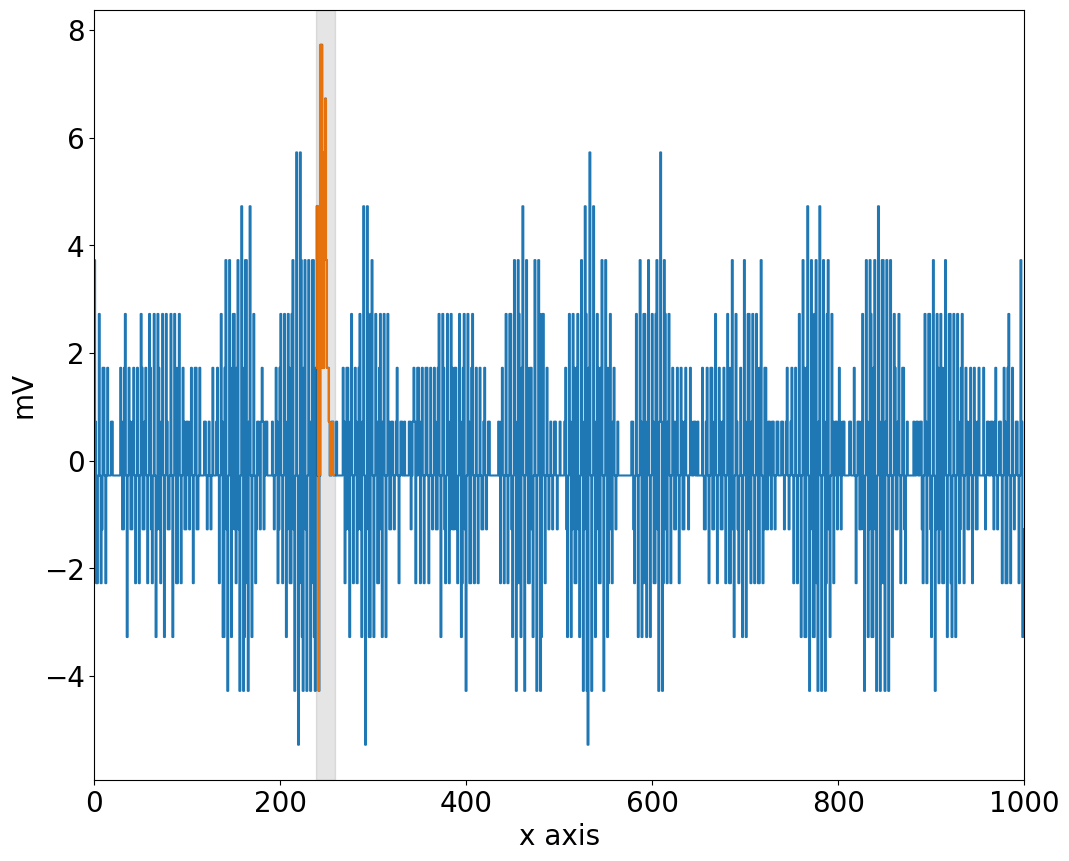

0 49


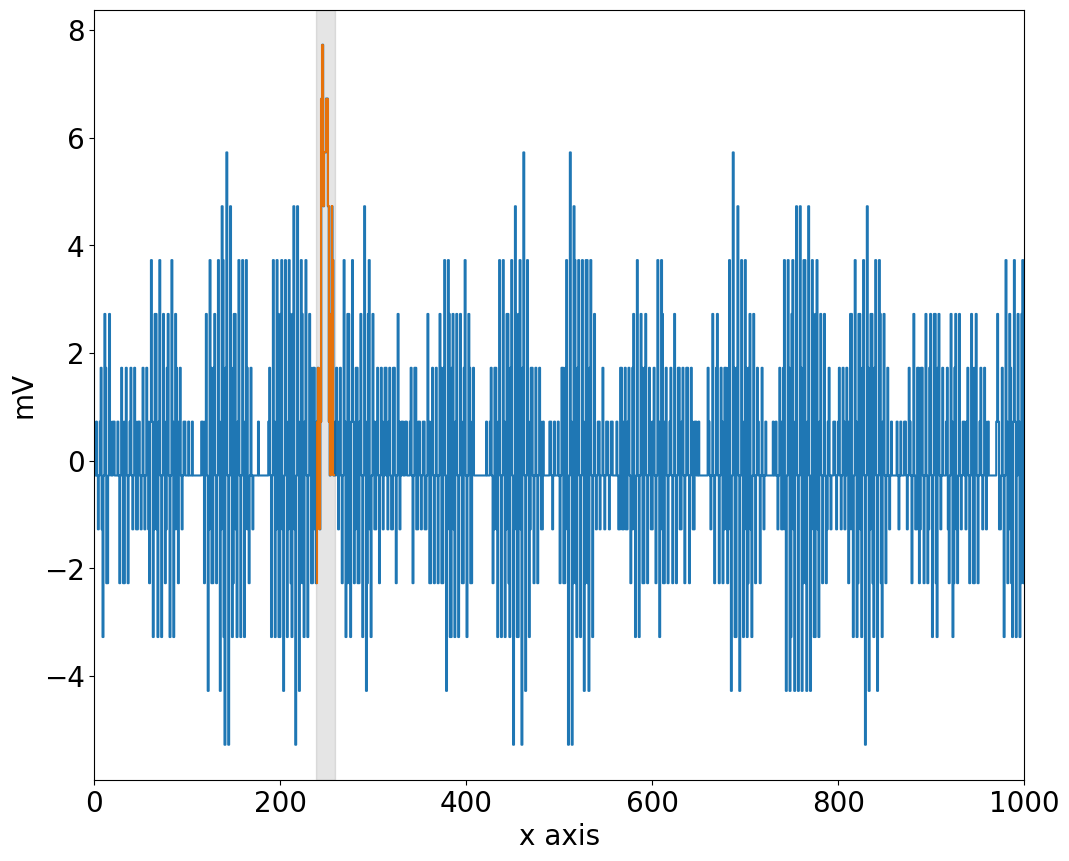

In [16]:
#to see the rWF and to select intervals
#this interval will be used to integrate later
#It is better to determine the integration window with a run with an intensive voltage to see well the position of the peak

inf = 239 #integration window
sup = 259 #integration window

x_inf = 0 # x scale of the plot
x_sup = 1000 # x scale of the plot

delta_pre = 100 # time before the integration window for baseline sub selection
delta_post = 0

nbr_fpr = 1  
nbr_wf = 1000

pmt = 0
run = 1073


for i in range(0, nbr_fpr): 
    wf_file = '/Users/ldonneger/Desktop/PhD_Thesis2/GapData/R'+str(run)+'/raw/Run_'+str(run)+'_file_'+str(i)+'_raw.h5'
    
    with tb.open_file(wf_file, 'r') as h5in:
        
        wvfs       =  h5in.root.RD.pmtrwf[:, pmt, :] # Gets all pmt waveforms for 1 PMT
        pmt_rwf    = -wvfs.sum(axis=0)/ (nbr_wf) # We divide the sum of the wf to get the average
        t = np.linspace(0, len(pmt_rwf), len(pmt_rwf))
       
        mask_pre = (t >= (inf - delta_pre)) #definition of a mask for baseline sub 
        mask = (t >= inf) & (t <= sup) # definition of a mask for intergation window
       
        bl_pre = pmt_rwf[~mask_pre]
       
        w_mean = [np.mean(bl_pre)]
        wf_baseS = pmt_rwf - np.mean(w_mean)

          
        plt.plot(t, wf_baseS, drawstyle='steps', lw=1.5, zorder=0)
        #plt.plot(t,  pmt_rwf, drawstyle='steps', lw=1.5, zorder=0)
        plt.axvspan(inf,sup, alpha=0.1, color='k')
        plt.axvspan(np.min(t[~mask_pre]),np.max(t[~mask_pre]), alpha=0.1, color='b')
        #plt.axvspan(np.min(t[~mask_post]),np.max(t[~mask_post]), alpha=0.1, color='b')
        plt.xlim(x_inf,x_sup)
        plt.title("Average WF of 1000 events for PMT"+str(pmt))
        plt.xlabel('x axis')
        plt.ylabel('mV')
        #plt.yscale('log')
        plt.show()
        
        #plot in log view and with a zoom on the integration window to have a more precise selection
        plt.plot(t[mask], wf_baseS[mask] , drawstyle='steps', lw=1.5, zorder=0)
        plt.axvspan(inf,sup, alpha=0.1, color='k')
        #plt.xlim(x_inf,x_sup)
        plt.title("Average WF of 1000 events for PMT"+str(pmt))
        plt.xlabel('x axis')
        plt.ylabel('mV')
        plt.yscale('log')
        plt.show()
        
        
        for j in range(0,50): 
                wvfs       =  h5in.root.RD.pmtrwf[:, 0, :] # Gets all pmt waveforms for 1 PMT
                pmt_rwf = -wvfs[j]
                #print(np.max(pmt_rwf[mask]), np.min(pmt_rwf[mask]))
                mask_pre = (t >= (inf - delta_pre))
                mask_post = (t <= sup)
                mask = (t >= inf) & (t <= sup) 
                bl_pre = pmt_rwf[~mask_pre]
                bl_post = pmt_rwf[~mask_post]
                w_mean = [np.mean(bl_pre), np.mean(bl_post)]
                wf_baseS = pmt_rwf - np.mean(w_mean)
                
                print(i, j)
                #print(np.max(pmt_rwf[mask]), np.min(pmt_rwf[mask]))
                plt.plot(t, wf_baseS, drawstyle='steps', lw=1.5, zorder=0)
                plt.plot(t[mask], wf_baseS[mask], drawstyle='steps', lw=1.5, zorder=0)
                plt.axvspan(inf,sup, alpha=0.1, color='k')
                plt.xlim(x_inf,x_sup)
                #plt.ylim(0.001, 1000000)
                plt.xlabel('x axis')
                #plt.xlim(10.2,15)
                plt.ylabel('mV')
                #plt.yscale('log')
                plt.show()
                



In [18]:
#to find the baseline and to store integral in a precise interval for calibration (WORK WELL!!!)

nbr_wf = 1000 #should always be 1000
nbr_fpr = 7 #number of files per runs


run_nb = [1073, 1074, 1075, 1076, 1077, 1078, 1079, 1080, 1081, 1082, 1083, 1084, 1085, 1086, 1087, 1088, 1089, 1090, 1091, 1092, 1093, 1094, 1095, 1096, 1097, 1098]

pmts = [0,1,2,3,4,5,6]

for run in run_nb:
    for pmt in pmts:
        integral_store = []
        print(f'Run is : {run}\n number of files is : {nbr_fpr}\n number of WF per file is : {nbr_wf}\n Integration interval is : [{inf}, {sup}]\n delta pre is : {delta_pre}\n PMT seen is : PMT{pmt}\n delta post is : {delta_post}')

        for i in range(0, nbr_fpr):
            wf_file = '/Users/ldonneger/Desktop/PhD_Thesis2/GapData/R'+str(run)+'/raw/Run_'+str(run)+'_file_'+str(i)+'_raw.h5'

            with tb.open_file(wf_file, 'r') as h5in:
                print(f'File number : {i}')
                wvfs       =  h5in.root.RD.pmtrwf[:, pmt, :] # Gets all pmt waveforms for 1 PMT
                pmt_rwf = -wvfs[0]
                t = np.linspace(0, len(pmt_rwf), len(pmt_rwf))
                dt = t[1] - t[0]

                #mask for baseline interval
                #mask_pre = (t >= inf)
                mask_pre = (t >= (inf - delta_pre))
                #mask_post = (t <= sup)
                #mask_post = (t <= sup + delta_post)
                #msk for integration interval
                mask = (t >= inf) & (t <= sup)
                for j in range(0,nbr_wf):

                    pmt_rwf = -wvfs[j] #* mV_to_AP #WF of one event, converted from mV to AP

                    #print(f'WF number : {j}')

                    #t = np.linspace(0, len(pmt_rwf)*8/1000, len(pmt_rwf))

                    #baseline sub
                    bl_pre = pmt_rwf[~mask_pre]
                    #bl_post = pmt_rwf[~mask_post]
                    #w_mean = [np.mean(bl_pre), np.mean(bl_post)]
                    w_mean = [np.mean(bl_pre)]
                    wf_baseS = pmt_rwf - np.mean(w_mean)

                    #integral of the WF with baseline sub between the interval
                    integral = np.sum(wf_baseS[mask])

                    #if (np.min(wf_baseS[mask]) >= -1.5):
                    integral_store.append(integral)
                print(f'Number of int saved : {len(integral_store)}')

        data_file = "/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/"+str(date_folder)+"/R"+str(run)+"_PMT"+str(pmt)+"_"+str(inf)+"_"+str(sup)+".txt"
        np.savetxt(data_file, integral_store, fmt="%.8f")


Run is : 1073
 number of files is : 7
 number of WF per file is : 1000
 Integration interval is : [239, 259]
 delta pre is : 100
 PMT seen is : PMT0
 delta post is : 0
File number : 0
Number of int saved : 1000
File number : 1
Number of int saved : 2000
File number : 2
Number of int saved : 3000
File number : 3
Number of int saved : 4000
File number : 4
Number of int saved : 5000
File number : 5
Number of int saved : 6000
File number : 6
Number of int saved : 7000
Run is : 1073
 number of files is : 7
 number of WF per file is : 1000
 Integration interval is : [239, 259]
 delta pre is : 100
 PMT seen is : PMT1
 delta post is : 0
File number : 0
Number of int saved : 1000
File number : 1
Number of int saved : 2000
File number : 2
Number of int saved : 3000
File number : 3
Number of int saved : 4000
File number : 4
Number of int saved : 5000
File number : 5
Number of int saved : 6000
File number : 6
Number of int saved : 7000
Run is : 1073
 number of files is : 7
 number of WF per file i

Number of int saved : 7000
Run is : 1075
 number of files is : 7
 number of WF per file is : 1000
 Integration interval is : [239, 259]
 delta pre is : 100
 PMT seen is : PMT4
 delta post is : 0
File number : 0
Number of int saved : 1000
File number : 1
Number of int saved : 2000
File number : 2
Number of int saved : 3000
File number : 3
Number of int saved : 4000
File number : 4
Number of int saved : 5000
File number : 5
Number of int saved : 6000
File number : 6
Number of int saved : 7000
Run is : 1075
 number of files is : 7
 number of WF per file is : 1000
 Integration interval is : [239, 259]
 delta pre is : 100
 PMT seen is : PMT5
 delta post is : 0
File number : 0
Number of int saved : 1000
File number : 1
Number of int saved : 2000
File number : 2
Number of int saved : 3000
File number : 3
Number of int saved : 4000
File number : 4
Number of int saved : 5000
File number : 5
Number of int saved : 6000
File number : 6
Number of int saved : 7000
Run is : 1075
 number of files is :

Number of int saved : 6000
File number : 6
Number of int saved : 7000
Run is : 1078
 number of files is : 7
 number of WF per file is : 1000
 Integration interval is : [239, 259]
 delta pre is : 100
 PMT seen is : PMT1
 delta post is : 0
File number : 0
Number of int saved : 1000
File number : 1
Number of int saved : 2000
File number : 2
Number of int saved : 3000
File number : 3
Number of int saved : 4000
File number : 4
Number of int saved : 5000
File number : 5
Number of int saved : 6000
File number : 6
Number of int saved : 7000
Run is : 1078
 number of files is : 7
 number of WF per file is : 1000
 Integration interval is : [239, 259]
 delta pre is : 100
 PMT seen is : PMT2
 delta post is : 0
File number : 0
Number of int saved : 1000
File number : 1
Number of int saved : 2000
File number : 2
Number of int saved : 3000
File number : 3
Number of int saved : 4000
File number : 4
Number of int saved : 5000
File number : 5
Number of int saved : 6000
File number : 6
Number of int saved

Number of int saved : 1000
File number : 1
Number of int saved : 2000
File number : 2
Number of int saved : 3000
File number : 3
Number of int saved : 4000
File number : 4
Number of int saved : 5000
File number : 5
Number of int saved : 6000
File number : 6
Number of int saved : 7000
Run is : 1080
 number of files is : 7
 number of WF per file is : 1000
 Integration interval is : [239, 259]
 delta pre is : 100
 PMT seen is : PMT6
 delta post is : 0
File number : 0
Number of int saved : 1000
File number : 1
Number of int saved : 2000
File number : 2
Number of int saved : 3000
File number : 3
Number of int saved : 4000
File number : 4
Number of int saved : 5000
File number : 5
Number of int saved : 6000
File number : 6
Number of int saved : 7000
Run is : 1081
 number of files is : 7
 number of WF per file is : 1000
 Integration interval is : [239, 259]
 delta pre is : 100
 PMT seen is : PMT0
 delta post is : 0
File number : 0
Number of int saved : 1000
File number : 1
Number of int saved

Number of int saved : 1000
File number : 1
Number of int saved : 2000
File number : 2
Number of int saved : 3000
File number : 3
Number of int saved : 4000
File number : 4
Number of int saved : 5000
File number : 5
Number of int saved : 6000
File number : 6
Number of int saved : 7000
Run is : 1083
 number of files is : 7
 number of WF per file is : 1000
 Integration interval is : [239, 259]
 delta pre is : 100
 PMT seen is : PMT3
 delta post is : 0
File number : 0
Number of int saved : 1000
File number : 1
Number of int saved : 2000
File number : 2
Number of int saved : 3000
File number : 3
Number of int saved : 4000
File number : 4
Number of int saved : 5000
File number : 5
Number of int saved : 6000
File number : 6
Number of int saved : 7000
Run is : 1083
 number of files is : 7
 number of WF per file is : 1000
 Integration interval is : [239, 259]
 delta pre is : 100
 PMT seen is : PMT4
 delta post is : 0
File number : 0
Number of int saved : 1000
File number : 1
Number of int saved

...

Number of int saved : 1000
File number : 1
Number of int saved : 2000
File number : 2
Number of int saved : 3000
File number : 3
Number of int saved : 4000
File number : 4
Number of int saved : 5000
File number : 5
Number of int saved : 6000
File number : 6
Number of int saved : 7000
Run is : 1088
 number of files is : 7
 number of WF per file is : 1000
 Integration interval is : [239, 259]
 delta pre is : 100
 PMT seen is : PMT4
 delta post is : 0
File number : 0
Number of int saved : 1000
File number : 1
Number of int saved : 2000
File number : 2
Number of int saved : 3000
File number : 3
Number of int saved : 4000
File number : 4
Number of int saved : 5000
File number : 5
Number of int saved : 6000
File number : 6
Number of int saved : 7000
Run is : 1088
 number of files is : 7
 number of WF per file is : 1000
 Integration interval is : [239, 259]
 delta pre is : 100
 PMT seen is : PMT5
 delta post is : 0
File number : 0
Number of int saved : 1000
File number : 1
Number of int saved

Number of int saved : 7000
Run is : 1091
 number of files is : 7
 number of WF per file is : 1000
 Integration interval is : [239, 259]
 delta pre is : 100
 PMT seen is : PMT0
 delta post is : 0
File number : 0
Number of int saved : 1000
File number : 1
Number of int saved : 2000
File number : 2
Number of int saved : 3000
File number : 3
Number of int saved : 4000
File number : 4
Number of int saved : 5000
File number : 5
Number of int saved : 6000
File number : 6
Number of int saved : 7000
Run is : 1091
 number of files is : 7
 number of WF per file is : 1000
 Integration interval is : [239, 259]
 delta pre is : 100
 PMT seen is : PMT1
 delta post is : 0
File number : 0
Number of int saved : 1000
File number : 1
Number of int saved : 2000
File number : 2
Number of int saved : 3000
File number : 3
Number of int saved : 4000
File number : 4
Number of int saved : 5000
File number : 5
Number of int saved : 6000
File number : 6
Number of int saved : 7000
Run is : 1091
 number of files is :

Number of int saved : 3000
File number : 3
Number of int saved : 4000
File number : 4
Number of int saved : 5000
File number : 5
Number of int saved : 6000
File number : 6
Number of int saved : 7000
Run is : 1093
 number of files is : 7
 number of WF per file is : 1000
 Integration interval is : [239, 259]
 delta pre is : 100
 PMT seen is : PMT4
 delta post is : 0
File number : 0
Number of int saved : 1000
File number : 1
Number of int saved : 2000
File number : 2
Number of int saved : 3000
File number : 3
Number of int saved : 4000
File number : 4
Number of int saved : 5000
File number : 5
Number of int saved : 6000
File number : 6
Number of int saved : 7000
Run is : 1093
 number of files is : 7
 number of WF per file is : 1000
 Integration interval is : [239, 259]
 delta pre is : 100
 PMT seen is : PMT5
 delta post is : 0
File number : 0
Number of int saved : 1000
File number : 1
Number of int saved : 2000
File number : 2
Number of int saved : 3000
File number : 3
Number of int saved

Number of int saved : 1000
File number : 1
Number of int saved : 2000
File number : 2
Number of int saved : 3000
File number : 3
Number of int saved : 4000
File number : 4
Number of int saved : 5000
File number : 5
Number of int saved : 6000
File number : 6
Number of int saved : 7000
Run is : 1096
 number of files is : 7
 number of WF per file is : 1000
 Integration interval is : [239, 259]
 delta pre is : 100
 PMT seen is : PMT3
 delta post is : 0
File number : 0
Number of int saved : 1000
File number : 1
Number of int saved : 2000
File number : 2
Number of int saved : 3000
File number : 3
Number of int saved : 4000
File number : 4
Number of int saved : 5000
File number : 5
Number of int saved : 6000
File number : 6
Number of int saved : 7000
Run is : 1096
 number of files is : 7
 number of WF per file is : 1000
 Integration interval is : [239, 259]
 delta pre is : 100
 PMT seen is : PMT4
 delta post is : 0
File number : 0
Number of int saved : 1000
File number : 1
Number of int saved

Number of int saved : 1000
File number : 1
Number of int saved : 2000
File number : 2
Number of int saved : 3000
File number : 3
Number of int saved : 4000
File number : 4
Number of int saved : 5000
File number : 5
Number of int saved : 6000
File number : 6
Number of int saved : 7000


1098 6 239 259
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1073_PMT0_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1076_PMT0_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1079_PMT0_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1083_PMT0_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1088_PMT0_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1093_PMT0_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1098_PMT0_239_259.txt


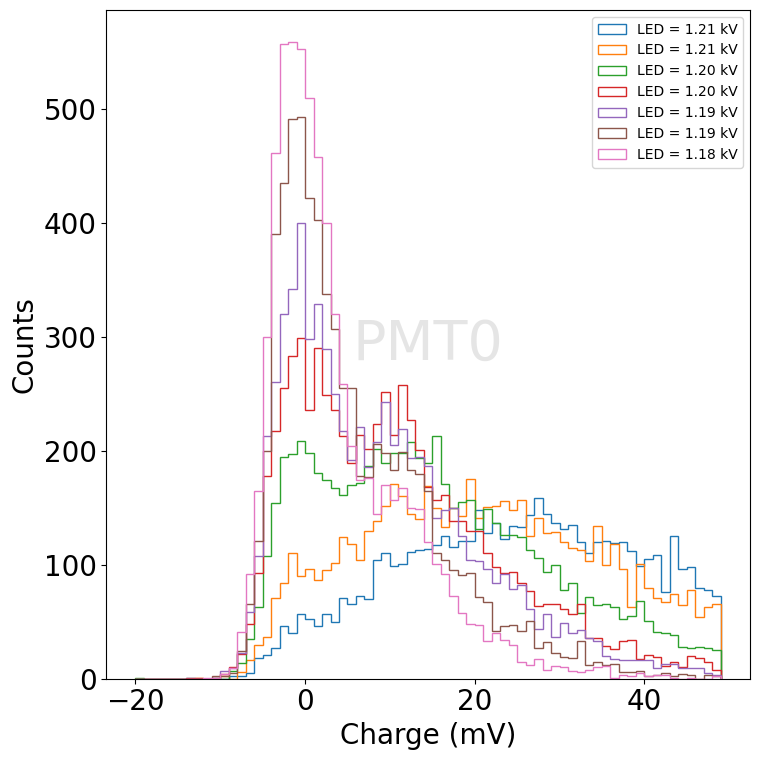

/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1073-R1098_PMT0_239_259.png
1073 1098
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1073_PMT1_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1076_PMT1_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1079_PMT1_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1083_PMT1_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1088_PMT1_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1093_PMT1_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1098_PMT1_239_259.txt


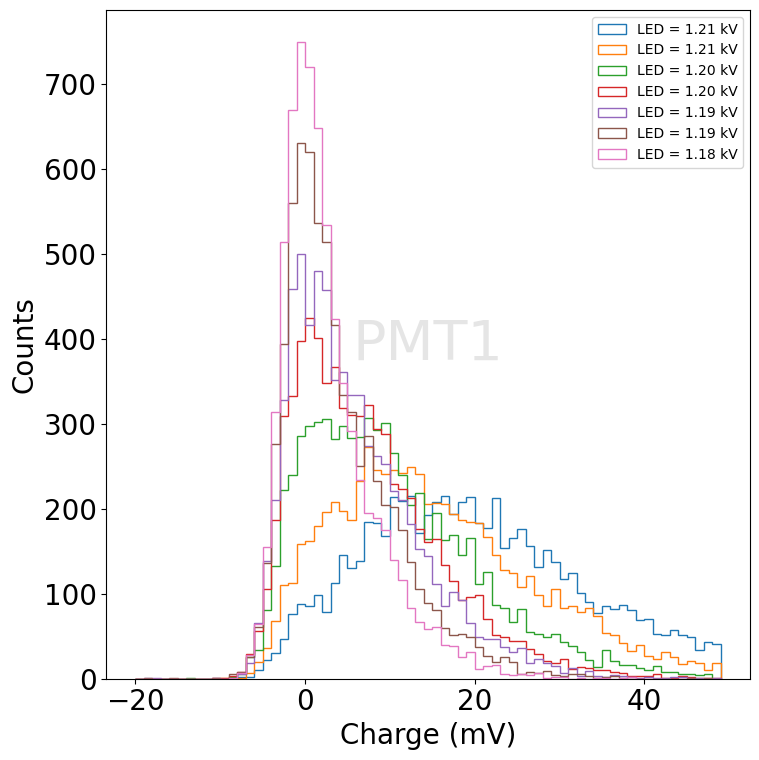

/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1073-R1098_PMT1_239_259.png
1073 1098
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1073_PMT2_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1076_PMT2_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1079_PMT2_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1083_PMT2_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1088_PMT2_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1093_PMT2_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1098_PMT2_239_259.txt


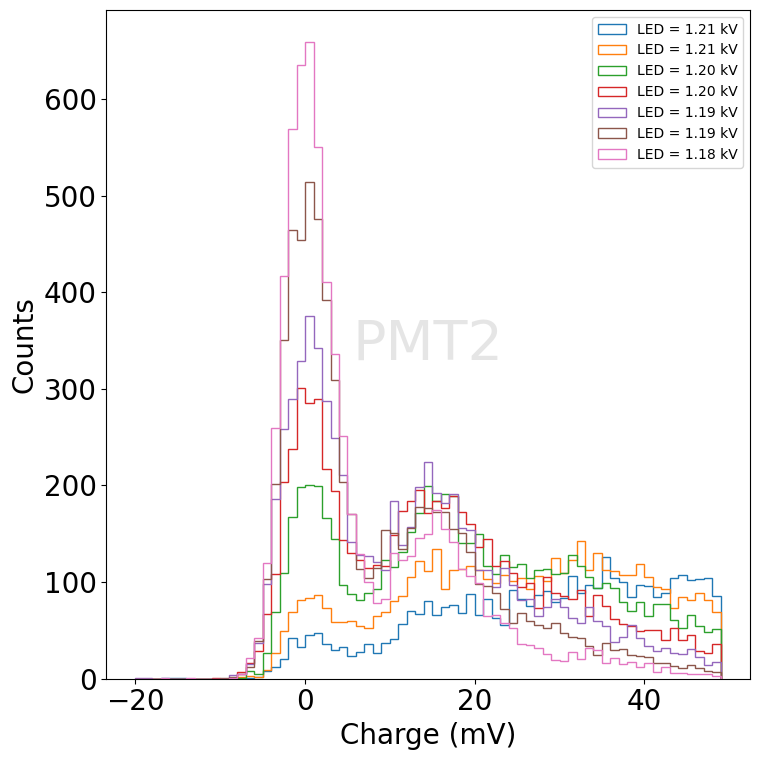

/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1073-R1098_PMT2_239_259.png
1073 1098
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1073_PMT3_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1076_PMT3_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1079_PMT3_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1083_PMT3_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1088_PMT3_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1093_PMT3_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1098_PMT3_239_259.txt


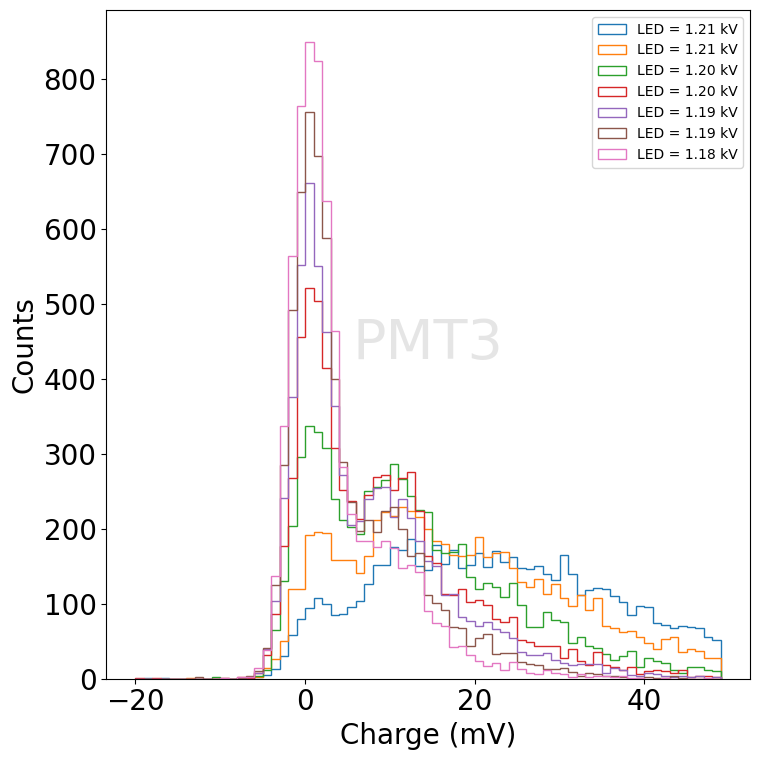

/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1073-R1098_PMT3_239_259.png
1073 1098
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1073_PMT4_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1076_PMT4_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1079_PMT4_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1083_PMT4_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1088_PMT4_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1093_PMT4_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1098_PMT4_239_259.txt


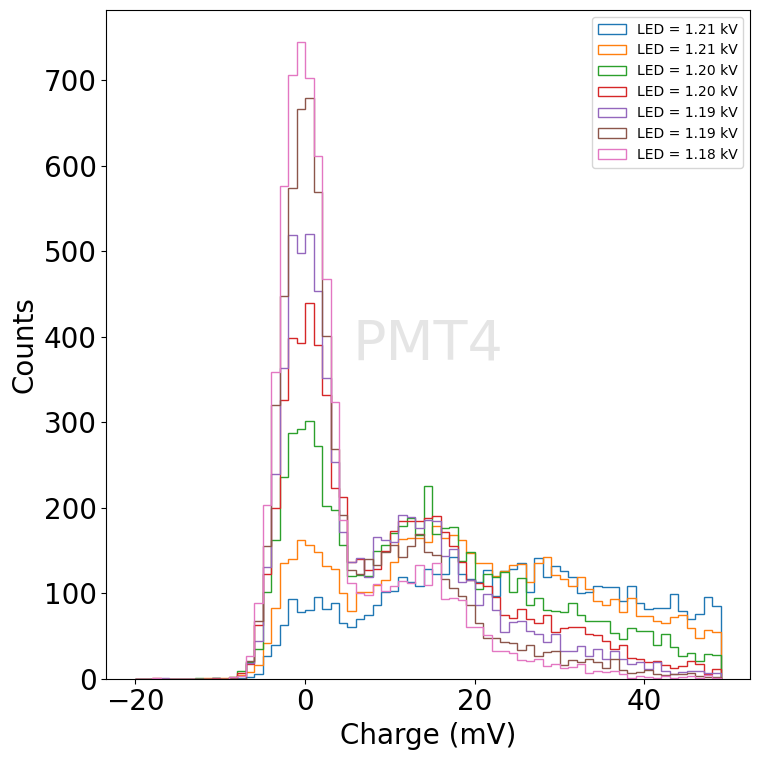

/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1073-R1098_PMT4_239_259.png
1073 1098
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1073_PMT5_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1076_PMT5_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1079_PMT5_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1083_PMT5_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1088_PMT5_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1093_PMT5_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1098_PMT5_239_259.txt


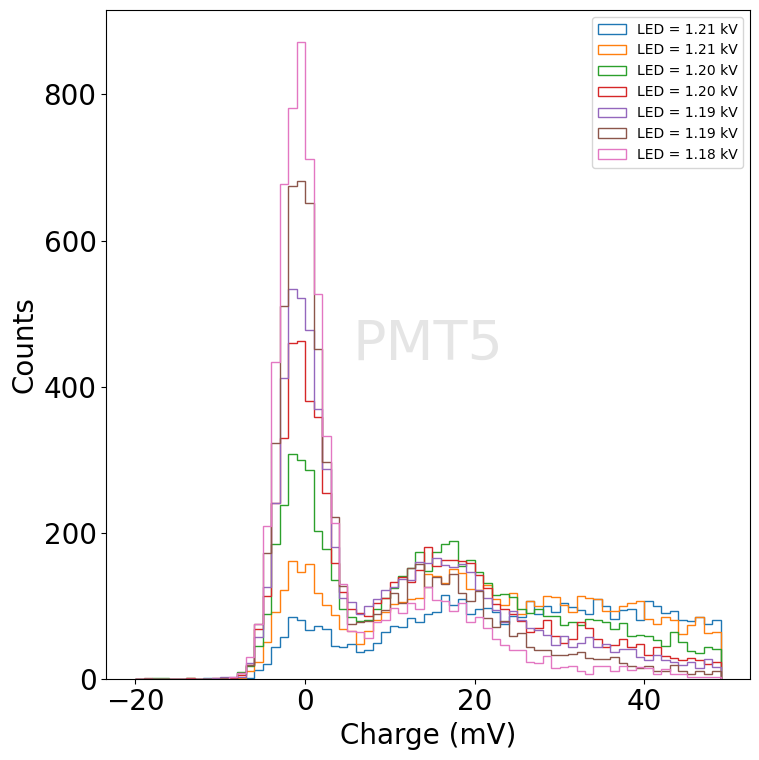

/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1073-R1098_PMT5_239_259.png
1073 1098
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1073_PMT6_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1076_PMT6_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1079_PMT6_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1083_PMT6_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1088_PMT6_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1093_PMT6_239_259.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1098_PMT6_239_259.txt


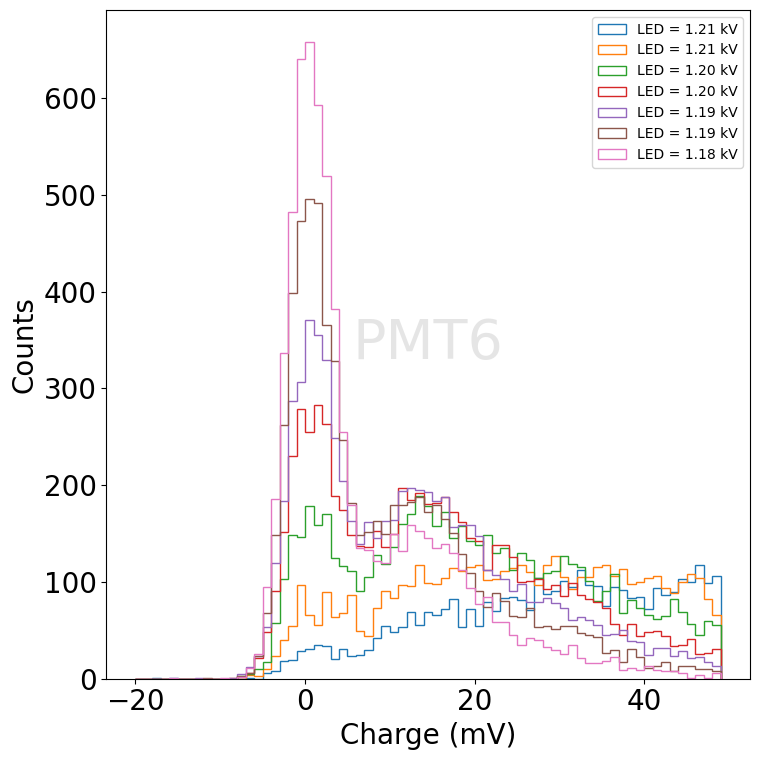

/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1073-R1098_PMT6_239_259.png
1073 1098


In [24]:
#plot for calibration

data_path = "/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/"+str(date_folder)+"/"

print(run, pmt, inf, sup)
bins_ = np.arange(-20, 50, 1)
pmts = [0,1,2,3,4,5,6]

run_nb = [ 1073, 1076, 1079, 1083, 1088,  1093, 1098]
LED_V = [ 1.211, 1.205, 1.199, 1.195, 1.190,  1.185,  1.180]

#run_nb = [1073, 1074, 1075, 1076, 1077, 1078, 1079, 1080, 1081, 1082, 1083, 1084, 1085, 1086, 1087, 1088, 1089, 1090, 1091, 1092, 1093, 1094, 1095, 1096, 1097, 1098]
#LED_V = [1.211, 1.209, 1.207, 1.205, 1.203, 1.201, 1.199, 1.198, 1.197, 1.196, 1.195, 1.194, 1.193, 1.192, 1.191, 1.190, 1.189,  1.188, 1.187,  1.186, 1.185, 1.184, 1.183, 1.182, 1.181, 1.180]



bin_centers = (bins_[1:] + bins_[:-1])/2
for j in range(len(pmts)):
    plt.figure(figsize=(8, 8))
    for i in range(len(run_nb)):
        
        file = "R"+str(run_nb[i])+"_PMT"+str(pmts[j])+"_"+str(inf)+"_"+str(sup)
        
        data_file = data_path + file + '.txt'
        print(data_file)
        integral_charge = np.loadtxt(data_file) #* mV_to_Phot
        #print(len(integral_charge))
        integral_sum = np.sum(integral_charge) #* mV_to_AP
        #print(nbr_fpr)
        #print(nbr_wf)
        #print(integral_sum)
        #print(f'The ratio of nb of AP over the nb of events is : {integral_sum}')
        #print(integral_charge)
        
        plt.hist(integral_charge, bins=bins_, density=False, histtype = 'step', label=f'LED = {LED_V[i]:.2f} kV')
        plt.xlabel("Charge (mV)")
        
        
        #plt.xlabel("Number of AP")
        #plt.xlabel("Number of Photons")
        plt.ylabel("Counts")
        plt.legend(fontsize=10)
        plt.tight_layout()
        #plt.yscale('log')
    #plt.ylim(0, 8000)
    xmin, xmax = plt.xlim()
    ymin, ymax = plt.ylim()
    plt.text((xmax+xmin)/2, (ymax+ymin)/2, 'PMT'+str(pmts[j]), fontsize=40, color='gray',
            alpha=0.2, ha='center', va='center', zorder=0)  
    plt.savefig(data_path + 'R'+str(np.min(run_nb))+'-R'+str(np.max(run_nb))+'_PMT'+str(pmts[j])+'_'+str(inf)+'_'+str(sup)+'.png')
    plt.show()
    
    print(data_path + 'R'+str(np.min(run_nb))+'-R'+str(np.max(run_nb))+'_PMT'+str(pmts[j])+'_'+str(inf)+'_'+str(sup)+'.png')
    print(np.min(run_nb), np.max(run_nb))
    
pmt_changed = 50   


1.18
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1098_PMT6_239_259.txt
val max is : 7.069392600002857
parameters gauss 1 are : amp1 : 637.2680962371513 +/- 6.205996438179332 
 mu1 : 0.48219179457898986 +/- 0.0216914145689166 
 sigma1 : 2.5518201217552448 +/- 0.02599017096091533 

parameters gauss 2 are : amp2 : 144.1759958759562 +/- 16.131688593830525 
 mu2 : 12.542354630365482 +/- 0.5062248922190881 
 sigma2 : 6.513428579675259 +/- 0.5490406617925171 
parameters gauss 3 are : amp3 : 24.235691485161116 +/- 7.851116919402299 
 mu3 : 27.945947136609725 +/- 7.279553960736412 
 sigma3 : 9.523498493116684 +/- 3.915217608490357 


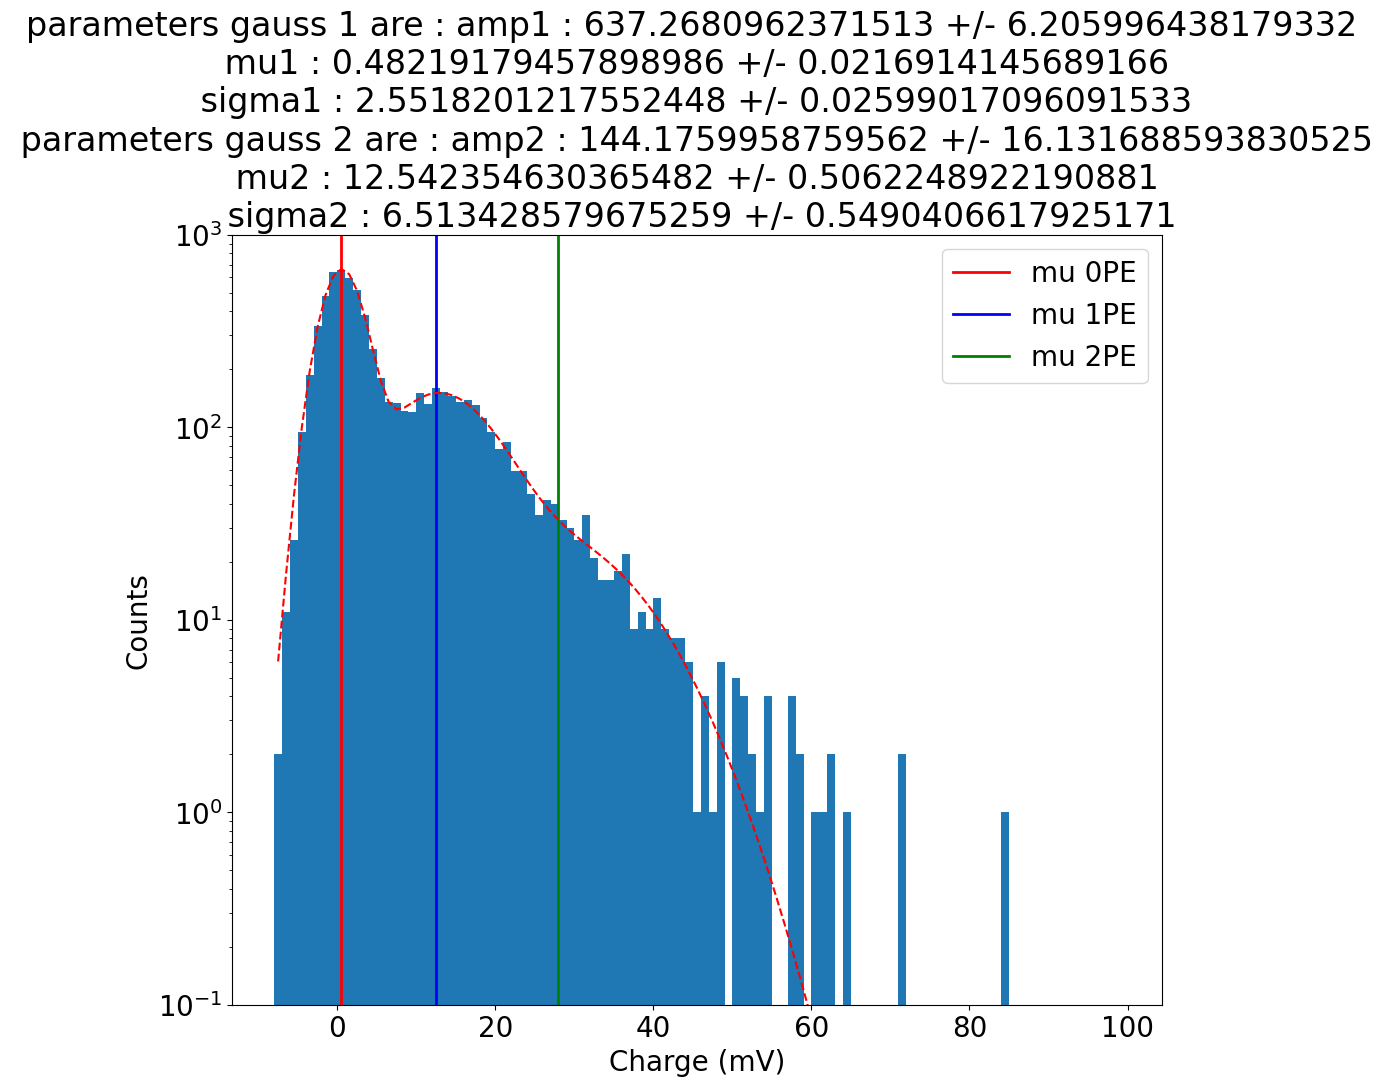

In [157]:
# to do gaussian fittings

data_path = "/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/"+str(date_folder)+"/"

pmts = [0,1,2,3,4,5,6]
#LED_V = [ 1.30, 1.24, 1.23, 1.22, 1.21, 1.20, 1.19]
#run_nb = [ 2453, 2454, 2455, 2456, 2457, 2458, 2459]
#LED_V = [1.32, 1.30, 1.28, 1.26, 1.24, 1.22, 1.20, 1.18]
#run_nb = [2436, 2437, 2438, 2438, 2440, 2441, 2442, 2443]

i = 6
j = 6 #pmt nb
print(f'{LED_V[i]}')
data_file = data_path + "R"+str(run_nb[i])+"_PMT"+str(pmts[j])+"_"+str(inf)+"_"+str(sup)+".txt"
print(data_file)
integral_charge = np.loadtxt(data_file)
#pmt = 0

bins_ = np.arange(-8, 100, 1)
bin_centers = (bins_[1:] + bins_[:-1]) / 2

def gauss(x, amp, mu, sigma):
    return amp * np.exp(-(x - mu) ** 2 / (2 * sigma ** 2))

def two_gauss(x, amp1, mu1, sigma1, amp2, mu2, sigma2):
    return (gauss(x, amp1, mu1, sigma1) + 
            gauss(x, amp2, mu2, sigma2))

def three_gauss(x, amp1, mu1, sigma1, amp2, mu2, sigma2, amp3, mu3, sigma3):
    return (gauss(x, amp1, mu1, sigma1) + 
            gauss(x, amp2, mu2, sigma2) +
            gauss(x, amp3, mu3, sigma3))

def four_gauss(x, amp1, mu1, sigma1, amp2, mu2, sigma2, amp3, mu3, sigma3, amp4, mu4, sigma4):
    return (gauss(x, amp1, mu1, sigma1) + 
            gauss(x, amp2, mu2, sigma2) +
            gauss(x, amp3, mu3, sigma3) +
            gauss(x, amp4, mu4, sigma4) )



n, bins, patches = plt.hist(integral_charge, bins=bins_, range=(-5, 60))
print(f'val max is : {np.mean(integral_charge)}')
#plt.axvline(np.mean(integral_charge), color='green', linestyle='-', linewidth=2, label='mean data')
y = n

nb_gauss = 3

if nb_gauss == 1:
    
    #p0 = (200, 0, 5) #2gauss
    p0 = (400, 250, 200)
    popt, pcov = curve_fit(gauss, bin_centers, y, p0=p0)
    y_fit = gauss(bin_centers, *popt)
    err = np.sqrt(np.diag(pcov))
    
    amp1 = popt[0]
    mu1 = popt[1]
    sigma1 = popt[2]
    
    amp1_err = err[0]
    mu1_err = err[1]
    sigma1_err = err[2]
    
    plt.axvline(mu1, color='red', linestyle='-', linewidth=2, label='mu 0PE')
    
    print(f'parameters gauss 1 are : amp1 : {amp1} +/- {amp1_err} \n mu1 : {mu1} +/- {mu1_err} \n sigma1 : {sigma1} +/- {sigma1_err} \n')


if nb_gauss == 2:
    
    p0 = (4000, 0, 5, 2000, 100, 50) #2gauss
    popt, pcov = curve_fit(two_gauss, bin_centers, y, p0=p0)
    y_fit = two_gauss(bin_centers, *popt)
    err = np.sqrt(np.diag(pcov))
    
    amp1 = popt[0]
    mu1 = popt[1]
    sigma1 = popt[2]
    
    plt.axvline(mu1, color='red', linestyle='-', linewidth=2, label='mu 0PE')

    amp1_err = err[0]
    mu1_err = err[1]
    sigma1_err = err[2]
    
    amp2 = popt[3]
    mu2 = popt[4]
    sigma2 = popt[5]
    
    plt.axvline(mu2, color='blue', linestyle='-', linewidth=2, label='mu 1PE')
    
    amp2_err = err[3]
    mu2_err = err[4]
    sigma2_err = err[5]
    
    print(f'parameters gauss 1 are : amp1 : {amp1} +/- {amp1_err} \n mu1 : {mu1} +/- {mu1_err} \n sigma1 : {sigma1} +/- {sigma1_err} \n')
    print(f'parameters gauss 2 are : amp2 : {amp2} +/- {amp2_err} \n mu2 : {mu2} +/- {mu2_err} \n sigma2 : {sigma2} +/- {sigma2_err} ')

    
if nb_gauss == 3:
    
    p0 = (10000, 0, 5, 1000, 16, 5, 100, 50, 5) #3gauss
    popt, pcov = curve_fit(three_gauss, bin_centers, y, p0=p0)
    y_fit = three_gauss(bin_centers, *popt)
    err = np.sqrt(np.diag(pcov))
    
    amp1 = popt[0]
    mu1 = popt[1]
    sigma1 = popt[2]
    
    plt.axvline(mu1, color='red', linestyle='-', linewidth=2, label='mu 0PE')
    
    amp1_err = err[0]
    mu1_err = err[1]
    sigma1_err = err[2]
    
    amp2 = popt[3]
    mu2 = popt[4]
    sigma2 = popt[5]
    
    plt.axvline(mu2, color='blue', linestyle='-', linewidth=2, label='mu 1PE')

    
    amp2_err = err[3]
    mu2_err = err[4]
    sigma2_err = err[5]
    
    amp3 = popt[6]
    mu3 = popt[7]
    sigma3 = popt[8]
    
    plt.axvline(mu3, color='green', linestyle='-', linewidth=2, label='mu 2PE')

    
    amp3_err = err[6]
    mu3_err = err[7]
    sigma3_err = err[8]
    
    print(f'parameters gauss 1 are : amp1 : {amp1} +/- {amp1_err} \n mu1 : {mu1} +/- {mu1_err} \n sigma1 : {sigma1} +/- {sigma1_err} \n')
    print(f'parameters gauss 2 are : amp2 : {amp2} +/- {amp2_err} \n mu2 : {mu2} +/- {mu2_err} \n sigma2 : {sigma2} +/- {sigma2_err} ')
    print(f'parameters gauss 3 are : amp3 : {amp3} +/- {amp3_err} \n mu3 : {mu3} +/- {mu3_err} \n sigma3 : {sigma3} +/- {sigma3_err} ')
                     
if nb_gauss == 4:
                           
    p0 = (5000, 0, 5, 1000, 16, 5, 500, 27, 5, 200, 45, 5) #4gauss 
    popt, pcov = curve_fit(four_gauss, bin_centers, y, p0=p0)
    y_fit = four_gauss(bin_centers, *popt)
    err = np.sqrt(np.diag(pcov))
    
    err = np.sqrt(np.diag(pcov))
    
    amp1 = popt[0]
    mu1 = popt[1]
    sigma1 = popt[2]
    
    plt.axvline(mu1, color='red', linestyle='-', linewidth=2, label='mu 1PE')
    
    amp1_err = err[0]
    mu1_err = err[1]
    sigma1_err = err[2]
    
    amp2 = popt[3]
    mu2 = popt[4]
    sigma2 = popt[5]
    
    plt.axvline(mu2, color='red', linestyle='-', linewidth=2, label='mu 2PE')

    
    amp2_err = err[3]
    mu2_err = err[4]
    sigma2_err = err[5]
    
    amp3 = popt[6]
    mu3 = popt[7]
    sigma3 = popt[8]
    
    plt.axvline(mu3, color='red', linestyle='-', linewidth=2, label='mu 3PE')

    
    amp3_err = err[6]
    mu3_err = err[7]
    sigma3_err = err[8]
    
    amp4 = popt[9]
    mu4 = popt[10]
    sigma4 = popt[11]
    
    plt.axvline(mu4, color='red', linestyle='-', linewidth=2, label='mu 4PE')

    
    amp4_err = err[9]
    mu4_err = err[10]
    sigma4_err = err[11]
    
    print(f'parameters gauss 1 are : amp1 : {amp1} +/- {amp1_err} \n mu1 : {mu1} +/- {mu1_err} \n sigma1 : {sigma1} +/- {sigma1_err} \n')
    print(f'parameters gauss 2 are : amp2 : {amp2} +/- {amp2_err} \n mu2 : {mu2} +/- {mu2_err} \n sigma2 : {sigma2} +/- {sigma2_err} ')
    print(f'parameters gauss 3 are : amp3 : {amp3} +/- {amp3_err} \n mu3 : {mu3} +/- {mu3_err} \n sigma3 : {sigma3} +/- {sigma3_err} ')
    print(f'parameters gauss 4 are : amp3 : {amp4} +/- {amp4_err} \n mu4 : {mu4} +/- {mu4_err} \n sigma4 : {sigma4} +/- {sigma4_err} ')
                 

plt.plot(bin_centers, y_fit, color='r', linestyle='dashed')

plt.xlabel('Charge (mV)')
#plt.xlabel('Nb of AP')

plt.ylabel('Counts')
plt.yscale('log')
plt.ylim(0.1, 1e3)
plt.title('parameters gauss 1 are : amp1 : '+str(amp1)+' +/- '+str(amp1_err)+' \n mu1 : '+str(mu1)+' +/- '+str(mu1_err)+' \n sigma1 : '+str(sigma1)+' +/- '+str(sigma1_err)+' \n parameters gauss 2 are : amp2 : '+str(amp2)+' +/- '+str(amp2_err)+' \n mu2 : '+str(mu2)+' +/- '+str(mu2_err)+' \n sigma2 : '+str(sigma2)+' +/- '+str(sigma2_err))
#plt.figtext(0.5, -0.05, 'parameters gauss 1 are : amp1 : '+str(amp1)+' +/- '+str(amp1_err)+' \n mu1 : {mu1} +/- {mu1_err} \n sigma1 : {sigma1} +/- {sigma1_err} \n', ha='center', fontsize=12)
plt.legend()
plt.savefig(data_path + 'Fit_R'+str(run_nb[i])+'_PMT'+str(pmts[j])+'_'+str(inf)+'_'+str(sup)+'.png', bbox_inches='tight')
plt.show()







In [158]:
### If the pmt analysed is changed, the arrays of values are empty, if not, we add values to the array
# Execute only if the fit is good
if (pmt_changed != j):
    
    amp_p0 = []
    err_amp_p0 = []

    amp_p1 = []
    err_amp_p1 = []

    mu_p0 = []
    err_mu_p0 = []

    mu_p1 = []
    err_mu_p1 = []

    sigma_p0 = []
    err_sigma_p0 = []

    sigma_p1 = []
    err_sigma_p1 = []

    mu_plot = []
    mu_err_plot = []

    LED_plot = []

else:
    
    amp_p0.append(amp1)
    err_amp_p0.append(amp1_err)

    amp_p1.append(amp2)
    err_amp_p1.append(amp2_err)

    mu_p0.append(mu1)
    err_mu_p0.append(mu1_err)

    mu_p1.append(mu2)
    err_mu_p1.append(mu2_err)

    sigma_p0.append(sigma1)
    err_sigma_p0.append(sigma1_err)

    sigma_p1.append(sigma2)
    err_sigma_p1.append(sigma2_err)

    mu_plot = []
    mu_err_plot = []

    LED_plot.append(LED_V[i])
    
pmt_changed = j
print("last i values tested is : ", i)
print("nb of fitting saved : ", len(LED_plot))
print("value of pmt_changed : ", pmt_changed)

last i values tested is :  6
nb of fitting saved :  5
value of pmt_changed :  6


In [159]:
#to store the parameters of p0 and p1 fit
#execute only if all the runs have been analysed for 1 PMT

file_param = "R"+str(np.min(run_nb))+"_R"+str(np.max(run_nb))+"_PMT"+str(pmts[j])+"_calib_param_all_fit_1PE."

for nb_fit in range(len(LED_plot)):
    
    with open(data_path + file_param + 'txt' , "a", encoding="utf-8") as f:
        
        f.write(f"{LED_plot[nb_fit]}\t{amp_p0[nb_fit]:.18e}\t{err_amp_p0[nb_fit]:.18e}\t{mu_p0[nb_fit]:.18e}\t{err_mu_p0[nb_fit]:.18e}\t{sigma_p0[nb_fit]:.18e}\t{err_sigma_p0[nb_fit]:.18e}\t{amp_p1[nb_fit]:.18e}\t{err_amp_p1[nb_fit]:.18e}\t{mu_p1[nb_fit]:.18e}\t{err_mu_p1[nb_fit]:.18e}\t{sigma_p1[nb_fit]:.18e}\t{err_sigma_p1[nb_fit]:.18e}\n")

print(data_path + file_param + 'txt')   

/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1073_R1098_PMT6_calib_param_all_fit_1PE.txt


[1.211, 1.205, 1.199, 1.195, 1.19, 1.185, 1.18]
15.0
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1073_R1098_PMT6_calib_param_all_fit_1PE.png


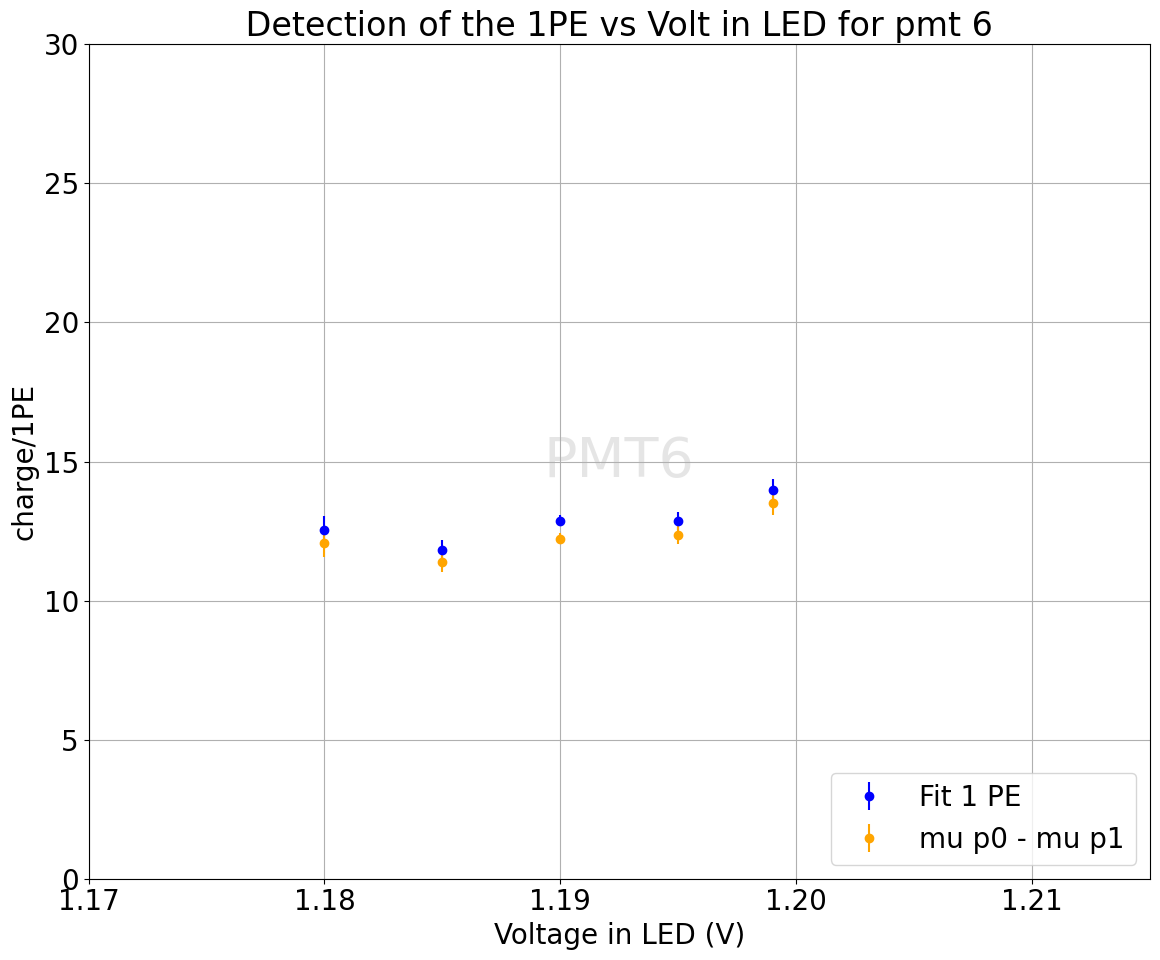

In [160]:
plt.errorbar(LED_plot, mu_p1, yerr=err_mu_p1, fmt="o", color='blue', label="Fit 1 PE") 
mu_p0 = np.array(mu_p0)
mu_p1 = np.array(mu_p1)
err_mu_p0 = np.array(err_mu_p0)
err_mu_p1 = np.array(err_mu_p1)
plt.errorbar(LED_plot, mu_p1 - mu_p0, yerr=np.sqrt(err_mu_p0**2 + err_mu_p1**2), fmt="o", color='orange', label="mu p0 - mu p1") 
print(LED_V)
#plt.xlabel('Voltage in LED (V)')
plt.xlabel('Voltage in LED (V)')
plt.ylabel('charge/1PE')

plt.xlim(LED_V[len(LED_V) - 1] - 0.01, LED_V[1] + 0.01)

plt.ylim(0, 30)
plt.title(f' Detection of the 1PE vs Volt in LED for pmt '+str(pmts[j])+' ')
plt.legend(loc='lower right')
ymax = plt.ylim()[1]
ymin = plt.ylim()[0]
xmax = plt.xlim()[1]
xmin = plt.xlim()[0]
print((ymax-ymin)/2)
plt.text(xmax - (xmax-xmin)/2, ymax - (ymax-ymin)/2, 'PMT'+str(pmts[j]), fontsize=40, color='gray', alpha=0.2, ha='center', va='center', zorder=0)
plt.tight_layout()
plt.grid(True)
plt.savefig(data_path + file_param + 'png', dpi=300, bbox_inches='tight')
print(data_path + file_param + 'png')
plt.show()

In [161]:
#read in the stored parameters for each pmts
#usefull to select the param values for calib directly from files
#watch at the plots and select the voltage you want for each pmts as an input here

#f.write(f"fit P0 : {LED_plot[nb_fit]}\t{amp_p0[nb_fit]:.18e}\t{err_amp_p0[nb_fit]:.18e}\t{mu_p0[nb_fit]:.18e}\t{err_mu_p0[nb_fit]:.18e}\t{sigma_p0[nb_fit]:.18e}\t{err_sigma_p0[nb_fit]:.18e}\n")
#f.write(f"fit p1 : {LED_plot[nb_fit]}\t{amp_p1[nb_fit]:.18e}\t{err_amp_p1[nb_fit]:.18e}\t{mu_p1[nb_fit]:.18e}\t{err_mu_p1[nb_fit]:.18e}\t{sigma_p1[nb_fit]:.18e}\t{err_sigma_p1[nb_fit]:.18e}\n")
#inf = 1400
#sup = 1430
pmts = [0, 1, 2, 3, 4, 5, 6]
#run_nb = [2453, 2454, 2455, 2456, 2457, 2458, 2459]
LED_V_sel = [1.195, 1.195, 1.185, 1.18, 1.185, 1.18, 1.18]
stored_values = []
dst_calib_stored = pd.DataFrame({})
for pmt_sel in range(len(pmts)):

    file_param = "R"+str(np.min(run_nb))+"_R"+str(np.max(run_nb))+"_PMT"+str(pmts[pmt_sel])+"_calib_param_all_fit_1PE."
    dst_calib = pd.read_csv(data_path + file_param + 'txt', delim_whitespace=True, header=None, names=['LED_V', 'amp_p0', 'err_amp_p0', 'mu_p0', 'err_mu_p0', 'sigma_p0', 'err_sigma_p0', 'amp_p1', 'err_amp_p1', 'mu_p1', 'err_mu_p1', 'sigma_p1', 'err_sigma_p1'])
    print(data_path + file_param + 'txt')
    stored_values = dst_calib[(dst_calib['LED_V'] == LED_V_sel[pmt_sel])]
    dst_calib_stored = pd.concat([dst_calib_stored , stored_values], ignore_index=True)
    print(dst_calib_stored)
    
dst_calib_file = pd.DataFrame({})
dst_calib_file = dst_calib_stored[['amp_p0', 'err_amp_p0', 'mu_p0', 'err_mu_p0', 'sigma_p0', 'err_sigma_p0', 'amp_p1', 'err_amp_p1', 'mu_p1', 'err_mu_p1', 'sigma_p1', 'err_sigma_p1']]

print(dst_calib_file)
dst_calib_file.to_csv(data_path + 'calibrun_'+str(np.min(run_nb))+'-'+str(np.max(run_nb))+'_parameters_1PEfit.txt', index=False, header=False, sep="\t")
print(data_path + 'calibrun_'+str(np.min(run_nb))+'-'+str(np.max(run_nb))+'_parameters_1PEfit.txt')
    

/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1073_R1098_PMT0_calib_param_all_fit_1PE.txt
   LED_V      amp_p0  err_amp_p0     mu_p0  err_mu_p0  sigma_p0  err_sigma_p0  \
0  1.195  245.910313   21.166203 -1.055013   0.277957  3.206181      0.226388   

       amp_p1  err_amp_p1     mu_p1  err_mu_p1  sigma_p1  err_sigma_p1  
0  170.194801   61.020175  9.212993   0.579547  5.396752      1.044586  
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1073_R1098_PMT1_calib_param_all_fit_1PE.txt
   LED_V      amp_p0  err_amp_p0     mu_p0  err_mu_p0  sigma_p0  err_sigma_p0  \
0  1.195  245.910313   21.166203 -1.055013   0.277957  3.206181      0.226388   
1  1.195  286.289221   59.332631 -0.517059   0.195403  2.558879      0.222379   

       amp_p1  err_amp_p1     mu_p1  err_mu_p1  sigma_p1  err_sigma_p1  
0  170.194801   61.020175  9.212993   0.579547  5.396752      1.044586  
1  226.913266   93.221166  5.872069   0.952643  4.6

In [455]:
#To store only the fitting parameters that will be used to update the calib values
#It creates the file that is usefull as an input for the updating calib values process (in CreatePlote_and_updateDB_conf.ipynb)

mask_store = (LED_plot == 1.24) #change the value for the one you want to save 

file_param_store = 'calibrun_'+str(np.min(run_nb))+'-'+str(np.max(run_nb))+'_parameters_1PEfit.'
    
with open(data_path + file_param_store + 'txt' , "a", encoding="utf-8") as f:

    f.write(f"{amp_p0[mask_store]:.18e}\t{err_amp_p0[mask_store]:.18e}\t{mu_p0[mask_store]:.18e}\t{err_mu_p0[mask_store]:.18e}\t{sigma_p0[mask_store]:.18e}\t{err_sigma_p0[mask_store]:.18e}\t{amp_p1[mask_store]:.18e}\t{err_amp_p1[mask_store]:.18e}\t{mu_p1[mask_store]:.18e}\t{err_mu_p1[mask_store]:.18e}\t{sigma_p1[mask_store]:.18e}\t{err_sigma_p1[mask_store]:.18e}\n")
    
print(data_path + file_param_store + 'txt') 

/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/calibrun_2436-2443_parameters_1PEfit.txt


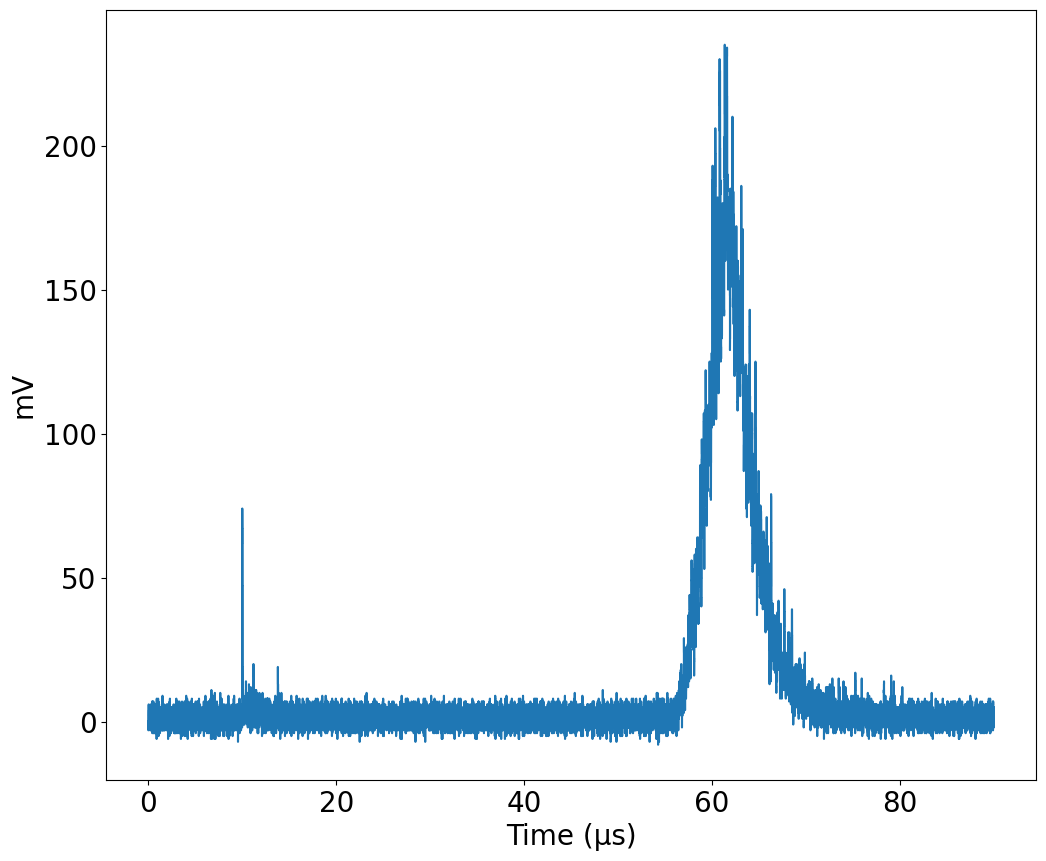

In [25]:


wf_file = '/Users/ldonneger/Desktop/PhD_Thesis2/GapData/R1688/raw/Run_1688_file_0_raw.h5'

with tb.open_file(wf_file, 'r') as h5in:
    wvfs       =  h5in.root.RD.pmtrwf[16] # Gets all pmt waveforms for the second event in the file
    pmt_rwf    = -wvfs.sum(axis=0)       # Sums and inverts the signal of all PMTs
    t = np.linspace(0, len(pmt_rwf)*8/1000, len(pmt_rwf))
    plt.plot(t, pmt_rwf, drawstyle='steps', lw=1.5, zorder=0)
    plt.xlabel('Time (µs)')
    plt.ylabel('mV')

